# EDA - bộ dữ liệu Olist E-commerce Dataset

**Bối cảnh đồ án:** Đồ án kết thúc bằng **Star Schema (BigQuery)** + **Dashboard (Power BI)**.
> Do đó, EDA ở đây không chỉ để "xem dữ liệu trông thế nào", mà phải trả lời được **3 câu hỏi lớn** quyết định kiến trúc downstream:
1. **Grain (độ chi tiết) của từng bảng là gì?**
   → Quyết định bảng nào là **Fact**, bảng nào là **Dimension**.

2. **Dữ liệu bẩn ở đâu, bẩn thế nào?**
   → Quyết định logic làm sạch trong `transform.py` / `validate.py`.

3. **Các chỉ số nghiệp vụ nào có ý nghĩa?**
   → Quyết định **Measure / DAX** trong Power BI.

## Tổng quan bộ dữ liệu

Bộ dữ liệu **Olist** chứa thông tin giao dịch thương mại điện tử tại Brazil, gồm 9 file CSV:
- `olist_customers_dataset.csv`
- `olist_geolocation_dataset.csv`
- `olist_order_items_dataset.csv`
- `olist_order_payments_dataset.csv`
- `olist_order_reviews_dataset.csv`
- `olist_orders_dataset.csv`
- `olist_products_dataset.csv`
- `olist_sellers_dataset.csv`
- `product_category_name_translation.csv`

Dữ liệu ở dạng **OLTP** (nhiều bảng nhỏ, quan hệ qua khóa ngoại). Mục tiêu: remodel thành **Star Schema** để tối ưu analytic.

---

## Kế hoạch EDA

 I. Tổng quan cấu trúc từng bảng và xác định Grain

 II. Kiểm tra và đánh giá kiểu dữ liệu

 III. Kiểm tra Missing Values

 IV. Kiểm tra dữ liệu trùng lặp

 V. Kiểm tra khóa chính, khóa ghép và khóa ngoại

 VI. Kiểm tra giá trị không hợp lệ và quy tắc nghiệp vụ

 VII. Kiểm tra phân phối và giá trị ngoại lệ

 VIII. Kiểm tra quan hệ giữa các bảng

 IX. Tổng hợp các quyết định làm sạch dữ liệu



## I. Tổng quan cấu trúc từng bảng (schema profiling) & Xác định Grain( mức độ chi tiết của bảng)

**Mục đích:**
Trong phần này, mỗi file CSV được đọc thành một DataFrame độc lập để có thể theo dõi, phân tích và xử lý riêng cho từng bảng.

Các nội dung cần kiểm tra gồm:

- `shape`: xác định số dòng và số cột của từng bảng.
- `columns`: xác định các trường dữ liệu đang có.
- `dtypes`: kiểm tra kiểu dữ liệu Pandas đang nhận diện.
- `head()`: quan sát một số dòng dữ liệu thực tế.
- Kiểm tra tính duy nhất của khóa chính hoặc khóa ghép dự kiến.
- Xác định Grain: mỗi dòng trong bảng đại diện cho đối tượng hoặc sự kiện gì.
- Phân loại sơ bộ bảng Fact, Dimension hoặc bảng tham chiếu.

In [5]:
import pandas as pd
import numpy as np

from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


# Notebook đang nằm trong thư mục notebook/
# Dữ liệu raw nằm trong data/raw/
RAW_DATA_DIR = Path("../data/raw")

print("Đường dẫn dữ liệu raw:", RAW_DATA_DIR.resolve())
print("Thư mục tồn tại:", RAW_DATA_DIR.exists())

Đường dẫn dữ liệu raw: D:\doan\olist-ecommerce-etl-dwh\data\raw
Thư mục tồn tại: True


## Đọc dữ liệu

Thay vì gom đường dẫn của 9 file CSV vào một dictionary rồi dùng vòng lặp để đọc hàng loạt, mỗi file được đọc thành một DataFrame có tên riêng.

Cách đặt tên sử dụng hậu tố `_df` để nhận biết đây là một Pandas DataFrame.

## 1.1. Bảng customers

File: `olist_customers_dataset.csv`

Mục tiêu kiểm tra:

- Kích thước bảng.
- Danh sách cột và kiểu dữ liệu.
- Quan sát dữ liệu mẫu.
- Kiểm tra tính duy nhất của `customer_id`.
- So sánh `customer_id` với `customer_unique_id`.
- Xác định Grain và vai trò của bảng trong Data Warehouse.

In [6]:
customers_df = pd.read_csv(
    RAW_DATA_DIR / "olist_customers_dataset.csv"
)

print("CUSTOMERS DATASET")

print("\n1. Kích thước bảng")
print("Số dòng:", customers_df.shape[0])
print("Số cột :", customers_df.shape[1])

print("\n2. Danh sách cột")
print(customers_df.columns.tolist())

print("\n3. Kiểu dữ liệu")
display(customers_df.dtypes.rename("dtype").to_frame())

print("\n4. Ba dòng dữ liệu đầu tiên")
display(customers_df.head(3))

print("\n5. Kiểm tra khóa và Grain")
display(
    pd.Series(
        {
            "Tổng số dòng": len(customers_df),
            "Số customer_id khác nhau":
                customers_df["customer_id"].nunique(),
            "Số customer_unique_id khác nhau":
                customers_df["customer_unique_id"].nunique(),
            "Số customer_id bị trùng":
                customers_df["customer_id"].duplicated().sum(),
            "Số customer_unique_id xuất hiện nhiều lần":
                customers_df["customer_unique_id"].duplicated().sum()
        },
        name="Kết quả"
    ).to_frame()
)

CUSTOMERS DATASET

1. Kích thước bảng
Số dòng: 99441
Số cột : 5

2. Danh sách cột
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

3. Kiểu dữ liệu


,dtype
customer_id,str
customer_unique_id,str
customer_zip_code_prefix,int64
customer_city,str
customer_state,str



4. Ba dòng dữ liệu đầu tiên


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



5. Kiểm tra khóa và Grain


,Kết quả
Tổng số dòng,99441
Số customer_id khác nhau,99441
Số customer_unique_id khác nhau,96096
Số customer_id bị trùng,0
Số customer_unique_id xuất hiện nhiều lần,3345


### Phân tích kết quả bảng customers

Bảng `customers` có 99.441 dòng và 5 cột.

Các cột gồm:

- `customer_id`: mã khách hàng được sử dụng để liên kết với bảng `orders`.
- `customer_unique_id`: mã nhận diện người mua thực tế.
- `customer_zip_code_prefix`: tiền tố mã bưu chính.
- `customer_city`: thành phố của khách hàng.
- `customer_state`: bang của khách hàng.

`customer_id` không nên được hiểu hoàn toàn là mã của một người mua duy nhất trong toàn bộ hệ thống. Trong dữ liệu Olist, một người mua quay lại đặt nhiều đơn có thể được cấp nhiều `customer_id`, nhưng vẫn có cùng `customer_unique_id`.

Vì vậy:

- `customer_id` là khóa liên kết trực tiếp với bảng `orders`.
- `customer_unique_id` phù hợp hơn để phân tích khách hàng thực tế, số khách hàng duy nhất và hành vi mua lại.

**Grain của bảng:** mỗi dòng đại diện cho một bản ghi khách hàng gắn với một `customer_id`.

**Phân loại:** Dimension khách hàng.

Khi xây dựng Dimension khách hàng, cần cân nhắc sử dụng `customer_unique_id` làm khóa nghiệp vụ để tránh coi cùng một người mua nhiều lần là nhiều khách hàng khác nhau.

## 1.2. Bảng geolocation

File: `olist_geolocation_dataset.csv`

Mục tiêu kiểm tra:

- Kích thước bảng.
- Kiểu dữ liệu tọa độ và mã bưu chính.
- Kiểm tra số lượng `geolocation_zip_code_prefix` khác nhau.
- Kiểm tra một mã bưu chính có xuất hiện nhiều dòng hay không.
- Xác định Grain thực tế của bảng.

In [7]:
geolocation_df = pd.read_csv(
    RAW_DATA_DIR / "olist_geolocation_dataset.csv"
)

print("GEOLOCATION DATASET")

print("\n1. Kích thước bảng")
print("Số dòng:", geolocation_df.shape[0])
print("Số cột :", geolocation_df.shape[1])

print("\n2. Danh sách cột")
print(geolocation_df.columns.tolist())

print("\n3. Kiểu dữ liệu")
display(geolocation_df.dtypes.rename("dtype").to_frame())

print("\n4. Ba dòng dữ liệu đầu tiên")
display(geolocation_df.head(3))

print("\n5. Kiểm tra khóa và Grain")
display(
    pd.Series(
        {
            "Tổng số dòng":
                len(geolocation_df),
            "Số zip code prefix khác nhau":
                geolocation_df["geolocation_zip_code_prefix"].nunique(),
            "Số dòng có zip code prefix lặp lại":
                geolocation_df.duplicated(
                    subset=["geolocation_zip_code_prefix"],
                    keep=False
                ).sum(),
            "Số dòng trùng hoàn toàn":
                geolocation_df.duplicated().sum()
        },
        name="Kết quả"
    ).to_frame()
)

print("\n6. Số lượng bản ghi theo một số zip code prefix")
display(
    geolocation_df[
        "geolocation_zip_code_prefix"
    ].value_counts().head(10).rename("Số bản ghi").to_frame()
)

GEOLOCATION DATASET

1. Kích thước bảng
Số dòng: 1000163
Số cột : 5

2. Danh sách cột
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

3. Kiểu dữ liệu


,dtype
geolocation_zip_code_prefix,int64
geolocation_lat,float64
geolocation_lng,float64
geolocation_city,str
geolocation_state,str



4. Ba dòng dữ liệu đầu tiên


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP



5. Kiểm tra khóa và Grain


,Kết quả
Tổng số dòng,1000163
Số zip code prefix khác nhau,19015
Số dòng có zip code prefix lặp lại,999120
Số dòng trùng hoàn toàn,261831



6. Số lượng bản ghi theo một số zip code prefix


,Số bản ghi
geolocation_zip_code_prefix,
24220,1146
24230,1102
38400,965
35500,907
11680,879
22631,832
30140,810
11740,788
38408,773


### Phân tích kết quả bảng geolocation

Bảng `geolocation` có 1.000.163 dòng và 5 cột, là bảng có số dòng lớn nhất trong bộ dữ liệu.

Tuy nhiên, số dòng lớn không đồng nghĩa đây là bảng Fact.

Các cột gồm:

- `geolocation_zip_code_prefix`: tiền tố mã bưu chính.
- `geolocation_lat`: vĩ độ.
- `geolocation_lng`: kinh độ.
- `geolocation_city`: thành phố.
- `geolocation_state`: bang.

Một `geolocation_zip_code_prefix` có thể xuất hiện nhiều dòng với các tọa độ khác nhau. Do đó, Grain của bảng không phải là một dòng cho một zip code duy nhất.

Nguyên nhân có thể do:

- Một khu vực mã bưu chính có nhiều điểm tọa độ.
- Dữ liệu được thu thập từ nhiều địa chỉ thuộc cùng một zip code prefix.
- Một zip code prefix có thể có nhiều cách ghi tên thành phố.
- Có các dòng trùng hoàn toàn cần kiểm tra ở phần dữ liệu trùng lặp.


**Grain hiện tại:** mỗi dòng đại diện cho một quan sát tọa độ địa lý thuộc một `geolocation_zip_code_prefix`.

**Phân loại:** bảng tham chiếu địa lý

Trước khi nối với customers và sellers, bảng này có thể cần được tổng hợp về một dòng cho mỗi zip code prefix, chẳng hạn chọn trung vị hoặc trung bình của latitude và longitude.

## 1.3. Bảng order_items

File: `olist_order_items_dataset.csv`

Mục tiêu kiểm tra:

- Xác định một đơn hàng có thể chứa nhiều sản phẩm.
- Kiểm tra khóa ghép `order_id` và `order_item_id`.
- Kiểm tra các chỉ số giá và phí vận chuyển.
- Xác định Grain của bảng chi tiết đơn hàng.

In [8]:
order_items_df = pd.read_csv(
    RAW_DATA_DIR / "olist_order_items_dataset.csv"
)

print("ORDER ITEMS DATASET")

print("\n1. Kích thước bảng")
print("Số dòng:", order_items_df.shape[0])
print("Số cột :", order_items_df.shape[1])

print("\n2. Danh sách cột")
print(order_items_df.columns.tolist())

print("\n3. Kiểu dữ liệu")
display(order_items_df.dtypes.rename("dtype").to_frame())

print("\n4. Ba dòng dữ liệu đầu tiên")
display(order_items_df.head(3))

print("\n5. Kiểm tra khóa và Grain")
display(
    pd.Series(
        {
            "Tổng số dòng":
                len(order_items_df),
            "Số order_id khác nhau":
                order_items_df["order_id"].nunique(),
            "Số order_id xuất hiện nhiều dòng":
                order_items_df["order_id"].duplicated().sum(),
            "Số product_id khác nhau":
                order_items_df["product_id"].nunique(),
            "Số seller_id khác nhau":
                order_items_df["seller_id"].nunique(),
            "Số khóa ghép order_id + order_item_id bị trùng":
                order_items_df.duplicated(
                    subset=["order_id", "order_item_id"]
                ).sum()
        },
        name="Kết quả"
    ).to_frame()
)

print("\n6. Số sản phẩm trong một số đơn hàng")
display(
    order_items_df.groupby("order_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("Số dòng sản phẩm")
    .to_frame()
)

ORDER ITEMS DATASET

1. Kích thước bảng
Số dòng: 112650
Số cột : 7

2. Danh sách cột
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

3. Kiểu dữ liệu


,dtype
order_id,str
order_item_id,int64
product_id,str
seller_id,str
shipping_limit_date,str
price,float64
freight_value,float64



4. Ba dòng dữ liệu đầu tiên


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



5. Kiểm tra khóa và Grain


,Kết quả
Tổng số dòng,112650
Số order_id khác nhau,98666
Số order_id xuất hiện nhiều dòng,13984
Số product_id khác nhau,32951
Số seller_id khác nhau,3095
Số khóa ghép order_id + order_item_id bị trùng,0



6. Số sản phẩm trong một số đơn hàng


,Số dòng sản phẩm
order_id,
8272b63d03f5f79c56e9e4120aec44ef,21
1b15974a0141d54e36626dca3fdc731a,20
ab14fdcfbe524636d65ee38360e22ce8,20
9ef13efd6949e4573a18964dd1bbe7f5,15
428a2f660dc84138d969ccd69a0ab6d5,15
9bdc4d4c71aa1de4606060929dee888c,14
73c8ab38f07dc94389065f7eba4f297a,14
37ee401157a3a0b28c9c6d0ed8c3b24b,13
af822dacd6f5cff7376413c03a388bb7,12


### Phân tích kết quả bảng order_items

Bảng `order_items` có 112.650 dòng và 7 cột.

Mỗi đơn hàng có thể chứa một hoặc nhiều sản phẩm, vì vậy `order_id` xuất hiện nhiều lần trong bảng là hợp lệ và không phải dữ liệu trùng lỗi.

Các cột gồm:

- `order_id`: mã đơn hàng.
- `order_item_id`: số thứ tự sản phẩm trong đơn hàng.
- `product_id`: mã sản phẩm.
- `seller_id`: mã người bán.
- `shipping_limit_date`: thời hạn người bán phải gửi hàng.
- `price`: giá sản phẩm.
- `freight_value`: phí vận chuyển.

Khóa phù hợp của bảng là khóa ghép:

`order_id + order_item_id`

Trong đó:

- `order_id` xác định đơn hàng.
- `order_item_id` xác định vị trí của sản phẩm trong đơn hàng đó.

Cột `shipping_limit_date` đang được đọc thành chuỗi mặc dù nội dung là ngày giờ. Đây là kiểu dữ liệu cần chuyển thành `datetime` trong bước Transform.

Các cột `price` và `freight_value` là số thực, phù hợp vì đây là các chỉ số tài chính có phần thập phân.

**Grain của bảng:** mỗi dòng đại diện cho một dòng sản phẩm trong một đơn hàng.

**Phân loại:** Fact chi tiết đơn hàng.

Đây là bảng Fact có mức chi tiết cao, phù hợp để tính:

- Số lượng sản phẩm bán ra.
- Doanh thu theo sản phẩm.
- Doanh thu theo người bán.
- Tổng phí vận chuyển.
- Giá trị trung bình của một sản phẩm trong đơn hàng.

## 1.4. Bảng payments

File: `olist_order_payments_dataset.csv`

Mục tiêu kiểm tra:

- Xác định một đơn hàng có thể có nhiều dòng thanh toán.
- Kiểm tra khóa ghép `order_id` và `payment_sequential`.
- Kiểm tra các trường phương thức, số kỳ và giá trị thanh toán.
- Xác định Grain của bảng.

In [9]:
payments_df = pd.read_csv(
    RAW_DATA_DIR / "olist_order_payments_dataset.csv"
)

print("PAYMENTS DATASET")

print("\n1. Kích thước bảng")
print("Số dòng:", payments_df.shape[0])
print("Số cột :", payments_df.shape[1])

print("\n2. Danh sách cột")
print(payments_df.columns.tolist())

print("\n3. Kiểu dữ liệu")
display(payments_df.dtypes.rename("dtype").to_frame())

print("\n4. Ba dòng dữ liệu đầu tiên")
display(payments_df.head(3))

print("\n5. Kiểm tra khóa và Grain")
display(
    pd.Series(
        {
            "Tổng số dòng":
                len(payments_df),
            "Số order_id khác nhau":
                payments_df["order_id"].nunique(),
            "Số order_id xuất hiện nhiều dòng":
                payments_df["order_id"].duplicated().sum(),
            "Số phương thức thanh toán":
                payments_df["payment_type"].nunique(),
            "Số khóa ghép order_id + payment_sequential bị trùng":
                payments_df.duplicated(
                    subset=["order_id", "payment_sequential"]
                ).sum()
        },
        name="Kết quả"
    ).to_frame()
)

print("\n6. Một số đơn hàng có nhiều dòng thanh toán")
display(
    payments_df.groupby("order_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("Số dòng thanh toán")
    .to_frame()
)

PAYMENTS DATASET

1. Kích thước bảng
Số dòng: 103886
Số cột : 5

2. Danh sách cột
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

3. Kiểu dữ liệu


,dtype
order_id,str
payment_sequential,int64
payment_type,str
payment_installments,int64
payment_value,float64



4. Ba dòng dữ liệu đầu tiên


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71



5. Kiểm tra khóa và Grain


,Kết quả
Tổng số dòng,103886
Số order_id khác nhau,99440
Số order_id xuất hiện nhiều dòng,4446
Số phương thức thanh toán,5
Số khóa ghép order_id + payment_sequential bị trùng,0



6. Một số đơn hàng có nhiều dòng thanh toán


,Số dòng thanh toán
order_id,
fa65dad1b0e818e3ccc5cb0e39231352,29
ccf804e764ed5650cd8759557269dc13,26
285c2e15bebd4ac83635ccc563dc71f4,22
895ab968e7bb0d5659d16cd74cd1650c,21
fedcd9f7ccdc8cba3a18defedd1a5547,19
ee9ca989fc93ba09a6eddc250ce01742,19
4bfcba9e084f46c8e3cb49b0fa6e6159,15
21577126c19bf11a0b91592e5844ba78,15
4689b1816de42507a7d63a4617383c59,14


### Phân tích kết quả bảng payments

Bảng `payments` có 103.886 dòng, nhiều hơn số dòng của bảng orders là 99.441.

Điều này cho thấy một đơn hàng có thể có nhiều dòng thanh toán.

Một số nguyên nhân có thể gồm:

- Khách hàng sử dụng nhiều phương thức thanh toán cho cùng một đơn.
- Thanh toán được ghi nhận thành nhiều phần.
- Hệ thống sử dụng `payment_sequential` để đánh số thứ tự các lần thanh toán trong cùng một đơn.

Các cột gồm:

- `order_id`: mã đơn hàng.
- `payment_sequential`: thứ tự dòng thanh toán.
- `payment_type`: phương thức thanh toán.
- `payment_installments`: số kỳ trả góp.
- `payment_value`: giá trị thanh toán.

Khóa phù hợp của bảng là:

`order_id + payment_sequential`

`order_id` bị lặp trong bảng là hợp lệ vì một đơn có thể có nhiều dòng thanh toán.

Các kiểu dữ liệu hiện tại nhìn chung phù hợp:

- `payment_sequential`: số nguyên.
- `payment_installments`: số nguyên.
- `payment_value`: số thực.
- `payment_type`: chuỗi phân loại.

**Grain của bảng:** mỗi dòng đại diện cho một phần hoặc một lần thanh toán của một đơn hàng.

**Phân loại:** Fact thanh toán.

Khi phân tích doanh thu theo mức đơn hàng, cần tổng hợp `payment_value` theo `order_id` trước khi nối với bảng orders. Nếu nối trực tiếp mà không kiểm soát Grain, một đơn hàng có nhiều dòng thanh toán có thể làm nhân bản dữ liệu.

## 1.5. Bảng reviews

File: `olist_order_reviews_dataset.csv`

Mục tiêu kiểm tra:

- Kiểm tra tính duy nhất của `review_id`.
- Kiểm tra `order_id` có xuất hiện nhiều lần hay không.
- Kiểm tra kiểu dữ liệu điểm đánh giá và các mốc thời gian.
- Xác định Grain của bảng đánh giá.

In [10]:
reviews_df = pd.read_csv(
    RAW_DATA_DIR / "olist_order_reviews_dataset.csv"
)

print("REVIEWS DATASET")

print("\n1. Kích thước bảng")
print("Số dòng:", reviews_df.shape[0])
print("Số cột :", reviews_df.shape[1])

print("\n2. Danh sách cột")
print(reviews_df.columns.tolist())

print("\n3. Kiểu dữ liệu")
display(reviews_df.dtypes.rename("dtype").to_frame())

print("\n4. Ba dòng dữ liệu đầu tiên")
display(reviews_df.head(3))

print("\n5. Kiểm tra khóa và Grain")
display(
    pd.Series(
        {
            "Tổng số dòng":
                len(reviews_df),
            "Số review_id khác nhau":
                reviews_df["review_id"].nunique(),
            "Số review_id bị trùng":
                reviews_df["review_id"].duplicated().sum(),
            "Số order_id khác nhau":
                reviews_df["order_id"].nunique(),
            "Số order_id xuất hiện nhiều dòng":
                reviews_df["order_id"].duplicated().sum(),
            "Số mức review_score":
                reviews_df["review_score"].nunique()
        },
        name="Kết quả"
    ).to_frame()
)

REVIEWS DATASET

1. Kích thước bảng
Số dòng: 99224
Số cột : 7

2. Danh sách cột
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

3. Kiểu dữ liệu


,dtype
review_id,str
order_id,str
review_score,int64
review_comment_title,str
review_comment_message,str
review_creation_date,str
review_answer_timestamp,str



4. Ba dòng dữ liệu đầu tiên


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24



5. Kiểm tra khóa và Grain


,Kết quả
Tổng số dòng,99224
Số review_id khác nhau,98410
Số review_id bị trùng,814
Số order_id khác nhau,98673
Số order_id xuất hiện nhiều dòng,551
Số mức review_score,5


### Phân tích kết quả bảng reviews

Bảng `reviews` có 99.224 dòng và 7 cột.

Các cột gồm:

- `review_id`: mã đánh giá.
- `order_id`: mã đơn hàng được đánh giá.
- `review_score`: điểm đánh giá.
- `review_comment_title`: tiêu đề nhận xét.
- `review_comment_message`: nội dung nhận xét.
- `review_creation_date`: thời điểm tạo yêu cầu đánh giá.
- `review_answer_timestamp`: thời điểm khách hàng gửi đánh giá.

`review_id` là khóa định danh phù hợp cho từng đánh giá.

Cần kiểm tra xem order_id có bị lặp trong bảng reviews hay không. Nếu một order_id xuất hiện nhiều lần thì đơn hàng đó có nhiều bản ghi đánh giá.

Cột `review_score` được đọc thành số nguyên, phù hợp vì điểm đánh giá là thang điểm rời rạc.

Hai cột thời gian:

- `review_creation_date`
- `review_answer_timestamp`

đang được đọc thành chuỗi và cần chuyển thành `datetime` trong bước Transform.

Các cột tiêu đề và nội dung nhận xét có thể chứa giá trị thiếu. Tuy nhiên, việc khách hàng chỉ chấm điểm mà không viết bình luận có thể là hành vi hợp lệ. Vì vậy, không nên xóa hoặc điền dữ liệu trước khi phân tích missing value.

**Grain của bảng:** mỗi dòng đại diện cho một bản ghi đánh giá có `review_id`.

**Phân loại:** Fact đánh giá

Bảng có thể dùng để phân tích:

- Điểm đánh giá trung bình.
- Tỷ lệ đánh giá tốt và xấu.
- Mức độ hài lòng theo sản phẩm, người bán hoặc thời gian.
- Thời gian phản hồi đánh giá.

## 1.6. Bảng orders

File: `olist_orders_dataset.csv`

Mục tiêu kiểm tra:

- Kiểm tra tính duy nhất của `order_id`.
- Kiểm tra quan hệ giữa orders và customers.
- Quan sát trạng thái và các mốc thời gian của đơn hàng.
- Xác định Grain của bảng.

In [11]:
orders_df = pd.read_csv(
    RAW_DATA_DIR / "olist_orders_dataset.csv"
)

print("ORDERS DATASET")

print("\n1. Kích thước bảng")
print("Số dòng:", orders_df.shape[0])
print("Số cột :", orders_df.shape[1])

print("\n2. Danh sách cột")
print(orders_df.columns.tolist())

print("\n3. Kiểu dữ liệu")
display(orders_df.dtypes.rename("dtype").to_frame())

print("\n4. Ba dòng dữ liệu đầu tiên")
display(orders_df.head(3))

print("\n5. Kiểm tra khóa và Grain")
display(
    pd.Series(
        {
            "Tổng số dòng":
                len(orders_df),
            "Số order_id khác nhau":
                orders_df["order_id"].nunique(),
            "Số order_id bị trùng":
                orders_df["order_id"].duplicated().sum(),
            "Số customer_id khác nhau":
                orders_df["customer_id"].nunique(),
            "Số customer_id xuất hiện nhiều dòng":
                orders_df["customer_id"].duplicated().sum(),
            "Số trạng thái đơn hàng":
                orders_df["order_status"].nunique()
        },
        name="Kết quả"
    ).to_frame()
)

print("\n6. Phân bố trạng thái đơn hàng")
display(
    orders_df["order_status"]
    .value_counts(dropna=False)
    .rename("Số đơn hàng")
    .to_frame()
)

ORDERS DATASET

1. Kích thước bảng
Số dòng: 99441
Số cột : 8

2. Danh sách cột
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

3. Kiểu dữ liệu


,dtype
order_id,str
customer_id,str
order_status,str
order_purchase_timestamp,str
order_approved_at,str
order_delivered_carrier_date,str
order_delivered_customer_date,str
order_estimated_delivery_date,str



4. Ba dòng dữ liệu đầu tiên


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



5. Kiểm tra khóa và Grain


,Kết quả
Tổng số dòng,99441
Số order_id khác nhau,99441
Số order_id bị trùng,0
Số customer_id khác nhau,99441
Số customer_id xuất hiện nhiều dòng,0
Số trạng thái đơn hàng,8



6. Phân bố trạng thái đơn hàng


,Số đơn hàng
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


### Phân tích kết quả bảng orders

Bảng `orders` có 99.441 dòng và 8 cột.

Các cột gồm:

- `order_id`: mã đơn hàng.
- `customer_id`: mã khách hàng liên kết với bảng customers.
- `order_status`: trạng thái đơn hàng.
- `order_purchase_timestamp`: thời điểm đặt hàng.
- `order_approved_at`: thời điểm đơn được duyệt.
- `order_delivered_carrier_date`: thời điểm giao cho đơn vị vận chuyển.
- `order_delivered_customer_date`: thời điểm giao đến khách hàng.
- `order_estimated_delivery_date`: ngày giao hàng dự kiến.

`order_id` là khóa chính dự kiến của bảng. Nếu số `order_id` khác nhau bằng tổng số dòng và không có giá trị trùng, mỗi dòng tương ứng với đúng một đơn hàng.

Các cột thời gian hiện đang được đọc thành chuỗi. Đây là kiểu dữ liệu chưa phù hợp với mục đích tính toán thời gian.

Các trường cần chuyển sang `datetime` trong bước Transform gồm:

- `order_purchase_timestamp`
- `order_approved_at`
- `order_delivered_carrier_date`
- `order_delivered_customer_date`
- `order_estimated_delivery_date`

Các giá trị thiếu trong những cột thời gian không thể được xử lý chung. Ý nghĩa missing phụ thuộc vào `order_status`.

Ví dụ:

- Đơn bị hủy có thể không có ngày giao khách hàng.
- Đơn chưa được duyệt có thể thiếu `order_approved_at`.
- Đơn chưa giao có thể thiếu ngày giao cho đơn vị vận chuyển.

**Grain của bảng:** mỗi dòng đại diện cho một đơn hàng.

**Phân loại:** Fact đơn hàng

Bảng orders là bảng trung tâm để liên kết khách hàng, sản phẩm, thanh toán, đánh giá và các mốc thời gian vận hành.

## 1.7. Bảng products

File: `olist_products_dataset.csv`

Mục tiêu kiểm tra:

- Kiểm tra tính duy nhất của `product_id`.
- Quan sát các thuộc tính mô tả sản phẩm.
- Phát hiện các cột số nguyên đang được đọc thành số thực.
- Xác định Grain của bảng.

In [12]:
products_df = pd.read_csv(
    RAW_DATA_DIR / "olist_products_dataset.csv"
)

print("PRODUCTS DATASET")

print("\n1. Kích thước bảng")
print("Số dòng:", products_df.shape[0])
print("Số cột :", products_df.shape[1])

print("\n2. Danh sách cột")
print(products_df.columns.tolist())

print("\n3. Kiểu dữ liệu")
display(products_df.dtypes.rename("dtype").to_frame())

print("\n4. Ba dòng dữ liệu đầu tiên")
display(products_df.head(3))

print("\n5. Kiểm tra khóa và Grain")
display(
    pd.Series(
        {
            "Tổng số dòng":
                len(products_df),
            "Số product_id khác nhau":
                products_df["product_id"].nunique(),
            "Số product_id bị trùng":
                products_df["product_id"].duplicated().sum(),
            "Số danh mục sản phẩm khác nhau":
                products_df["product_category_name"].nunique(
                    dropna=True
                )
        },
        name="Kết quả"
    ).to_frame()
)

PRODUCTS DATASET

1. Kích thước bảng
Số dòng: 32951
Số cột : 9

2. Danh sách cột
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

3. Kiểu dữ liệu


,dtype
product_id,str
product_category_name,str
product_name_lenght,float64
product_description_lenght,float64
product_photos_qty,float64
product_weight_g,float64
product_length_cm,float64
product_height_cm,float64
product_width_cm,float64



4. Ba dòng dữ liệu đầu tiên


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



5. Kiểm tra khóa và Grain


,Kết quả
Tổng số dòng,32951
Số product_id khác nhau,32951
Số product_id bị trùng,0
Số danh mục sản phẩm khác nhau,73


### Phân tích kết quả bảng products

Bảng `products` có 32.951 dòng và 9 cột.

Các cột gồm:

- `product_id`: mã sản phẩm.
- `product_category_name`: tên danh mục bằng tiếng Bồ Đào Nha.
- `product_name_lenght`: độ dài tên sản phẩm.
- `product_description_lenght`: độ dài phần mô tả.
- `product_photos_qty`: số lượng ảnh sản phẩm.
- `product_weight_g`: khối lượng sản phẩm tính bằng gram.
- `product_length_cm`: chiều dài sản phẩm.
- `product_height_cm`: chiều cao sản phẩm.
- `product_width_cm`: chiều rộng sản phẩm.

`product_id` là khóa chính dự kiến của bảng.

Các cột:

- `product_name_lenght`
- `product_description_lenght`
- `product_photos_qty`

về mặt ý nghĩa là số đếm nên phù hợp với kiểu số nguyên. Tuy nhiên, Pandas có thể đọc thành `float64` vì các cột này chứa missing value và kiểu `int64` thông thường không lưu được `NaN`.



Các cột trọng lượng và kích thước là dữ liệu đo lường. Chúng có thể giữ ở kiểu số thực để hỗ trợ tính toán và chứa giá trị thiếu.



**Grain của bảng:** mỗi dòng đại diện cho một sản phẩm có `product_id`.

**Phân loại:** Dimension sản phẩm.

Bảng này cung cấp thuộc tính mô tả để phân tích doanh thu, số lượng bán và đánh giá theo danh mục, kích thước hoặc đặc điểm sản phẩm.

## 1.8. Bảng sellers

File: `olist_sellers_dataset.csv`

Mục tiêu kiểm tra:

- Kiểm tra tính duy nhất của `seller_id`.
- Quan sát thông tin vị trí người bán.
- Kiểm tra kiểu dữ liệu mã bưu chính.
- Xác định Grain của bảng.

In [13]:
sellers_df = pd.read_csv(
    RAW_DATA_DIR / "olist_sellers_dataset.csv"
)

print("SELLERS DATASET")

print("\n1. Kích thước bảng")
print("Số dòng:", sellers_df.shape[0])
print("Số cột :", sellers_df.shape[1])

print("\n2. Danh sách cột")
print(sellers_df.columns.tolist())

print("\n3. Kiểu dữ liệu")
display(sellers_df.dtypes.rename("dtype").to_frame())

print("\n4. Ba dòng dữ liệu đầu tiên")
display(sellers_df.head(3))

print("\n5. Kiểm tra khóa và Grain")
display(
    pd.Series(
        {
            "Tổng số dòng":
                len(sellers_df),
            "Số seller_id khác nhau":
                sellers_df["seller_id"].nunique(),
            "Số seller_id bị trùng":
                sellers_df["seller_id"].duplicated().sum(),
            "Số seller_zip_code_prefix khác nhau":
                sellers_df["seller_zip_code_prefix"].nunique(),
            "Số thành phố người bán":
                sellers_df["seller_city"].nunique(),
            "Số bang người bán":
                sellers_df["seller_state"].nunique()
        },
        name="Kết quả"
    ).to_frame()
)

SELLERS DATASET

1. Kích thước bảng
Số dòng: 3095
Số cột : 4

2. Danh sách cột
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

3. Kiểu dữ liệu


,dtype
seller_id,str
seller_zip_code_prefix,int64
seller_city,str
seller_state,str



4. Ba dòng dữ liệu đầu tiên


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



5. Kiểm tra khóa và Grain


,Kết quả
Tổng số dòng,3095
Số seller_id khác nhau,3095
Số seller_id bị trùng,0
Số seller_zip_code_prefix khác nhau,2246
Số thành phố người bán,611
Số bang người bán,23


### Phân tích kết quả bảng sellers

Bảng `sellers` có 3.095 dòng và 4 cột.

Các cột gồm:

- `seller_id`: mã người bán.
- `seller_zip_code_prefix`: tiền tố mã bưu chính của người bán.
- `seller_city`: thành phố.
- `seller_state`: bang.

`seller_id` là khóa chính dự kiến của bảng.


Sau khi chuẩn hóa kiểu dữ liệu, `seller_zip_code_prefix` có thể được nối với bảng geolocation để bổ sung vĩ độ  và kinh độ cho người bán.

**Grain của bảng:** mỗi dòng đại diện cho một người bán có `seller_id`.

**Phân loại:** Dimension người bán.

Bảng này có thể dùng để phân tích:

- Doanh thu theo người bán.
- Số đơn hàng theo người bán.
- Hiệu suất vận chuyển theo khu vực.
- Phân bố người bán theo thành phố và bang.

## 1.9. Bảng category_translation

File: `product_category_name_translation.csv`

Mục tiêu kiểm tra:

- Kiểm tra tính duy nhất của tên danh mục tiếng Bồ Đào Nha.
- Kiểm tra quan hệ ánh xạ giữa tên gốc và tên tiếng Anh.
- Xác định Grain và vai trò của bảng.

In [14]:
category_translation_df = pd.read_csv(
    RAW_DATA_DIR / "product_category_name_translation.csv"
)

print("CATEGORY TRANSLATION DATASET")

print("\n1. Kích thước bảng")
print("Số dòng:", category_translation_df.shape[0])
print("Số cột :", category_translation_df.shape[1])

print("\n2. Danh sách cột")
print(category_translation_df.columns.tolist())

print("\n3. Kiểu dữ liệu")
display(
    category_translation_df.dtypes
    .rename("dtype")
    .to_frame()
)

print("\n4. Ba dòng dữ liệu đầu tiên")
display(category_translation_df.head(3))

print("\n5. Kiểm tra khóa và Grain")
display(
    pd.Series(
        {
            "Tổng số dòng":
                len(category_translation_df),
            "Số tên danh mục gốc khác nhau":
                category_translation_df[
                    "product_category_name"
                ].nunique(),
            "Số tên danh mục gốc bị trùng":
                category_translation_df[
                    "product_category_name"
                ].duplicated().sum(),
            "Số tên danh mục tiếng Anh khác nhau":
                category_translation_df[
                    "product_category_name_english"
                ].nunique()
        },
        name="Kết quả"
    ).to_frame()
)

CATEGORY TRANSLATION DATASET

1. Kích thước bảng
Số dòng: 71
Số cột : 2

2. Danh sách cột
['product_category_name', 'product_category_name_english']

3. Kiểu dữ liệu


,dtype
product_category_name,str
product_category_name_english,str



4. Ba dòng dữ liệu đầu tiên


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto



5. Kiểm tra khóa và Grain


,Kết quả
Tổng số dòng,71
Số tên danh mục gốc khác nhau,71
Số tên danh mục gốc bị trùng,0
Số tên danh mục tiếng Anh khác nhau,71


### Phân tích kết quả bảng category_translation

Bảng `category_translation` có 71 dòng và 2 cột.

Các cột gồm:

- `product_category_name`: tên danh mục bằng tiếng Bồ Đào Nha.
- `product_category_name_english`: tên danh mục bằng tiếng Anh.

Đây là bảng ánh xạ tên danh mục, không chứa giao dịch, doanh thu hoặc sự kiện nghiệp vụ.

`product_category_name` là khóa liên kết với cột cùng tên trong bảng products.

Nếu mỗi tên danh mục gốc chỉ xuất hiện một lần, bảng có quan hệ ánh xạ một-một từ tên tiếng Bồ Đào Nha sang tên tiếng Anh.

**Grain của bảng:** mỗi dòng đại diện cho một ánh xạ của một danh mục sản phẩm sang tên tiếng Anh.

**Phân loại:** bảng tham chiếu hoặc bảng tra cứu danh mục.

Bảng này được dùng để ánh xạ tên danh mục sản phẩm từ tiếng Bồ Đào Nha sang tiếng Anh, giúp tên danh mục dễ hiểu hơn khi phân tích và trực quan hóa dữ liệu trên Power BI.

## 1.10. Kiểm tra quan hệ tổng quan giữa các bảng

Sau khi xác định Grain riêng của từng bảng, cần so sánh số dòng và số khóa duy nhất để hiểu quan hệ giữa các bảng.

Phần này chưa thực hiện join dữ liệu. Mục tiêu chỉ là kiểm tra sơ bộ quan hệ một-một hoặc một-nhiều.

In [15]:
print("KIỂM TRA QUAN HỆ TỔNG QUAN")

print("\n1. Orders và Customers")

print("Số dòng orders:")
print(len(orders_df))

print("Số order_id khác nhau:")
print(orders_df["order_id"].nunique())

print("Số customer_id khác nhau trong orders:")
print(orders_df["customer_id"].nunique())

print("Số customer_id khác nhau trong customers:")
print(customers_df["customer_id"].nunique())

print(
    "Số customer_unique_id khác nhau trong customers:"
)
print(customers_df["customer_unique_id"].nunique())


print("\n2. Orders và Order Items")

print("Số order_id trong orders:")
print(orders_df["order_id"].nunique())

print("Số order_id trong order_items:")
print(order_items_df["order_id"].nunique())

print("Số dòng order_items:")
print(len(order_items_df))


print("\n3. Orders và Payments")

print("Số order_id trong orders:")
print(orders_df["order_id"].nunique())

print("Số order_id trong payments:")
print(payments_df["order_id"].nunique())

print("Số dòng payments:")
print(len(payments_df))


print("\n4. Orders và Reviews")

print("Số order_id trong orders:")
print(orders_df["order_id"].nunique())

print("Số order_id trong reviews:")
print(reviews_df["order_id"].nunique())

print("Số dòng reviews:")
print(len(reviews_df))


print("\n5. Products và Category Translation")

print("Số category trong products:")
print(
    products_df["product_category_name"].nunique(
        dropna=True
    )
)

print("Số category trong bảng dịch:")
print(
    category_translation_df[
        "product_category_name"
    ].nunique()
)

KIỂM TRA QUAN HỆ TỔNG QUAN

1. Orders và Customers
Số dòng orders:
99441
Số order_id khác nhau:
99441
Số customer_id khác nhau trong orders:
99441
Số customer_id khác nhau trong customers:
99441
Số customer_unique_id khác nhau trong customers:
96096

2. Orders và Order Items
Số order_id trong orders:
99441
Số order_id trong order_items:
98666
Số dòng order_items:
112650

3. Orders và Payments
Số order_id trong orders:
99441
Số order_id trong payments:
99440
Số dòng payments:
103886

4. Orders và Reviews
Số order_id trong orders:
99441
Số order_id trong reviews:
98673
Số dòng reviews:
99224

5. Products và Category Translation
Số category trong products:
73
Số category trong bảng dịch:
71


### Phân tích quan hệ tổng quan

#### Orders và Customers

Bảng orders và customers đều có 99.441 dòng. Tuy nhiên, điều này không có nghĩa mỗi dòng customers là một người mua thực tế duy nhất.

`customer_id` được dùng để nối orders với customers, trong khi `customer_unique_id` mới phản ánh khách hàng thực tế có thể quay lại mua nhiều lần.

Quan hệ nối trực tiếp:

`orders.customer_id → customers.customer_id`

#### Orders và Order Items

Số dòng order_items lớn hơn orders vì một đơn hàng có thể chứa nhiều sản phẩm.

Quan hệ:

`orders.order_id → order_items.order_id`

Đây là quan hệ một-nhiều.

#### Orders và Payments

Số dòng payments lớn hơn số đơn hàng vì một đơn có thể có nhiều dòng thanh toán.

Quan hệ:

`orders.order_id → payments.order_id`

Đây là quan hệ một-nhiều.

#### Orders và Reviews

Số dòng reviews gần bằng nhưng không hoàn toàn bằng số dòng orders.

Điều này có thể do:

- Có đơn hàng không được đánh giá.
- Có đơn hàng xuất hiện nhiều bản ghi đánh giá.
- Có sự khác biệt về thời điểm ghi nhận dữ liệu.

Không nên giả định quan hệ một-một trước khi kiểm tra `order_id`.

#### Products và Category Translation

Bảng category_translation được dùng để bổ sung tên danh mục tiếng Anh cho bảng products.

Quan hệ:

`products.product_category_name → category_translation.product_category_name`

Đây là quan hệ nhiều-một: nhiều sản phẩm có thể thuộc cùng một danh mục.

## Kết luận phần I: Schema Profiling và Grain

| Bảng | Shape | Grain | Khóa dự kiến | Vai trò |
|---|---:|---|---|---|
| customers | 99.441 × 5 | Một bản ghi khách hàng theo `customer_id` | `customer_id` | Dimension khách hàng |
| geolocation | 1.000.163 × 5 | Một quan sát tọa độ thuộc một zip code prefix | Chưa có khóa duy nhất rõ ràng | Bảng tham chiếu địa lý |
| order_items | 112.650 × 7 | Một dòng sản phẩm trong một đơn hàng | `order_id + order_item_id` | Fact chi tiết đơn hàng |
| payments | 103.886 × 5 | Một phần hoặc một lần thanh toán của đơn hàng | `order_id + payment_sequential` | Fact thanh toán |
| reviews | 99.224 × 7 | Một bản ghi đánh giá | `review_id` | Fact đánh giá |
| orders | 99.441 × 8 | Một đơn hàng | `order_id` | Fact đơn hàng |
| products | 32.951 × 9 | Một sản phẩm | `product_id` | Dimension sản phẩm |
| sellers | 3.095 × 4 | Một người bán | `seller_id` | Dimension người bán |
| category_translation | 71 × 2 | Một ánh xạ tên danh mục | `product_category_name` | Bảng tham chiếu |

### Các vấn đề kiểu dữ liệu đã phát hiện

Các cột mã bưu chính đang được đọc thành số nguyên nhưng về bản chất là mã định danh:

- `customer_zip_code_prefix`
- `geolocation_zip_code_prefix`
- `seller_zip_code_prefix`

Các cột ngày giờ đang được đọc thành chuỗi:

- `shipping_limit_date`
- `review_creation_date`
- `review_answer_timestamp`
- `order_purchase_timestamp`
- `order_approved_at`
- `order_delivered_carrier_date`
- `order_delivered_customer_date`
- `order_estimated_delivery_date`

Một số cột số đếm trong products đang được đọc thành số thực do có missing value:

- `product_name_lenght`
- `product_description_lenght`
- `product_photos_qty`

Các vấn đề trên mới chỉ được ghi nhận trong phần Schema Profiling. Việc quyết định ép kiểu sẽ được thực hiện sau khi kiểm tra missing value, giá trị không hợp lệ và phạm vi dữ liệu của từng cột.

### Kết luận về cách tổ chức DataFrame

Mỗi CSV hiện được quản lý bằng một DataFrame riêng:

- `customers_df`
- `geolocation_df`
- `order_items_df`
- `payments_df`
- `reviews_df`
- `orders_df`
- `products_df`
- `sellers_df`
- `category_translation_df`

Cách tổ chức này giúp các phần EDA và Transform phía sau có thể viết riêng cho từng bảng, thể hiện rõ:

- Bảng đang gặp vấn đề gì.
- Cột nào cần xử lý.
- Tại sao cần xử lý.
- Quy tắc xử lý nào được áp dụng.
- Kết quả trước và sau khi xử lý.

# II. Kiểm tra và đánh giá kiểu dữ liệu của từng bảng

## Mục đích

Sau khi xác định cấu trúc và Grain của từng bảng, phần này kiểm tra kiểu dữ liệu của từng cột để xác định:

- Kiểu dữ liệu hiện tại do Pandas nhận diện.
- Kiểu dữ liệu hiện tại có phù hợp với ý nghĩa nghiệp vụ hay không.
- Cột nào đang được đọc sai kiểu.
- Dữ liệu có thể chuyển sang kiểu mong muốn hay không.
- Có giá trị nào gây lỗi khi ép kiểu không.
- Kiểu dữ liệu đích sẽ được sử dụng trong bước Transform.

Trong phần này chỉ thực hiện chuyển đổi thử nghiệm trên các biến tạm để đánh giá khả năng ép kiểu.

Dữ liệu gốc trong các DataFrame chưa bị thay đổi.

## 2.1. Kiểm tra kiểu dữ liệu bảng customers

Bảng `customers` chứa mã khách hàng và thông tin vị trí của khách hàng.

Các vấn đề cần kiểm tra:

- Các cột ID có đang ở kiểu chuỗi hay không.
- `customer_zip_code_prefix` có phù hợp với kiểu số nguyên hay không.
- Mã bưu chính có bị thiếu số 0 ở đầu hay không.
- Các cột thành phố và bang có đang ở kiểu chuỗi hay không.

In [16]:
print("KIỂM TRA KIỂU DỮ LIỆU: CUSTOMERS")

customers_dtype_report = pd.DataFrame({
    "column": customers_df.columns,
    "current_dtype": customers_df.dtypes.astype(str).values,
    "non_null_count": customers_df.notna().sum().values,
    "missing_count": customers_df.isna().sum().values,
    "unique_count": customers_df.nunique(dropna=True).values
})

display(customers_dtype_report)

KIỂM TRA KIỂU DỮ LIỆU: CUSTOMERS


,column,current_dtype,non_null_count,missing_count,unique_count
0,customer_id,str,99441,0,99441
1,customer_unique_id,str,99441,0,96096
2,customer_zip_code_prefix,int64,99441,0,14994
3,customer_city,str,99441,0,4119
4,customer_state,str,99441,0,27


In [17]:
#Kiểm tra mã bưu chính
customer_zip_temp = (
    customers_df["customer_zip_code_prefix"]
    .astype("string")
)

customer_zip_length = customer_zip_temp.str.len()

print("KIỂM TRA customer_zip_code_prefix")

print(
    "Kiểu dữ liệu hiện tại:",
    customers_df["customer_zip_code_prefix"].dtype
)

print(
    "Độ dài nhỏ nhất khi chuyển thử sang chuỗi:",
    customer_zip_length.min()
)

print(
    "Độ dài lớn nhất khi chuyển thử sang chuỗi:",
    customer_zip_length.max()
)

print(
    "Số mã có ít hơn 5 ký tự:",
    (customer_zip_length < 5).sum()
)

print(
    "Số mã có nhiều hơn 5 ký tự:",
    (customer_zip_length > 5).sum()
)

print("\nMột số giá trị trước khi chuẩn hóa:")
display(
    customers_df[
        ["customer_zip_code_prefix"]
    ].head(10)
)

print("\nMột số giá trị sau khi chuyển thử sang chuỗi và thêm số 0:")
display(
    customer_zip_temp
    .str.zfill(5)
    .head(10)
    .rename("customer_zip_code_prefix_string")
    .to_frame()
)

KIỂM TRA customer_zip_code_prefix
Kiểu dữ liệu hiện tại: int64
Độ dài nhỏ nhất khi chuyển thử sang chuỗi: 4
Độ dài lớn nhất khi chuyển thử sang chuỗi: 5
Số mã có ít hơn 5 ký tự: 23995
Số mã có nhiều hơn 5 ký tự: 0

Một số giá trị trước khi chuẩn hóa:


,customer_zip_code_prefix
0,14409
1,9790
2,1151
3,8775
4,13056
5,89254
6,4534
7,35182
8,81560
9,30575



Một số giá trị sau khi chuyển thử sang chuỗi và thêm số 0:


,customer_zip_code_prefix_string
0,14409
1,09790
2,01151
3,08775
4,13056
5,89254
6,04534
7,35182
8,81560
9,30575


### Phân tích kết quả bảng customers

Các cột `customer_id` và `customer_unique_id` đang được đọc dưới dạng chuỗi. Đây là kiểu dữ liệu phù hợp vì hai cột này là mã định danh, không phải đại lượng dùng để tính toán.

Các cột `customer_city` và `customer_state` cũng phù hợp với kiểu chuỗi vì chúng chứa thông tin phân loại địa lý.

Cột `customer_zip_code_prefix` hiện đang được đọc thành `int64`. Kiểu dữ liệu này chưa phù hợp với ý nghĩa nghiệp vụ vì mã bưu chính là mã định danh địa lý, không phải số dùng để cộng, trừ hoặc tính trung bình.

Khi mã bưu chính được lưu dưới dạng số nguyên, các số 0 ở đầu có thể không được giữ lại. Vì vậy, trong bước Transform cần:

1. Chuyển `customer_zip_code_prefix` sang kiểu chuỗi.
2. Chuẩn hóa mã thành 5 ký tự bằng `str.zfill(5)`.

### Quyết định kiểu dữ liệu

| Cột | Kiểu hiện tại | Kiểu đề xuất | Quyết định |
|---|---|---|---|
| `customer_id` | string | string | Giữ nguyên |
| `customer_unique_id` | string | string | Giữ nguyên |
| `customer_zip_code_prefix` | int64 | string | Cần chuyển kiểu và thêm số 0 ở đầu |
| `customer_city` | string | string | Giữ nguyên |
| `customer_state` | string | string | Giữ nguyên |

## 2.2. Kiểm tra kiểu dữ liệu bảng geolocation

Bảng `geolocation` chứa mã bưu chính, tọa độ và thông tin địa lý.

Các vấn đề cần kiểm tra:

- `geolocation_zip_code_prefix` có đang bị đọc thành số nguyên hay không.
- Latitude và longitude có chuyển được hoàn toàn sang kiểu số hay không.
- Tọa độ có nằm trong phạm vi hợp lệ hay không.
- Thành phố và bang có đúng kiểu chuỗi hay không.

In [18]:
print("===== KIỂM TRA KIỂU DỮ LIỆU: GEOLOCATION =====")

geolocation_dtype_report = pd.DataFrame({
    "column": geolocation_df.columns,
    "current_dtype": geolocation_df.dtypes.astype(str).values,
    "non_null_count": geolocation_df.notna().sum().values,
    "missing_count": geolocation_df.isna().sum().values,
    "unique_count": geolocation_df.nunique(dropna=True).values
})

display(geolocation_dtype_report)

===== KIỂM TRA KIỂU DỮ LIỆU: GEOLOCATION =====


,column,current_dtype,non_null_count,missing_count,unique_count
0,geolocation_zip_code_prefix,int64,1000163,0,19015
1,geolocation_lat,float64,1000163,0,717360
2,geolocation_lng,float64,1000163,0,717613
3,geolocation_city,str,1000163,0,8011
4,geolocation_state,str,1000163,0,27


In [19]:
#Kiểm tra zip code và tọa độ
geolocation_zip_temp = (
    geolocation_df["geolocation_zip_code_prefix"]
    .astype("string")
)

geolocation_zip_length = geolocation_zip_temp.str.len()

geolocation_lat_temp = pd.to_numeric(
    geolocation_df["geolocation_lat"],
    errors="coerce"
)

geolocation_lng_temp = pd.to_numeric(
    geolocation_df["geolocation_lng"],
    errors="coerce"
)

invalid_lat_count = (
    geolocation_df["geolocation_lat"].notna()
    & geolocation_lat_temp.isna()
).sum()

invalid_lng_count = (
    geolocation_df["geolocation_lng"].notna()
    & geolocation_lng_temp.isna()
).sum()

print("KIỂM TRA ZIP CODE")

print(
    "Số zip code có ít hơn 5 ký tự:",
    (geolocation_zip_length < 5).sum()
)

print(
    "Số zip code có nhiều hơn 5 ký tự:",
    (geolocation_zip_length > 5).sum()
)

print("\n===== KIỂM TRA TỌA ĐỘ =====")

print(
    "Số latitude không chuyển được sang số:",
    invalid_lat_count
)

print(
    "Số longitude không chuyển được sang số:",
    invalid_lng_count
)

print(
    "Số latitude nằm ngoài khoảng [-90, 90]:",
    (
        (geolocation_lat_temp < -90)
        | (geolocation_lat_temp > 90)
    ).sum()
)

print(
    "Số longitude nằm ngoài khoảng [-180, 180]:",
    (
        (geolocation_lng_temp < -180)
        | (geolocation_lng_temp > 180)
    ).sum()
)

print("\nPhạm vi latitude:")
print(
    geolocation_lat_temp.min(),
    "đến",
    geolocation_lat_temp.max()
)

print("\nPhạm vi longitude:")
print(
    geolocation_lng_temp.min(),
    "đến",
    geolocation_lng_temp.max()
)

KIỂM TRA ZIP CODE
Số zip code có ít hơn 5 ký tự: 245733
Số zip code có nhiều hơn 5 ký tự: 0

===== KIỂM TRA TỌA ĐỘ =====
Số latitude không chuyển được sang số: 0
Số longitude không chuyển được sang số: 0
Số latitude nằm ngoài khoảng [-90, 90]: 0
Số longitude nằm ngoài khoảng [-180, 180]: 0

Phạm vi latitude:
-36.6053744107061 đến 45.06593318269697

Phạm vi longitude:
-101.46676644931476 đến 121.10539381057764


### Phân tích kết quả bảng geolocation

Cột `geolocation_zip_code_prefix` đang được đọc thành `int64`. Tương tự mã bưu chính của khách hàng, đây là mã định danh địa lý nên cần chuyển thành kiểu chuỗi và chuẩn hóa đủ 5 ký tự.

Hai cột `geolocation_lat` và `geolocation_lng` đang ở kiểu `float64`. Đây là kiểu phù hợp vì tọa độ là đại lượng đo lường có phần thập phân.

Kết quả chuyển đổi thử giúp xác định:

- Có giá trị latitude hoặc longitude nào chứa ký tự không hợp lệ hay không.
- Có tọa độ nào vượt ngoài phạm vi vật lý hợp lệ hay không.

Latitude hợp lệ phải nằm trong khoảng từ -90 đến 90.

Longitude hợp lệ phải nằm trong khoảng từ -180 đến 180.

Các cột `geolocation_city` và `geolocation_state` phù hợp với kiểu chuỗi.

### Quyết định kiểu dữ liệu

| Cột | Kiểu hiện tại | Kiểu đề xuất | Quyết định |
|---|---|---|---|
| `geolocation_zip_code_prefix` | int64 | string | Chuyển sang chuỗi và chuẩn hóa 5 ký tự |
| `geolocation_lat` | float64 | float64 | Giữ nguyên |
| `geolocation_lng` | float64 | float64 | Giữ nguyên |
| `geolocation_city` | string | string | Giữ nguyên |
| `geolocation_state` | string | string | Giữ nguyên |

## 2.3. Kiểm tra kiểu dữ liệu bảng order_items

Bảng `order_items` chứa từng sản phẩm thuộc từng đơn hàng.

Các vấn đề cần kiểm tra:

- Các cột ID có đúng kiểu chuỗi hay không.
- `order_item_id` có đúng kiểu số nguyên hay không.
- `shipping_limit_date` có chuyển được sang datetime hay không.
- `price` và `freight_value` có phải dữ liệu số hợp lệ hay không.

In [20]:
print("===== KIỂM TRA KIỂU DỮ LIỆU: ORDER ITEMS =====")

order_items_dtype_report = pd.DataFrame({
    "column": order_items_df.columns,
    "current_dtype": order_items_df.dtypes.astype(str).values,
    "non_null_count": order_items_df.notna().sum().values,
    "missing_count": order_items_df.isna().sum().values,
    "unique_count": order_items_df.nunique(dropna=True).values
})

display(order_items_dtype_report)

===== KIỂM TRA KIỂU DỮ LIỆU: ORDER ITEMS =====


,column,current_dtype,non_null_count,missing_count,unique_count
0,order_id,str,112650,0,98666
1,order_item_id,int64,112650,0,21
2,product_id,str,112650,0,32951
3,seller_id,str,112650,0,3095
4,shipping_limit_date,str,112650,0,93318
5,price,float64,112650,0,5968
6,freight_value,float64,112650,0,6999


In [21]:
#Kiểm tra datetime và dữ liệu số
shipping_limit_date_temp = pd.to_datetime(
    order_items_df["shipping_limit_date"],
    errors="coerce"
)

price_temp = pd.to_numeric(
    order_items_df["price"],
    errors="coerce"
)

freight_value_temp = pd.to_numeric(
    order_items_df["freight_value"],
    errors="coerce"
)

invalid_shipping_date = (
    order_items_df["shipping_limit_date"].notna()
    & shipping_limit_date_temp.isna()
).sum()

invalid_price = (
    order_items_df["price"].notna()
    & price_temp.isna()
).sum()

invalid_freight = (
    order_items_df["freight_value"].notna()
    & freight_value_temp.isna()
).sum()

print("===== KIỂM TRA shipping_limit_date =====")

print(
    "Kiểu dữ liệu hiện tại:",
    order_items_df["shipping_limit_date"].dtype
)

print(
    "Số giá trị không chuyển được sang datetime:",
    invalid_shipping_date
)

print(
    "Ngày nhỏ nhất:",
    shipping_limit_date_temp.min()
)

print(
    "Ngày lớn nhất:",
    shipping_limit_date_temp.max()
)

print("\n===== KIỂM TRA price =====")

print(
    "Số giá trị không chuyển được sang số:",
    invalid_price
)

print(
    "Số giá trị price nhỏ hơn 0:",
    (price_temp < 0).sum()
)

print("\n===== KIỂM TRA freight_value =====")

print(
    "Số giá trị không chuyển được sang số:",
    invalid_freight
)

print(
    "Số giá trị freight_value nhỏ hơn 0:",
    (freight_value_temp < 0).sum()
)

===== KIỂM TRA shipping_limit_date =====
Kiểu dữ liệu hiện tại: str
Số giá trị không chuyển được sang datetime: 0
Ngày nhỏ nhất: 2016-09-19 00:15:34
Ngày lớn nhất: 2020-04-09 22:35:08

===== KIỂM TRA price =====
Số giá trị không chuyển được sang số: 0
Số giá trị price nhỏ hơn 0: 0

===== KIỂM TRA freight_value =====
Số giá trị không chuyển được sang số: 0
Số giá trị freight_value nhỏ hơn 0: 0


### Phân tích kết quả bảng order_items

Các cột `order_id`, `product_id` và `seller_id` là mã định danh nên kiểu chuỗi hiện tại là phù hợp.

Cột `order_item_id` là số thứ tự của sản phẩm trong một đơn hàng. Đây là dữ liệu số đếm và không có phần thập phân nên kiểu số nguyên là phù hợp.

Cột `shipping_limit_date` hiện được đọc thành chuỗi, trong khi nội dung thể hiện thời điểm giới hạn giao hàng của người bán. Vì vậy, cột này cần chuyển sang `datetime64[ns]`.

Việc chuyển thử bằng `pd.to_datetime(..., errors="coerce")` giúp phát hiện các giá trị không đúng định dạng. Những giá trị ban đầu không thiếu nhưng sau khi chuyển lại thành `NaT` là các giá trị không ép kiểu được.

Hai cột `price` và `freight_value` là dữ liệu tài chính có phần thập phân nên kiểu `float64` là phù hợp.

Không nên chuyển hai cột này sang số nguyên vì sẽ làm mất phần thập phân.

### Quyết định kiểu dữ liệu

| Cột | Kiểu hiện tại | Kiểu đề xuất | Quyết định |
|---|---|---|---|
| `order_id` | string | string | Giữ nguyên |
| `order_item_id` | int64 | int64 | Giữ nguyên |
| `product_id` | string | string | Giữ nguyên |
| `seller_id` | string | string | Giữ nguyên |
| `shipping_limit_date` | string | datetime64[ns] | Cần chuyển kiểu |
| `price` | float64 | float64 | Giữ nguyên |
| `freight_value` | float64 | float64 | Giữ nguyên |

## 2.4. Kiểm tra kiểu dữ liệu bảng payments

Bảng `payments` chứa thông tin thanh toán của từng đơn hàng.

Các vấn đề cần kiểm tra:

- Các cột thứ tự thanh toán và số kỳ trả góp có đúng kiểu số nguyên hay không.
- `payment_value` có chuyển được hoàn toàn sang kiểu số hay không.
- `payment_type` có đúng kiểu chuỗi hay không.

In [22]:
print("===== KIỂM TRA KIỂU DỮ LIỆU: PAYMENTS =====")

payments_dtype_report = pd.DataFrame({
    "column": payments_df.columns,
    "current_dtype": payments_df.dtypes.astype(str).values,
    "non_null_count": payments_df.notna().sum().values,
    "missing_count": payments_df.isna().sum().values,
    "unique_count": payments_df.nunique(dropna=True).values
})

display(payments_dtype_report)

===== KIỂM TRA KIỂU DỮ LIỆU: PAYMENTS =====


,column,current_dtype,non_null_count,missing_count,unique_count
0,order_id,str,103886,0,99440
1,payment_sequential,int64,103886,0,29
2,payment_type,str,103886,0,5
3,payment_installments,int64,103886,0,24
4,payment_value,float64,103886,0,29077


In [23]:
#kiem tra cac cot so
payment_sequential_temp = pd.to_numeric(
    payments_df["payment_sequential"],
    errors="coerce"
)

payment_installments_temp = pd.to_numeric(
    payments_df["payment_installments"],
    errors="coerce"
)

payment_value_temp = pd.to_numeric(
    payments_df["payment_value"],
    errors="coerce"
)

invalid_payment_sequential = (
    payments_df["payment_sequential"].notna()
    & payment_sequential_temp.isna()
).sum()

invalid_payment_installments = (
    payments_df["payment_installments"].notna()
    & payment_installments_temp.isna()
).sum()

invalid_payment_value = (
    payments_df["payment_value"].notna()
    & payment_value_temp.isna()
).sum()

print("===== KIỂM TRA payment_sequential =====")

print(
    "Số giá trị không chuyển được sang số:",
    invalid_payment_sequential
)

print(
    "Số giá trị có phần thập phân:",
    (
        payment_sequential_temp.dropna() % 1 != 0
    ).sum()
)

print(
    "Số giá trị nhỏ hơn hoặc bằng 0:",
    (payment_sequential_temp <= 0).sum()
)

print("\n===== KIỂM TRA payment_installments =====")

print(
    "Số giá trị không chuyển được sang số:",
    invalid_payment_installments
)

print(
    "Số giá trị có phần thập phân:",
    (
        payment_installments_temp.dropna() % 1 != 0
    ).sum()
)

print(
    "Số giá trị nhỏ hơn 0:",
    (payment_installments_temp < 0).sum()
)

print("\n===== KIỂM TRA payment_value =====")

print(
    "Số giá trị không chuyển được sang số:",
    invalid_payment_value
)

print(
    "Số giá trị nhỏ hơn 0:",
    (payment_value_temp < 0).sum()
)

print("\n===== CÁC GIÁ TRỊ payment_type =====")

display(
    payments_df["payment_type"]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

===== KIỂM TRA payment_sequential =====
Số giá trị không chuyển được sang số: 0
Số giá trị có phần thập phân: 0
Số giá trị nhỏ hơn hoặc bằng 0: 0

===== KIỂM TRA payment_installments =====
Số giá trị không chuyển được sang số: 0
Số giá trị có phần thập phân: 0
Số giá trị nhỏ hơn 0: 0

===== KIỂM TRA payment_value =====
Số giá trị không chuyển được sang số: 0
Số giá trị nhỏ hơn 0: 0

===== CÁC GIÁ TRỊ payment_type =====


,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


### Phân tích kết quả bảng payments

Cột `order_id` là mã định danh đơn hàng nên kiểu chuỗi là phù hợp.

Cột `payment_sequential` thể hiện thứ tự của dòng thanh toán trong cùng một đơn hàng. Đây là số thứ tự nên kiểu số nguyên là phù hợp.

Cột `payment_installments` thể hiện số kỳ thanh toán. Đây cũng là số đếm nên kiểu số nguyên phù hợp.

Cột `payment_type` chứa các nhóm phương thức thanh toán như thẻ tín dụng, voucher hoặc boleto. Kiểu chuỗi phù hợp với dữ liệu phân loại này.

Cột `payment_value` là giá trị tiền tệ có thể chứa phần thập phân nên cần giữ kiểu số thực.

Các kiểm tra chuyển đổi thử giúp xác nhận:

- Các cột số không chứa ký tự không hợp lệ.
- Các cột số đếm không chứa phần thập phân.
- `payment_value` không chứa giá trị âm bất hợp lý.

### Quyết định kiểu dữ liệu

| Cột | Kiểu hiện tại | Kiểu đề xuất | Quyết định |
|---|---|---|---|
| `order_id` | string | string | Giữ nguyên |
| `payment_sequential` | int64 | int64 | Giữ nguyên |
| `payment_type` | string | string | Giữ nguyên |
| `payment_installments` | int64 | int64 | Giữ nguyên |
| `payment_value` | float64 | float64 | Giữ nguyên |

## 2.5. Kiểm tra kiểu dữ liệu bảng reviews

Bảng `reviews` chứa điểm đánh giá, nội dung nhận xét và các mốc thời gian đánh giá.

Các vấn đề cần kiểm tra:

- `review_score` có đúng kiểu số nguyên hay không.
- Điểm đánh giá có nằm trong khoảng từ 1 đến 5 hay không.
- Hai cột thời gian có chuyển được sang datetime hay không.
- Các cột nội dung nhận xét có đúng kiểu chuỗi hay không.

In [24]:
print("===== KIỂM TRA KIỂU DỮ LIỆU: REVIEWS =====")

reviews_dtype_report = pd.DataFrame({
    "column": reviews_df.columns,
    "current_dtype": reviews_df.dtypes.astype(str).values,
    "non_null_count": reviews_df.notna().sum().values,
    "missing_count": reviews_df.isna().sum().values,
    "unique_count": reviews_df.nunique(dropna=True).values
})

display(reviews_dtype_report)

===== KIỂM TRA KIỂU DỮ LIỆU: REVIEWS =====


,column,current_dtype,non_null_count,missing_count,unique_count
0,review_id,str,99224,0,98410
1,order_id,str,99224,0,98673
2,review_score,int64,99224,0,5
3,review_comment_title,str,11568,87656,4527
4,review_comment_message,str,40977,58247,36159
5,review_creation_date,str,99224,0,636
6,review_answer_timestamp,str,99224,0,98248


In [25]:
#Kiểm tra điểm và datetime
review_score_temp = pd.to_numeric(
    reviews_df["review_score"],
    errors="coerce"
)

review_creation_date_temp = pd.to_datetime(
    reviews_df["review_creation_date"],
    errors="coerce"
)

review_answer_timestamp_temp = pd.to_datetime(
    reviews_df["review_answer_timestamp"],
    errors="coerce"
)

invalid_review_score = (
    reviews_df["review_score"].notna()
    & review_score_temp.isna()
).sum()

invalid_review_creation_date = (
    reviews_df["review_creation_date"].notna()
    & review_creation_date_temp.isna()
).sum()

invalid_review_answer_timestamp = (
    reviews_df["review_answer_timestamp"].notna()
    & review_answer_timestamp_temp.isna()
).sum()

print("===== KIỂM TRA review_score =====")

print(
    "Số giá trị không chuyển được sang số:",
    invalid_review_score
)

print(
    "Số điểm có phần thập phân:",
    (
        review_score_temp.dropna() % 1 != 0
    ).sum()
)

print(
    "Số điểm nhỏ hơn 1:",
    (review_score_temp < 1).sum()
)

print(
    "Số điểm lớn hơn 5:",
    (review_score_temp > 5).sum()
)

print("\nPhân bố điểm đánh giá:")

display(
    reviews_df["review_score"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
)

print("\n===== KIỂM TRA review_creation_date =====")

print(
    "Số giá trị không chuyển được sang datetime:",
    invalid_review_creation_date
)

print(
    "Ngày nhỏ nhất:",
    review_creation_date_temp.min()
)

print(
    "Ngày lớn nhất:",
    review_creation_date_temp.max()
)

print("\n===== KIỂM TRA review_answer_timestamp =====")

print(
    "Số giá trị không chuyển được sang datetime:",
    invalid_review_answer_timestamp
)

print(
    "Ngày nhỏ nhất:",
    review_answer_timestamp_temp.min()
)

print(
    "Ngày lớn nhất:",
    review_answer_timestamp_temp.max()
)

===== KIỂM TRA review_score =====
Số giá trị không chuyển được sang số: 0
Số điểm có phần thập phân: 0
Số điểm nhỏ hơn 1: 0
Số điểm lớn hơn 5: 0

Phân bố điểm đánh giá:


,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328



===== KIỂM TRA review_creation_date =====
Số giá trị không chuyển được sang datetime: 0
Ngày nhỏ nhất: 2016-10-02 00:00:00
Ngày lớn nhất: 2018-08-31 00:00:00

===== KIỂM TRA review_answer_timestamp =====
Số giá trị không chuyển được sang datetime: 0
Ngày nhỏ nhất: 2016-10-07 18:32:28
Ngày lớn nhất: 2018-10-29 12:27:35


### Phân tích kết quả bảng reviews

Các cột `review_id` và `order_id` là mã định danh nên kiểu chuỗi hiện tại là phù hợp.

Cột `review_score` là điểm đánh giá theo thang từ 1 đến 5. Đây là dữ liệu số nguyên rời rạc nên kiểu số nguyên phù hợp.

Việc kiểm tra phạm vi giúp xác nhận không có điểm nhỏ hơn 1 hoặc lớn hơn 5.

Các cột:

- `review_comment_title`
- `review_comment_message`

là dữ liệu văn bản nên kiểu chuỗi phù hợp. Hai cột này có thể chứa missing value vì khách hàng có thể chỉ chấm điểm mà không viết nhận xét. Vấn đề missing sẽ được phân tích riêng ở phần III.

Hai cột:

- `review_creation_date`
- `review_answer_timestamp`

đang được đọc thành chuỗi nhưng chứa dữ liệu ngày giờ. Vì vậy cần chuyển sang `datetime64[ns]` trong bước Transform.

### Quyết định kiểu dữ liệu

| Cột | Kiểu hiện tại | Kiểu đề xuất | Quyết định |
|---|---|---|---|
| `review_id` | string | string | Giữ nguyên |
| `order_id` | string | string | Giữ nguyên |
| `review_score` | int64 | int64 | Giữ nguyên |
| `review_comment_title` | string | string | Giữ nguyên |
| `review_comment_message` | string | string | Giữ nguyên |
| `review_creation_date` | string | datetime64[ns] | Cần chuyển kiểu |
| `review_answer_timestamp` | string | datetime64[ns] | Cần chuyển kiểu |

## 2.6. Kiểm tra kiểu dữ liệu bảng orders

Bảng `orders` chứa thông tin vòng đời của một đơn hàng.

Các vấn đề cần kiểm tra:

- Các cột ID có đúng kiểu chuỗi hay không.
- Trạng thái đơn hàng có đúng kiểu chuỗi hay không.
- Năm cột thời gian có chuyển được sang datetime hay không.
- Có giá trị ngày giờ nào sai định dạng hay không.

In [26]:
print("===== KIỂM TRA KIỂU DỮ LIỆU: ORDERS =====")

orders_dtype_report = pd.DataFrame({
    "column": orders_df.columns,
    "current_dtype": orders_df.dtypes.astype(str).values,
    "non_null_count": orders_df.notna().sum().values,
    "missing_count": orders_df.isna().sum().values,
    "unique_count": orders_df.nunique(dropna=True).values
})

display(orders_dtype_report)

===== KIỂM TRA KIỂU DỮ LIỆU: ORDERS =====


,column,current_dtype,non_null_count,missing_count,unique_count
0,order_id,str,99441,0,99441
1,customer_id,str,99441,0,99441
2,order_status,str,99441,0,8
3,order_purchase_timestamp,str,99441,0,98875
4,order_approved_at,str,99281,160,90733
5,order_delivered_carrier_date,str,97658,1783,81018
6,order_delivered_customer_date,str,96476,2965,95664
7,order_estimated_delivery_date,str,99441,0,459


In [27]:
#Kiểm tra từng cột datetime
order_purchase_timestamp_temp = pd.to_datetime(
    orders_df["order_purchase_timestamp"],
    errors="coerce"
)

order_approved_at_temp = pd.to_datetime(
    orders_df["order_approved_at"],
    errors="coerce"
)

order_delivered_carrier_date_temp = pd.to_datetime(
    orders_df["order_delivered_carrier_date"],
    errors="coerce"
)

order_delivered_customer_date_temp = pd.to_datetime(
    orders_df["order_delivered_customer_date"],
    errors="coerce"
)

order_estimated_delivery_date_temp = pd.to_datetime(
    orders_df["order_estimated_delivery_date"],
    errors="coerce"
)


invalid_purchase_timestamp = (
    orders_df["order_purchase_timestamp"].notna()
    & order_purchase_timestamp_temp.isna()
).sum()

invalid_approved_at = (
    orders_df["order_approved_at"].notna()
    & order_approved_at_temp.isna()
).sum()

invalid_delivered_carrier_date = (
    orders_df["order_delivered_carrier_date"].notna()
    & order_delivered_carrier_date_temp.isna()
).sum()

invalid_delivered_customer_date = (
    orders_df["order_delivered_customer_date"].notna()
    & order_delivered_customer_date_temp.isna()
).sum()

invalid_estimated_delivery_date = (
    orders_df["order_estimated_delivery_date"].notna()
    & order_estimated_delivery_date_temp.isna()
).sum()


orders_datetime_check = pd.DataFrame({
    "column": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ],
    "current_dtype": [
        str(orders_df["order_purchase_timestamp"].dtype),
        str(orders_df["order_approved_at"].dtype),
        str(orders_df["order_delivered_carrier_date"].dtype),
        str(orders_df["order_delivered_customer_date"].dtype),
        str(orders_df["order_estimated_delivery_date"].dtype)
    ],
    "invalid_when_convert": [
        invalid_purchase_timestamp,
        invalid_approved_at,
        invalid_delivered_carrier_date,
        invalid_delivered_customer_date,
        invalid_estimated_delivery_date
    ],
    "min_datetime": [
        order_purchase_timestamp_temp.min(),
        order_approved_at_temp.min(),
        order_delivered_carrier_date_temp.min(),
        order_delivered_customer_date_temp.min(),
        order_estimated_delivery_date_temp.min()
    ],
    "max_datetime": [
        order_purchase_timestamp_temp.max(),
        order_approved_at_temp.max(),
        order_delivered_carrier_date_temp.max(),
        order_delivered_customer_date_temp.max(),
        order_estimated_delivery_date_temp.max()
    ]
})

display(orders_datetime_check)

,column,current_dtype,invalid_when_convert,min_datetime,max_datetime
0,order_purchase_timestamp,str,0,2016-09-04 21:15:19,2018-10-17 17:30:18
1,order_approved_at,str,0,2016-09-15 12:16:38,2018-09-03 17:40:06
2,order_delivered_carrier_date,str,0,2016-10-08 10:34:01,2018-09-11 19:48:28
3,order_delivered_customer_date,str,0,2016-10-11 13:46:32,2018-10-17 13:22:46
4,order_estimated_delivery_date,str,0,2016-09-30 00:00:00,2018-11-12 00:00:00


### Phân tích kết quả bảng orders

Các cột `order_id` và `customer_id` là mã định danh nên kiểu chuỗi là phù hợp.

Cột `order_status` chứa trạng thái nghiệp vụ của đơn hàng như delivered, shipped, canceled hoặc unavailable. Đây là dữ liệu phân loại nên kiểu chuỗi phù hợp.

Năm cột thời gian hiện đang được đọc thành chuỗi:

- `order_purchase_timestamp`
- `order_approved_at`
- `order_delivered_carrier_date`
- `order_delivered_customer_date`
- `order_estimated_delivery_date`

Kiểu chuỗi không phù hợp cho các phép tính như:

- Thời gian từ lúc đặt hàng đến lúc duyệt.
- Thời gian từ lúc duyệt đến lúc giao cho đơn vị vận chuyển.
- Thời gian giao hàng thực tế.
- Số ngày giao sớm hoặc giao trễ.
- Phân tích đơn hàng theo ngày, tháng hoặc năm.

Vì vậy, cả năm cột cần chuyển sang `datetime64[ns]`.

Kết quả `invalid_when_convert` chỉ tính những giá trị ban đầu có dữ liệu nhưng không chuyển được sang datetime. Missing value ban đầu không được tính là lỗi định dạng.

Missing trong các cột thời gian sẽ được phân tích theo `order_status` ở phần III, không xử lý ngay trong phần kiểu dữ liệu.

### Quyết định kiểu dữ liệu

| Cột | Kiểu hiện tại | Kiểu đề xuất | Quyết định |
|---|---|---|---|
| `order_id` | string | string | Giữ nguyên |
| `customer_id` | string | string | Giữ nguyên |
| `order_status` | string | string | Giữ nguyên |
| `order_purchase_timestamp` | string | datetime64[ns] | Cần chuyển kiểu |
| `order_approved_at` | string | datetime64[ns] | Cần chuyển kiểu |
| `order_delivered_carrier_date` | string | datetime64[ns] | Cần chuyển kiểu |
| `order_delivered_customer_date` | string | datetime64[ns] | Cần chuyển kiểu |
| `order_estimated_delivery_date` | string | datetime64[ns] | Cần chuyển kiểu |

## 2.7. Kiểm tra kiểu dữ liệu bảng products

Bảng `products` chứa các thuộc tính mô tả sản phẩm.

Các vấn đề cần kiểm tra:

- Các cột số đếm đang được đọc thành `float64`.
- Các cột số đếm có chứa phần thập phân thực sự hay không.
- Việc xuất hiện `float64` có phải do missing value hay không.
- Các cột trọng lượng và kích thước có đúng kiểu số thực hay không.

In [28]:
print("===== KIỂM TRA KIỂU DỮ LIỆU: PRODUCTS =====")

products_dtype_report = pd.DataFrame({
    "column": products_df.columns,
    "current_dtype": products_df.dtypes.astype(str).values,
    "non_null_count": products_df.notna().sum().values,
    "missing_count": products_df.isna().sum().values,
    "unique_count": products_df.nunique(dropna=True).values
})

display(products_dtype_report)

===== KIỂM TRA KIỂU DỮ LIỆU: PRODUCTS =====


,column,current_dtype,non_null_count,missing_count,unique_count
0,product_id,str,32951,0,32951
1,product_category_name,str,32341,610,73
2,product_name_lenght,float64,32341,610,66
3,product_description_lenght,float64,32341,610,2960
4,product_photos_qty,float64,32341,610,19
5,product_weight_g,float64,32949,2,2204
6,product_length_cm,float64,32949,2,99
7,product_height_cm,float64,32949,2,102
8,product_width_cm,float64,32949,2,95


In [29]:
#Kiểm tra các cột số đếm
product_name_length_temp = pd.to_numeric(
    products_df["product_name_lenght"],
    errors="coerce"
)

product_description_length_temp = pd.to_numeric(
    products_df["product_description_lenght"],
    errors="coerce"
)

product_photos_qty_temp = pd.to_numeric(
    products_df["product_photos_qty"],
    errors="coerce"
)

products_integer_columns_check = pd.DataFrame({
    "column": [
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty"
    ],
    "current_dtype": [
        str(products_df["product_name_lenght"].dtype),
        str(products_df["product_description_lenght"].dtype),
        str(products_df["product_photos_qty"].dtype)
    ],
    "missing_count": [
        products_df["product_name_lenght"].isna().sum(),
        products_df["product_description_lenght"].isna().sum(),
        products_df["product_photos_qty"].isna().sum()
    ],
    "non_integer_count": [
        (
            product_name_length_temp.dropna() % 1 != 0
        ).sum(),
        (
            product_description_length_temp.dropna() % 1 != 0
        ).sum(),
        (
            product_photos_qty_temp.dropna() % 1 != 0
        ).sum()
    ],
    "min_value": [
        product_name_length_temp.min(),
        product_description_length_temp.min(),
        product_photos_qty_temp.min()
    ],
    "max_value": [
        product_name_length_temp.max(),
        product_description_length_temp.max(),
        product_photos_qty_temp.max()
    ]
})

display(products_integer_columns_check)

,column,current_dtype,missing_count,non_integer_count,min_value,max_value
0,product_name_lenght,float64,610,0,5.0,76.0
1,product_description_lenght,float64,610,0,4.0,3992.0
2,product_photos_qty,float64,610,0,1.0,20.0


In [30]:
#Kiểm tra trọng lượng và kích thước
product_weight_temp = pd.to_numeric(
    products_df["product_weight_g"],
    errors="coerce"
)

product_length_temp = pd.to_numeric(
    products_df["product_length_cm"],
    errors="coerce"
)

product_height_temp = pd.to_numeric(
    products_df["product_height_cm"],
    errors="coerce"
)

product_width_temp = pd.to_numeric(
    products_df["product_width_cm"],
    errors="coerce"
)

products_measurement_check = pd.DataFrame({
    "column": [
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ],
    "current_dtype": [
        str(products_df["product_weight_g"].dtype),
        str(products_df["product_length_cm"].dtype),
        str(products_df["product_height_cm"].dtype),
        str(products_df["product_width_cm"].dtype)
    ],
    "missing_count": [
        products_df["product_weight_g"].isna().sum(),
        products_df["product_length_cm"].isna().sum(),
        products_df["product_height_cm"].isna().sum(),
        products_df["product_width_cm"].isna().sum()
    ],
    "invalid_numeric_count": [
        (
            products_df["product_weight_g"].notna()
            & product_weight_temp.isna()
        ).sum(),
        (
            products_df["product_length_cm"].notna()
            & product_length_temp.isna()
        ).sum(),
        (
            products_df["product_height_cm"].notna()
            & product_height_temp.isna()
        ).sum(),
        (
            products_df["product_width_cm"].notna()
            & product_width_temp.isna()
        ).sum()
    ],
    "less_than_or_equal_zero": [
        (product_weight_temp <= 0).sum(),
        (product_length_temp <= 0).sum(),
        (product_height_temp <= 0).sum(),
        (product_width_temp <= 0).sum()
    ],
    "min_value": [
        product_weight_temp.min(),
        product_length_temp.min(),
        product_height_temp.min(),
        product_width_temp.min()
    ],
    "max_value": [
        product_weight_temp.max(),
        product_length_temp.max(),
        product_height_temp.max(),
        product_width_temp.max()
    ]
})

display(products_measurement_check)

,column,current_dtype,missing_count,invalid_numeric_count,less_than_or_equal_zero,min_value,max_value
0,product_weight_g,float64,2,0,4,0.0,40425.0
1,product_length_cm,float64,2,0,0,7.0,105.0
2,product_height_cm,float64,2,0,0,2.0,105.0
3,product_width_cm,float64,2,0,0,6.0,118.0


### Phân tích kết quả bảng products

Cột `product_id` là mã định danh sản phẩm nên kiểu chuỗi phù hợp.

Cột `product_category_name` chứa tên danh mục nên kiểu chuỗi phù hợp.

Ba cột:

- `product_name_lenght`
- `product_description_lenght`
- `product_photos_qty`

đang được đọc thành `float64`.

Tuy nhiên, về ý nghĩa nghiệp vụ:

- Độ dài tên sản phẩm là số ký tự.
- Độ dài mô tả là số ký tự.
- Số lượng ảnh là số đếm.

Các giá trị này không nên có phần thập phân.

Nguyên nhân Pandas đọc chúng thành `float64` là do các cột có missing value. Kiểu `int64` thông thường không thể chứa `NaN`, nên Pandas tự động chuyển toàn bộ cột sang `float64`.

Nếu kết quả `non_integer_count` bằng 0, tất cả giá trị không thiếu đều là số nguyên. Khi đó, sau khi quyết định cách xử lý missing value, các cột này có thể chuyển sang kiểu số nguyên nullable `Int64`.

Kiểu `Int64` viết hoa là kiểu số nguyên nullable của Pandas, có thể lưu cả số nguyên và giá trị thiếu `pd.NA`.

Các cột:

- `product_weight_g`
- `product_length_cm`
- `product_height_cm`
- `product_width_cm`

là các đại lượng đo lường. Kiểu `float64` phù hợp vì dữ liệu đo lường có thể có phần thập phân và có missing value.

Tên cột `lenght` đang bị sai chính tả trong dữ liệu gốc. Việc đổi tên sang `length` nên thực hiện trong bước Transform, không thực hiện trong phần kiểm tra kiểu dữ liệu.

### Quyết định kiểu dữ liệu

| Cột | Kiểu hiện tại | Kiểu đề xuất | Quyết định |
|---|---|---|---|
| `product_id` | string | string | Giữ nguyên |
| `product_category_name` | string | string | Giữ nguyên |
| `product_name_lenght` | float64 | Int64 | Chuyển sau khi xử lý missing |
| `product_description_lenght` | float64 | Int64 | Chuyển sau khi xử lý missing |
| `product_photos_qty` | float64 | Int64 | Chuyển sau khi xử lý missing |
| `product_weight_g` | float64 | float64 | Giữ nguyên |
| `product_length_cm` | float64 | float64 | Giữ nguyên |
| `product_height_cm` | float64 | float64 | Giữ nguyên |
| `product_width_cm` | float64 | float64 | Giữ nguyên |

## 2.8. Kiểm tra kiểu dữ liệu bảng sellers

Bảng `sellers` chứa mã người bán và thông tin địa lý của người bán.

Các vấn đề cần kiểm tra:

- `seller_id` có đúng kiểu chuỗi hay không.
- `seller_zip_code_prefix` có đang bị đọc thành số nguyên hay không.
- Mã bưu chính có cần chuẩn hóa thành 5 ký tự hay không.

In [31]:
print("===== KIỂM TRA KIỂU DỮ LIỆU: SELLERS =====")

sellers_dtype_report = pd.DataFrame({
    "column": sellers_df.columns,
    "current_dtype": sellers_df.dtypes.astype(str).values,
    "non_null_count": sellers_df.notna().sum().values,
    "missing_count": sellers_df.isna().sum().values,
    "unique_count": sellers_df.nunique(dropna=True).values
})

display(sellers_dtype_report)

===== KIỂM TRA KIỂU DỮ LIỆU: SELLERS =====


,column,current_dtype,non_null_count,missing_count,unique_count
0,seller_id,str,3095,0,3095
1,seller_zip_code_prefix,int64,3095,0,2246
2,seller_city,str,3095,0,611
3,seller_state,str,3095,0,23


In [32]:
#Kiểm tra zip code
seller_zip_temp = (
    sellers_df["seller_zip_code_prefix"]
    .astype("string")
)

seller_zip_length = seller_zip_temp.str.len()

print("===== KIỂM TRA seller_zip_code_prefix =====")

print(
    "Kiểu dữ liệu hiện tại:",
    sellers_df["seller_zip_code_prefix"].dtype
)

print(
    "Độ dài nhỏ nhất:",
    seller_zip_length.min()
)

print(
    "Độ dài lớn nhất:",
    seller_zip_length.max()
)

print(
    "Số mã có ít hơn 5 ký tự:",
    (seller_zip_length < 5).sum()
)

print(
    "Số mã có nhiều hơn 5 ký tự:",
    (seller_zip_length > 5).sum()
)

print("\nMột số mã sau khi chuẩn hóa thử:")

display(
    seller_zip_temp
    .str.zfill(5)
    .head(10)
    .rename("seller_zip_code_prefix_string")
    .to_frame()
)

===== KIỂM TRA seller_zip_code_prefix =====
Kiểu dữ liệu hiện tại: int64
Độ dài nhỏ nhất: 4
Độ dài lớn nhất: 5
Số mã có ít hơn 5 ký tự: 1027
Số mã có nhiều hơn 5 ký tự: 0

Một số mã sau khi chuẩn hóa thử:


,seller_zip_code_prefix_string
0,13023
1,13844
2,20031
3,04195
4,12914
5,20920
6,55325
7,16304
8,01529
9,80310


### Phân tích kết quả bảng sellers

Cột `seller_id` là mã định danh người bán nên kiểu chuỗi phù hợp.

Các cột `seller_city` và `seller_state` chứa thông tin địa lý dạng phân loại nên kiểu chuỗi phù hợp.

Cột `seller_zip_code_prefix` hiện đang được đọc thành `int64`. Đây là mã bưu chính chứ không phải đại lượng tính toán nên kiểu số nguyên chưa phù hợp.

Trong bước Transform cần:

1. Chuyển `seller_zip_code_prefix` sang kiểu chuỗi.
2. Chuẩn hóa thành 5 ký tự bằng `str.zfill(5)`.

Việc chuẩn hóa cùng kiểu với:

- `customer_zip_code_prefix`
- `geolocation_zip_code_prefix`

sẽ giúp việc nối dữ liệu địa lý giữa các bảng nhất quán hơn.

### Quyết định kiểu dữ liệu

| Cột | Kiểu hiện tại | Kiểu đề xuất | Quyết định |
|---|---|---|---|
| `seller_id` | string | string | Giữ nguyên |
| `seller_zip_code_prefix` | int64 | string | Chuyển sang chuỗi và chuẩn hóa 5 ký tự |
| `seller_city` | string | string | Giữ nguyên |
| `seller_state` | string | string | Giữ nguyên |

## 2.9. Kiểm tra kiểu dữ liệu bảng category_translation

Bảng `category_translation` dùng để ánh xạ tên danh mục sản phẩm từ tiếng Bồ Đào Nha sang tiếng Anh.

Cần kiểm tra hai cột tên danh mục có đúng kiểu chuỗi hay không.

In [33]:
print(
    "===== KIỂM TRA KIỂU DỮ LIỆU: CATEGORY TRANSLATION ====="
)

category_translation_dtype_report = pd.DataFrame({
    "column": category_translation_df.columns,
    "current_dtype":
        category_translation_df.dtypes.astype(str).values,
    "non_null_count":
        category_translation_df.notna().sum().values,
    "missing_count":
        category_translation_df.isna().sum().values,
    "unique_count":
        category_translation_df.nunique(dropna=True).values
})

display(category_translation_dtype_report)

===== KIỂM TRA KIỂU DỮ LIỆU: CATEGORY TRANSLATION =====


,column,current_dtype,non_null_count,missing_count,unique_count
0,product_category_name,str,71,0,71
1,product_category_name_english,str,71,0,71


In [34]:
#Kiểm tra nội dung chuỗi
category_name_temp = (
    category_translation_df["product_category_name"]
    .astype("string")
)

category_name_english_temp = (
    category_translation_df[
        "product_category_name_english"
    ]
    .astype("string")
)

print("===== KIỂM TRA CHUỖI DANH MỤC =====")

print(
    "Số tên danh mục gốc là chuỗi rỗng:",
    category_name_temp.str.strip().eq("").sum()
)

print(
    "Số tên danh mục tiếng Anh là chuỗi rỗng:",
    category_name_english_temp.str.strip().eq("").sum()
)

print(
    "Số giá trị thiếu tên danh mục gốc:",
    category_name_temp.isna().sum()
)

print(
    "Số giá trị thiếu tên danh mục tiếng Anh:",
    category_name_english_temp.isna().sum()
)

display(category_translation_df.head(10))

===== KIỂM TRA CHUỖI DANH MỤC =====
Số tên danh mục gốc là chuỗi rỗng: 0
Số tên danh mục tiếng Anh là chuỗi rỗng: 0
Số giá trị thiếu tên danh mục gốc: 0
Số giá trị thiếu tên danh mục tiếng Anh: 0


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


### Phân tích kết quả bảng category_translation

Hai cột:

- `product_category_name`
- `product_category_name_english`

đều chứa tên danh mục nên kiểu chuỗi là phù hợp.

Bảng này không chứa dữ liệu số hoặc dữ liệu thời gian nên không cần ép sang kiểu số hoặc datetime.

Cần phân biệt giữa:

- Missing value thực sự.
- Chuỗi rỗng.
- Chuỗi chỉ chứa khoảng trắng.

Nếu không có các trường hợp trên thì hai cột có thể giữ nguyên kiểu chuỗi.

### Quyết định kiểu dữ liệu

| Cột | Kiểu hiện tại | Kiểu đề xuất | Quyết định |
|---|---|---|---|
| `product_category_name` | string | string | Giữ nguyên |
| `product_category_name_english` | string | string | Giữ nguyên |

## 2.10. Tổng hợp quyết định kiểu dữ liệu

Sau khi kiểm tra riêng từng bảng, cần tổng hợp các cột phải chuyển kiểu trong bước Transform.

Bảng tổng hợp này là căn cứ để xây dựng các hàm làm sạch trong `etl/transform.py`.

In [35]:
dtype_decision_summary = pd.DataFrame([
    {
        "table": "customers",
        "column": "customer_zip_code_prefix",
        "current_dtype": str(
            customers_df["customer_zip_code_prefix"].dtype
        ),
        "target_dtype": "string",
        "action": "Chuyển sang chuỗi và zfill(5)",
        "reason": "Mã bưu chính là mã định danh địa lý"
    },
    {
        "table": "geolocation",
        "column": "geolocation_zip_code_prefix",
        "current_dtype": str(
            geolocation_df[
                "geolocation_zip_code_prefix"
            ].dtype
        ),
        "target_dtype": "string",
        "action": "Chuyển sang chuỗi và zfill(5)",
        "reason": "Mã bưu chính là mã định danh địa lý"
    },
    {
        "table": "order_items",
        "column": "shipping_limit_date",
        "current_dtype": str(
            order_items_df["shipping_limit_date"].dtype
        ),
        "target_dtype": "datetime64[ns]",
        "action": "Chuyển bằng pd.to_datetime",
        "reason": "Cột chứa thời điểm giới hạn giao hàng"
    },
    {
        "table": "reviews",
        "column": "review_creation_date",
        "current_dtype": str(
            reviews_df["review_creation_date"].dtype
        ),
        "target_dtype": "datetime64[ns]",
        "action": "Chuyển bằng pd.to_datetime",
        "reason": "Cột chứa ngày tạo đánh giá"
    },
    {
        "table": "reviews",
        "column": "review_answer_timestamp",
        "current_dtype": str(
            reviews_df["review_answer_timestamp"].dtype
        ),
        "target_dtype": "datetime64[ns]",
        "action": "Chuyển bằng pd.to_datetime",
        "reason": "Cột chứa thời điểm phản hồi đánh giá"
    },
    {
        "table": "orders",
        "column": "order_purchase_timestamp",
        "current_dtype": str(
            orders_df["order_purchase_timestamp"].dtype
        ),
        "target_dtype": "datetime64[ns]",
        "action": "Chuyển bằng pd.to_datetime",
        "reason": "Cột chứa thời điểm đặt hàng"
    },
    {
        "table": "orders",
        "column": "order_approved_at",
        "current_dtype": str(
            orders_df["order_approved_at"].dtype
        ),
        "target_dtype": "datetime64[ns]",
        "action": "Chuyển bằng pd.to_datetime",
        "reason": "Cột chứa thời điểm đơn được duyệt"
    },
    {
        "table": "orders",
        "column": "order_delivered_carrier_date",
        "current_dtype": str(
            orders_df[
                "order_delivered_carrier_date"
            ].dtype
        ),
        "target_dtype": "datetime64[ns]",
        "action": "Chuyển bằng pd.to_datetime",
        "reason": "Cột chứa thời điểm giao cho đơn vị vận chuyển"
    },
    {
        "table": "orders",
        "column": "order_delivered_customer_date",
        "current_dtype": str(
            orders_df[
                "order_delivered_customer_date"
            ].dtype
        ),
        "target_dtype": "datetime64[ns]",
        "action": "Chuyển bằng pd.to_datetime",
        "reason": "Cột chứa thời điểm giao đến khách hàng"
    },
    {
        "table": "orders",
        "column": "order_estimated_delivery_date",
        "current_dtype": str(
            orders_df[
                "order_estimated_delivery_date"
            ].dtype
        ),
        "target_dtype": "datetime64[ns]",
        "action": "Chuyển bằng pd.to_datetime",
        "reason": "Cột chứa ngày giao hàng dự kiến"
    },
    {
        "table": "products",
        "column": "product_name_lenght",
        "current_dtype": str(
            products_df["product_name_lenght"].dtype
        ),
        "target_dtype": "Int64",
        "action": "Chuyển sau khi xử lý missing",
        "reason": "Đây là số ký tự, không phải số thực"
    },
    {
        "table": "products",
        "column": "product_description_lenght",
        "current_dtype": str(
            products_df[
                "product_description_lenght"
            ].dtype
        ),
        "target_dtype": "Int64",
        "action": "Chuyển sau khi xử lý missing",
        "reason": "Đây là số ký tự, không phải số thực"
    },
    {
        "table": "products",
        "column": "product_photos_qty",
        "current_dtype": str(
            products_df["product_photos_qty"].dtype
        ),
        "target_dtype": "Int64",
        "action": "Chuyển sau khi xử lý missing",
        "reason": "Đây là số lượng ảnh, không phải số thực"
    },
    {
        "table": "sellers",
        "column": "seller_zip_code_prefix",
        "current_dtype": str(
            sellers_df["seller_zip_code_prefix"].dtype
        ),
        "target_dtype": "string",
        "action": "Chuyển sang chuỗi và zfill(5)",
        "reason": "Mã bưu chính là mã định danh địa lý"
    }
])

display(dtype_decision_summary)

,table,column,current_dtype,target_dtype,action,reason
0,customers,customer_zip_code_prefix,int64,string,Chuyển sang chuỗi và zfill(5),Mã bưu chính là mã định danh địa lý
1,geolocation,geolocation_zip_code_prefix,int64,string,Chuyển sang chuỗi và zfill(5),Mã bưu chính là mã định danh địa lý
2,order_items,shipping_limit_date,str,datetime64[ns],Chuyển bằng pd.to_datetime,Cột chứa thời điểm giới hạn giao hàng
3,reviews,review_creation_date,str,datetime64[ns],Chuyển bằng pd.to_datetime,Cột chứa ngày tạo đánh giá
4,reviews,review_answer_timestamp,str,datetime64[ns],Chuyển bằng pd.to_datetime,Cột chứa thời điểm phản hồi đánh giá
5,orders,order_purchase_timestamp,str,datetime64[ns],Chuyển bằng pd.to_datetime,Cột chứa thời điểm đặt hàng
6,orders,order_approved_at,str,datetime64[ns],Chuyển bằng pd.to_datetime,Cột chứa thời điểm đơn được duyệt
7,orders,order_delivered_carrier_date,str,datetime64[ns],Chuyển bằng pd.to_datetime,Cột chứa thời điểm giao cho đơn vị vận chuyển
8,orders,order_delivered_customer_date,str,datetime64[ns],Chuyển bằng pd.to_datetime,Cột chứa thời điểm giao đến khách hàng
9,orders,order_estimated_delivery_date,str,datetime64[ns],Chuyển bằng pd.to_datetime,Cột chứa ngày giao hàng dự kiến


## Kết luận phần II

Sau khi kiểm tra kiểu dữ liệu của 9 bảng, các vấn đề chính được phát hiện gồm:

### 1. Các cột mã bưu chính đang sai kiểu ngữ nghĩa

Các cột sau đang được đọc thành số nguyên:

- `customers.customer_zip_code_prefix`
- `geolocation.geolocation_zip_code_prefix`
- `sellers.seller_zip_code_prefix`

Mặc dù các giá trị chỉ chứa chữ số, chúng là mã định danh địa lý chứ không phải đại lượng tính toán.

Quyết định:

- Chuyển sang kiểu `string`.
- Chuẩn hóa thành 5 ký tự bằng `str.zfill(5)`.

### 2. Các cột thời gian đang được đọc thành chuỗi

Các cột cần chuyển sang `datetime64[ns]` gồm:

- `order_items.shipping_limit_date`
- `reviews.review_creation_date`
- `reviews.review_answer_timestamp`
- `orders.order_purchase_timestamp`
- `orders.order_approved_at`
- `orders.order_delivered_carrier_date`
- `orders.order_delivered_customer_date`
- `orders.order_estimated_delivery_date`

Việc chuyển sang datetime giúp thực hiện các phép tính khoảng thời gian, phân tích theo ngày tháng và kiểm tra thứ tự thời gian nghiệp vụ.

### 3. Một số cột số đếm trong products đang được đọc thành float

Các cột:

- `product_name_lenght`
- `product_description_lenght`
- `product_photos_qty`

có ý nghĩa là số đếm nhưng đang được đọc thành `float64` do tồn tại missing value.

Quyết định:

- Chưa chuyển kiểu ngay trong phần này.
- Phân tích và xử lý missing value ở phần III.
- Sau đó chuyển sang kiểu số nguyên nullable `Int64`.

### 4. Các kiểu dữ liệu đang phù hợp

Các nhóm cột sau có thể giữ nguyên:

- Các cột ID: kiểu chuỗi.
- Các cột tên, trạng thái và phân loại: kiểu chuỗi.
- `order_item_id`, `payment_sequential`, `payment_installments`, `review_score`: kiểu số nguyên.
- Giá tiền, phí vận chuyển, tọa độ và kích thước sản phẩm: kiểu số thực.

### 5. Chưa thay đổi dữ liệu trong phần II

Tất cả các phép chuyển đổi trong phần này chỉ được thực hiện trên biến tạm để kiểm tra khả năng ép kiểu.

Các DataFrame gốc như `orders_df`, `products_df` và `customers_df` chưa bị thay đổi.

Việc ép kiểu chính thức sẽ được thực hiện trong `etl/transform.py` sau khi hoàn thành:

1. Kiểm tra missing value.
2. Kiểm tra duplicate.
3. Kiểm tra khóa chính và khóa ngoại.
4. Kiểm tra giá trị không hợp lệ.
5. Tổng hợp toàn bộ quyết định làm sạch.

# III. Kiểm tra và đánh giá Missing Values của từng bảng

## Mục đích

Missing value không thể được xử lý bằng một quy tắc chung cho toàn bộ dữ liệu.

Mỗi giá trị thiếu có thể mang ý nghĩa khác nhau:

- Thiếu do trường dữ liệu không bắt buộc.
- Thiếu phù hợp với trạng thái nghiệp vụ.
- Thiếu do dữ liệu chưa được cập nhật.
- Thiếu do lỗi thu thập dữ liệu.
- Thiếu thuộc tính mô tả nhưng bản ghi chính vẫn hợp lệ.

Trong phần này, từng DataFrame được kiểm tra riêng để xác định:

1. Cột nào có missing value.
2. Số lượng và tỷ lệ missing.
3. Missing có mang ý nghĩa nghiệp vụ hợp lệ hay không.
4. Missing có ảnh hưởng đến Grain và khóa của bảng hay không.
5. Có nên giữ nguyên, gán nhóm `unknown`, tạo cột cờ, nội suy hay loại bỏ hay không.

Lưu ý:

- Chưa thực hiện `fillna()`.
- Chưa xóa bất kỳ dòng dữ liệu nào.
- Chưa thay đổi DataFrame gốc.
- Quyết định xử lý chính thức sẽ được triển khai trong `etl/transform.py`.

## 3.0. Phương pháp đánh giá Missing Values

Với mỗi cột, hai chỉ số chính được sử dụng:

- `missing_count`: số lượng giá trị thiếu.
- `missing_percent`: tỷ lệ giá trị thiếu trên tổng số dòng.

Công thức:

$$
\text{Missing Percent}
=
\frac{\text{Số giá trị thiếu}}
{\text{Tổng số dòng}}
\times 100
$$

Ngoài số lượng missing, cần kiểm tra mối quan hệ giữa missing value với:

- Trạng thái nghiệp vụ.
- Các cột khác trong cùng bảng.
- Grain của bảng.
- Khả năng liên kết với các bảng khác.
- Mục đích sử dụng trong Data Warehouse và Power BI.

## 3.1. Kiểm tra Missing Values bảng customers

Bảng `customers` chứa mã khách hàng và thông tin vị trí của khách hàng.

Các cột cần kiểm tra:

- `customer_id`
- `customer_unique_id`
- `customer_zip_code_prefix`
- `customer_city`
- `customer_state`

Đặc biệt, missing ở `customer_id` sẽ ảnh hưởng trực tiếp đến việc nối với bảng orders. Missing ở thông tin vị trí sẽ ảnh hưởng đến phân tích khách hàng theo khu vực.

In [36]:
customers_missing_report = pd.DataFrame({
    "column": customers_df.columns,
    "total_rows": len(customers_df),
    "non_missing_count": customers_df.notna().sum().values,
    "missing_count": customers_df.isna().sum().values,
    "missing_percent": (
        customers_df.isna().mean().values * 100
    ).round(2)
})

customers_missing_report["has_missing"] = (
    customers_missing_report["missing_count"] > 0
)

print("===== MISSING VALUES: CUSTOMERS =====")
display(customers_missing_report)

print(
    "Tổng số ô dữ liệu bị thiếu:",
    customers_df.isna().sum().sum()
)

print(
    "Số dòng có ít nhất một giá trị thiếu:",
    customers_df.isna().any(axis=1).sum()
)

===== MISSING VALUES: CUSTOMERS =====


,column,total_rows,non_missing_count,missing_count,missing_percent,has_missing
0,customer_id,99441,99441,0,0.0,False
1,customer_unique_id,99441,99441,0,0.0,False
2,customer_zip_code_prefix,99441,99441,0,0.0,False
3,customer_city,99441,99441,0,0.0,False
4,customer_state,99441,99441,0,0.0,False


Tổng số ô dữ liệu bị thiếu: 0
Số dòng có ít nhất một giá trị thiếu: 0


### Phân tích kết quả bảng customers

Kết quả cho thấy bảng `customers` không có missing value ở các cột.

Điều này có nghĩa:

- Mỗi bản ghi đều có `customer_id`.
- Mỗi bản ghi đều có `customer_unique_id`.
- Thông tin zip code, thành phố và bang đều được cung cấp.
- Không có vấn đề thiếu dữ liệu ảnh hưởng đến việc nối orders với customers.

Không cần thực hiện:

- Điền missing bằng `fillna()`.
- Xóa dòng.
- Nội suy dữ liệu.
- Gán nhóm `unknown`.

Tuy nhiên, không có missing value không có nghĩa dữ liệu đã hoàn toàn sạch. Bảng vẫn cần được kiểm tra ở các phần sau về:

- Trùng `customer_id`.
- Một `customer_unique_id` xuất hiện nhiều lần.
- Chuẩn hóa mã bưu chính.
- Chuẩn hóa tên thành phố và bang.

### Quyết định xử lý

| Cột | Missing | Quyết định |
|---|---:|---|
| `customer_id` | Không có | Giữ nguyên |
| `customer_unique_id` | Không có | Giữ nguyên |
| `customer_zip_code_prefix` | Không có | Không xử lý missing, chỉ chuẩn hóa kiểu dữ liệu |
| `customer_city` | Không có | Giữ nguyên |
| `customer_state` | Không có | Giữ nguyên |

**Kết luận:** bảng customers không cần xử lý missing value.

## 3.2. Kiểm tra Missing Values bảng geolocation

Bảng `geolocation` chứa mã bưu chính, latitude, longitude, thành phố và bang.

Missing ở latitude hoặc longitude sẽ ảnh hưởng đến việc xác định vị trí địa lý. Missing ở zip code sẽ ảnh hưởng đến khả năng nối với customers và sellers.

In [37]:
geolocation_missing_report = pd.DataFrame({
    "column": geolocation_df.columns,
    "total_rows": len(geolocation_df),
    "non_missing_count": geolocation_df.notna().sum().values,
    "missing_count": geolocation_df.isna().sum().values,
    "missing_percent": (
        geolocation_df.isna().mean().values * 100
    ).round(2)
})

geolocation_missing_report["has_missing"] = (
    geolocation_missing_report["missing_count"] > 0
)

print("===== MISSING VALUES: GEOLOCATION =====")
display(geolocation_missing_report)

print(
    "Tổng số ô dữ liệu bị thiếu:",
    geolocation_df.isna().sum().sum()
)

print(
    "Số dòng có ít nhất một giá trị thiếu:",
    geolocation_df.isna().any(axis=1).sum()
)

===== MISSING VALUES: GEOLOCATION =====


,column,total_rows,non_missing_count,missing_count,missing_percent,has_missing
0,geolocation_zip_code_prefix,1000163,1000163,0,0.0,False
1,geolocation_lat,1000163,1000163,0,0.0,False
2,geolocation_lng,1000163,1000163,0,0.0,False
3,geolocation_city,1000163,1000163,0,0.0,False
4,geolocation_state,1000163,1000163,0,0.0,False


Tổng số ô dữ liệu bị thiếu: 0
Số dòng có ít nhất một giá trị thiếu: 0


### Phân tích kết quả bảng geolocation

Bảng `geolocation` không có missing value ở các cột:

- `geolocation_zip_code_prefix`
- `geolocation_lat`
- `geolocation_lng`
- `geolocation_city`
- `geolocation_state`

Do đó không cần điền hoặc loại bỏ dữ liệu vì missing value.

Tuy nhiên, bảng geolocation có hơn một triệu dòng trong khi số zip code prefix duy nhất thấp hơn nhiều. Một zip code có thể xuất hiện nhiều tọa độ.

Đây không phải vấn đề missing mà là vấn đề Grain và dữ liệu lặp theo khu vực. Nội dung này sẽ được xử lý ở phần duplicate và bước tổng hợp geolocation.

### Quyết định xử lý

| Nhóm cột | Missing | Quyết định |
|---|---:|---|
| Zip code | Không có | Không xử lý missing |
| Latitude, longitude | Không có | Không xử lý missing |
| City, state | Không có | Không xử lý missing |

**Kết luận:** bảng geolocation không cần xử lý missing value, nhưng cần tổng hợp Grain trước khi nối với customers hoặc sellers.

## 3.3. Kiểm tra Missing Values bảng order_items

Bảng `order_items` chứa từng dòng sản phẩm trong từng đơn hàng.

Missing ở các cột ID có thể làm mất khả năng xác định đơn hàng, sản phẩm hoặc người bán. Missing ở giá và phí vận chuyển sẽ ảnh hưởng trực tiếp đến doanh thu.

In [38]:
order_items_missing_report = pd.DataFrame({
    "column": order_items_df.columns,
    "total_rows": len(order_items_df),
    "non_missing_count": order_items_df.notna().sum().values,
    "missing_count": order_items_df.isna().sum().values,
    "missing_percent": (
        order_items_df.isna().mean().values * 100
    ).round(2)
})

order_items_missing_report["has_missing"] = (
    order_items_missing_report["missing_count"] > 0
)

print("===== MISSING VALUES: ORDER ITEMS =====")
display(order_items_missing_report)

print(
    "Tổng số ô dữ liệu bị thiếu:",
    order_items_df.isna().sum().sum()
)

print(
    "Số dòng có ít nhất một giá trị thiếu:",
    order_items_df.isna().any(axis=1).sum()
)

===== MISSING VALUES: ORDER ITEMS =====


,column,total_rows,non_missing_count,missing_count,missing_percent,has_missing
0,order_id,112650,112650,0,0.0,False
1,order_item_id,112650,112650,0,0.0,False
2,product_id,112650,112650,0,0.0,False
3,seller_id,112650,112650,0,0.0,False
4,shipping_limit_date,112650,112650,0,0.0,False
5,price,112650,112650,0,0.0,False
6,freight_value,112650,112650,0,0.0,False


Tổng số ô dữ liệu bị thiếu: 0
Số dòng có ít nhất một giá trị thiếu: 0


### Phân tích kết quả bảng order_items

Bảng `order_items` không có missing value.

Điều này đặc biệt quan trọng vì mỗi dòng đều có đầy đủ:

- `order_id`
- `order_item_id`
- `product_id`
- `seller_id`
- `shipping_limit_date`
- `price`
- `freight_value`

Không có missing ở `order_id` và `order_item_id` giúp bảo toàn khóa ghép của bảng.

Không có missing ở `product_id` và `seller_id` giúp mỗi dòng sản phẩm vẫn có thể liên kết với bảng products và sellers.

Không có missing ở `price` và `freight_value` giúp các chỉ số doanh thu và phí vận chuyển có thể được tính toán mà không cần nội suy.

### Quyết định xử lý

Không thực hiện điền missing hoặc xóa dòng trong bảng order_items.

Bảng vẫn cần được kiểm tra tiếp về:

- Khóa ghép `order_id + order_item_id`.
- Giá trị `price` bằng 0, âm hoặc bất thường.
- Giá trị `freight_value` âm hoặc quá lớn.
- `shipping_limit_date` và thứ tự thời gian.

**Kết luận:** bảng order_items không cần xử lý missing value.

## 3.4. Kiểm tra Missing Values bảng payments

Bảng `payments` chứa các dòng thanh toán của đơn hàng.

Missing ở `payment_value` sẽ ảnh hưởng đến doanh thu. Missing ở `payment_type` hoặc `payment_installments` sẽ ảnh hưởng đến phân tích phương thức thanh toán.

In [39]:
payments_missing_report = pd.DataFrame({
    "column": payments_df.columns,
    "total_rows": len(payments_df),
    "non_missing_count": payments_df.notna().sum().values,
    "missing_count": payments_df.isna().sum().values,
    "missing_percent": (
        payments_df.isna().mean().values * 100
    ).round(2)
})

payments_missing_report["has_missing"] = (
    payments_missing_report["missing_count"] > 0
)

print("===== MISSING VALUES: PAYMENTS =====")
display(payments_missing_report)

print(
    "Tổng số ô dữ liệu bị thiếu:",
    payments_df.isna().sum().sum()
)

print(
    "Số dòng có ít nhất một giá trị thiếu:",
    payments_df.isna().any(axis=1).sum()
)

===== MISSING VALUES: PAYMENTS =====


,column,total_rows,non_missing_count,missing_count,missing_percent,has_missing
0,order_id,103886,103886,0,0.0,False
1,payment_sequential,103886,103886,0,0.0,False
2,payment_type,103886,103886,0,0.0,False
3,payment_installments,103886,103886,0,0.0,False
4,payment_value,103886,103886,0,0.0,False


Tổng số ô dữ liệu bị thiếu: 0
Số dòng có ít nhất một giá trị thiếu: 0


### Phân tích kết quả bảng payments

Bảng `payments` không có missing value.

Mỗi dòng thanh toán đều có đầy đủ:

- Mã đơn hàng.
- Thứ tự thanh toán.
- Phương thức thanh toán.
- Số kỳ thanh toán.
- Giá trị thanh toán.

Do đó không cần điền missing hoặc xóa dòng.

Tuy nhiên, cần lưu ý:

Một đơn hàng có thể có nhiều dòng trong bảng payments. Vì vậy, số dòng lớn hơn số order là phù hợp với Grain của bảng và không phải missing hoặc duplicate lỗi.

### Quyết định xử lý

Không xử lý missing value trong bảng payments.

Các kiểm tra tiếp theo gồm:

- `payment_sequential` có bắt đầu từ 1 hay không.
- `payment_installments` bằng 0 có hợp lệ hay không.
- `payment_value` âm hoặc bằng 0.
- Nhiều dòng thanh toán trong cùng một order.
- Tổng hợp `payment_value` về Grain order trước khi join.

**Kết luận:** bảng payments không cần xử lý missing value.

## 3.5. Kiểm tra Missing Values bảng reviews

Bảng `reviews` chứa điểm đánh giá và phần nhận xét của khách hàng.

Hai trường văn bản:

- `review_comment_title`
- `review_comment_message`

là các trường không bắt buộc. Khách hàng có thể chấm điểm nhưng không viết tiêu đề hoặc nội dung đánh giá.

Vì vậy, cần phân biệt missing hợp lệ với missing do lỗi dữ liệu.

In [40]:
reviews_missing_report = pd.DataFrame({
    "column": reviews_df.columns,
    "total_rows": len(reviews_df),
    "non_missing_count": reviews_df.notna().sum().values,
    "missing_count": reviews_df.isna().sum().values,
    "missing_percent": (
        reviews_df.isna().mean().values * 100
    ).round(2)
})

reviews_missing_report["has_missing"] = (
    reviews_missing_report["missing_count"] > 0
)

print("===== MISSING VALUES: REVIEWS =====")
display(reviews_missing_report)

print(
    "Tổng số ô dữ liệu bị thiếu:",
    reviews_df.isna().sum().sum()
)

print(
    "Số dòng có ít nhất một giá trị thiếu:",
    reviews_df.isna().any(axis=1).sum()
)

===== MISSING VALUES: REVIEWS =====


,column,total_rows,non_missing_count,missing_count,missing_percent,has_missing
0,review_id,99224,99224,0,0.00,False
1,order_id,99224,99224,0,0.00,False
2,review_score,99224,99224,0,0.00,False
3,review_comment_title,99224,11568,87656,88.34,True
4,review_comment_message,99224,40977,58247,58.70,True
5,review_creation_date,99224,99224,0,0.00,False
6,review_answer_timestamp,99224,99224,0,0.00,False


Tổng số ô dữ liệu bị thiếu: 145903
Số dòng có ít nhất một giá trị thiếu: 89385


### Phân tích tổng quan bảng reviews

Missing value tập trung chủ yếu ở:

- `review_comment_title`
- `review_comment_message`

Với bộ dữ liệu Olist chuẩn, tỷ lệ thiếu của tiêu đề đánh giá thường rất cao và tỷ lệ thiếu nội dung đánh giá cũng chiếm phần lớn dữ liệu.

Điều này không đồng nghĩa các đánh giá không hợp lệ.

Khách hàng có thể:

1. Chỉ chấm điểm, không nhập tiêu đề và nội dung.
2. Nhập nội dung nhưng không nhập tiêu đề.
3. Nhập cả tiêu đề và nội dung.
4. Trong một số trường hợp có thể nhập tiêu đề nhưng không nhập nội dung.

Các trường bắt buộc như `review_id`, `order_id` và `review_score` không nên bị thiếu.

Không nên xóa tất cả các dòng thiếu comment vì việc đó sẽ làm mất nhiều đánh giá hợp lệ và gây sai lệch phân bố `review_score`.

In [41]:
#Kiểm tra tổ hợp missing của title và message
reviews_missing_pattern = (
    reviews_df
    .assign(
        missing_title=reviews_df[
            "review_comment_title"
        ].isna(),
        missing_message=reviews_df[
            "review_comment_message"
        ].isna()
    )
    .groupby(
        ["missing_title", "missing_message"],
        dropna=False
    )
    .size()
    .reset_index(name="row_count")
)

reviews_missing_pattern["row_percent"] = (
    reviews_missing_pattern["row_count"]
    / len(reviews_df)
    * 100
).round(2)

print("===== TỔ HỢP MISSING CỦA REVIEW COMMENT =====")
display(reviews_missing_pattern)

===== TỔ HỢP MISSING CỦA REVIEW COMMENT =====


,missing_title,missing_message,row_count,row_percent
0,False,False,9839,9.92
1,False,True,1729,1.74
2,True,False,31138,31.38
3,True,True,56518,56.96


### Phân tích tổ hợp missing của review comment

Bảng kết quả phân chia đánh giá thành bốn nhóm:

| `missing_title` | `missing_message` | Ý nghĩa |
|---|---|---|
| `False` | `False` | Có cả tiêu đề và nội dung |
| `True` | `False` | Không có tiêu đề nhưng có nội dung |
| `False` | `True` | Có tiêu đề nhưng không có nội dung |
| `True` | `True` | Chỉ chấm điểm, không viết nhận xét |

Nhóm thiếu cả tiêu đề và nội dung vẫn có thể chứa `review_score` hợp lệ. Vì vậy không nên coi các dòng này là dữ liệu lỗi.

Đối với các phân tích điểm đánh giá, có thể giữ toàn bộ dòng.

Đối với phân tích nội dung văn bản hoặc sentiment analysis, chỉ sử dụng các dòng có `review_comment_message`.

In [42]:
#So sánh điểm đánh giá giữa nhóm có và không có comment
reviews_comment_analysis = (
    reviews_df
    .assign(
        has_title=reviews_df[
            "review_comment_title"
        ].notna(),
        has_message=reviews_df[
            "review_comment_message"
        ].notna()
    )
    .groupby(
        ["has_title", "has_message"],
        dropna=False
    )
    .agg(
        review_count=("review_id", "count"),
        average_score=("review_score", "mean"),
        median_score=("review_score", "median"),
        minimum_score=("review_score", "min"),
        maximum_score=("review_score", "max")
    )
    .reset_index()
)

reviews_comment_analysis["average_score"] = (
    reviews_comment_analysis["average_score"].round(2)
)

display(reviews_comment_analysis)

,has_title,has_message,review_count,average_score,median_score,minimum_score,maximum_score
0,False,False,56518,4.38,5.0,1,5
1,False,True,31138,3.62,4.0,1,5
2,True,False,1729,4.50,5.0,1,5
3,True,True,9839,3.84,5.0,1,5


### Phân tích điểm đánh giá theo tình trạng comment

Kết quả trên giúp xác định việc khách hàng viết comment có liên quan đến điểm đánh giá hay không.

Có thể xuất hiện trường hợp:

- Khách hàng không hài lòng thường viết nội dung để mô tả vấn đề.
- Khách hàng rất hài lòng cũng có thể viết nhận xét tích cực.
- Nhiều khách hàng chỉ chấm điểm mà không nhập nội dung.

Vì vậy, nếu xóa các dòng không có comment, phân bố điểm đánh giá có thể thay đổi và gây sai lệch kết quả phân tích mức độ hài lòng.

### Quyết định

- Giữ tất cả các dòng để phân tích `review_score`.
- Không xóa dòng chỉ vì thiếu tiêu đề hoặc nội dung.
- Không điền nội dung giả để thực hiện NLP.
- Có thể tạo cột cờ `has_review_comment`.
- Chỉ chọn các dòng có message khi phân tích văn bản.

In [43]:
#Kiểm tra chuỗi rỗng không được Pandas nhận là NaN
review_title_empty_count = (
    reviews_df["review_comment_title"]
    .fillna("")
    .astype("string")
    .str.strip()
    .eq("")
    .sum()
)

review_message_empty_count = (
    reviews_df["review_comment_message"]
    .fillna("")
    .astype("string")
    .str.strip()
    .eq("")
    .sum()
)

print("===== KIỂM TRA NULL VÀ CHUỖI RỖNG =====")

print(
    "Số title thiếu hoặc rỗng:",
    review_title_empty_count
)

print(
    "Số message thiếu hoặc rỗng:",
    review_message_empty_count
)

===== KIỂM TRA NULL VÀ CHUỖI RỖNG =====
Số title thiếu hoặc rỗng: 87658
Số message thiếu hoặc rỗng: 58274


### Quyết định xử lý Missing Values bảng reviews

| Cột | Loại missing | Quyết định |
|---|---|---|
| `review_id` | Không được phép thiếu | Kiểm tra và loại lỗi nếu có |
| `order_id` | Không được phép thiếu | Kiểm tra và loại lỗi nếu có |
| `review_score` | Không được phép thiếu | Không nội suy điểm đánh giá |
| `review_comment_title` | Trường tùy chọn | Giữ null hoặc dùng nhãn hiển thị |
| `review_comment_message` | Trường tùy chọn | Giữ null, chỉ lọc khi phân tích văn bản |
| `review_creation_date` | Không nên thiếu | Giữ và kiểm tra định dạng |
| `review_answer_timestamp` | Không nên thiếu | Giữ và kiểm tra định dạng |

Trong lớp dữ liệu sạch có thể tạo thêm:

- `has_review_title`
- `has_review_message`

Không nên thay null bằng một câu nhận xét giả vì sẽ làm sai dữ liệu văn bản.

Nếu Power BI cần hiển thị nhãn, có thể tạo một cột trình bày riêng như `No comment`, nhưng không nên ghi đè nội dung gốc.

## 3.6. Kiểm tra Missing Values bảng orders

Bảng `orders` chứa các mốc thời gian trong vòng đời đơn hàng.

Missing trong bảng này phải được phân tích cùng với `order_status`.

Ví dụ:

- Đơn bị hủy có thể không có ngày giao hàng.
- Đơn chưa được vận chuyển có thể chưa có ngày giao cho carrier.
- Đơn chưa được phê duyệt có thể thiếu `order_approved_at`.

Vì vậy, không thể điền tất cả timestamp bị thiếu bằng trung bình, trung vị hoặc một ngày mặc định.

In [44]:
orders_missing_report = pd.DataFrame({
    "column": orders_df.columns,
    "total_rows": len(orders_df),
    "non_missing_count": orders_df.notna().sum().values,
    "missing_count": orders_df.isna().sum().values,
    "missing_percent": (
        orders_df.isna().mean().values * 100
    ).round(2)
})

orders_missing_report["has_missing"] = (
    orders_missing_report["missing_count"] > 0
)

print("===== MISSING VALUES: ORDERS =====")
display(orders_missing_report)

print(
    "Tổng số ô dữ liệu bị thiếu:",
    orders_df.isna().sum().sum()
)

print(
    "Số dòng có ít nhất một giá trị thiếu:",
    orders_df.isna().any(axis=1).sum()
)

===== MISSING VALUES: ORDERS =====


,column,total_rows,non_missing_count,missing_count,missing_percent,has_missing
0,order_id,99441,99441,0,0.00,False
1,customer_id,99441,99441,0,0.00,False
2,order_status,99441,99441,0,0.00,False
3,order_purchase_timestamp,99441,99441,0,0.00,False
4,order_approved_at,99441,99281,160,0.16,True
5,order_delivered_carrier_date,99441,97658,1783,1.79,True
6,order_delivered_customer_date,99441,96476,2965,2.98,True
7,order_estimated_delivery_date,99441,99441,0,0.00,False


Tổng số ô dữ liệu bị thiếu: 4908
Số dòng có ít nhất một giá trị thiếu: 2980


### Phân tích tổng quan bảng orders

Missing value xuất hiện chủ yếu ở ba cột:

- `order_approved_at`
- `order_delivered_carrier_date`
- `order_delivered_customer_date`

Các cột thường không thiếu gồm:

- `order_id`
- `customer_id`
- `order_status`
- `order_purchase_timestamp`
- `order_estimated_delivery_date`

Ý nghĩa của từng cột missing:

#### `order_approved_at`

Thiếu khi đơn hàng chưa được hệ thống hoặc phương thức thanh toán phê duyệt. Tuy nhiên, nếu một đơn đã delivered mà vẫn thiếu trường này thì có thể là thiếu dữ liệu nguồn.

#### `order_delivered_carrier_date`

Thiếu khi đơn chưa được giao cho đơn vị vận chuyển, chẳng hạn đơn canceled, unavailable hoặc vẫn đang xử lý.

#### `order_delivered_customer_date`

Thiếu khi đơn chưa được giao đến khách hàng. Missing trong cột này có thể hợp lệ với các đơn canceled, unavailable, shipped hoặc processing.

Do đó, missing cần được phân tích theo trạng thái đơn hàng.

In [45]:
#Số lượng missing theo order_status
orders_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

orders_status_count = (
    orders_df["order_status"]
    .value_counts(dropna=False)
    .rename("status_row_count")
    .to_frame()
)

orders_missing_by_status = (
    orders_df
    .groupby("order_status")[orders_date_columns]
    .agg(lambda column: column.isna().sum())
)

print("===== SỐ ĐƠN THEO TRẠNG THÁI =====")
display(orders_status_count)

print("===== SỐ MISSING THEO TRẠNG THÁI =====")
display(orders_missing_by_status)

===== SỐ ĐƠN THEO TRẠNG THÁI =====


,status_row_count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


===== SỐ MISSING THEO TRẠNG THÁI =====


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
order_status,,,,,
approved,0,0,2,2,0
canceled,0,141,550,619,0
created,0,5,5,5,0
delivered,0,14,2,8,0
invoiced,0,0,314,314,0
processing,0,0,301,301,0
shipped,0,0,0,1107,0
unavailable,0,0,609,609,0


In [46]:
#Tỷ lệ missing theo trạng thái
orders_status_sizes = (
    orders_df
    .groupby("order_status")
    .size()
)

orders_missing_percent_by_status = (
    orders_missing_by_status
    .div(orders_status_sizes, axis=0)
    .mul(100)
    .round(2)
)

print("===== TỶ LỆ MISSING THEO TRẠNG THÁI (%) =====")
display(orders_missing_percent_by_status)

===== TỶ LỆ MISSING THEO TRẠNG THÁI (%) =====


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
order_status,,,,,
approved,0.0,0.00,100.0,100.00,0.0
canceled,0.0,22.56,88.0,99.04,0.0
created,0.0,100.00,100.0,100.00,0.0
delivered,0.0,0.01,0.0,0.01,0.0
invoiced,0.0,0.00,100.0,100.00,0.0
processing,0.0,0.00,100.0,100.00,0.0
shipped,0.0,0.00,0.0,100.00,0.0
unavailable,0.0,0.00,100.0,100.00,0.0


### Phân tích Missing Values theo order_status

Kết quả cần được đọc theo logic vòng đời đơn hàng:

#### Trạng thái `delivered`

Đơn hàng đã được giao thành công thường phải có:

- Thời điểm đặt hàng.
- Thời điểm duyệt đơn.
- Thời điểm giao cho đơn vị vận chuyển.
- Thời điểm giao đến khách hàng.
- Ngày giao hàng dự kiến.

Nếu đơn delivered thiếu `order_delivered_customer_date`, đây là trường hợp bất thường vì trạng thái cho biết đơn đã giao nhưng không có thời điểm giao thực tế.

#### Trạng thái `shipped`

Đơn đã được vận chuyển có thể:

- Có `order_delivered_carrier_date`.
- Chưa có `order_delivered_customer_date`.

Đây là missing hợp lệ vì đơn chưa đến khách hàng tại thời điểm trích xuất dữ liệu.

#### Trạng thái `canceled`

Đơn bị hủy có thể thiếu:

- `order_approved_at`
- `order_delivered_carrier_date`
- `order_delivered_customer_date`

Đây thường là missing mang tính cấu trúc theo nghiệp vụ.

#### Trạng thái `unavailable`

Đơn không thể cung cấp có thể chưa được vận chuyển hoặc giao hàng. Việc thiếu các timestamp vận chuyển là hợp lý.

#### Trạng thái `processing`, `invoiced`, `created`

Các đơn này chưa hoàn thành toàn bộ vòng đời nên có thể thiếu các mốc vận chuyển và giao hàng.

Không nên xử lý tất cả missing timestamp giống nhau.

In [47]:
#Kiểm tra cụ thể đơn delivered thiếu timestamp
delivered_orders_df = orders_df[
    orders_df["order_status"].eq("delivered")
]

delivered_missing_report = pd.DataFrame({
    "column": orders_date_columns,
    "missing_count": [
        delivered_orders_df[column].isna().sum()
        for column in orders_date_columns
    ],
    "missing_percent": [
        round(
            delivered_orders_df[column].isna().mean() * 100,
            2
        )
        for column in orders_date_columns
    ]
})

print("===== MISSING TRONG CÁC ĐƠN DELIVERED =====")
display(delivered_missing_report)

===== MISSING TRONG CÁC ĐƠN DELIVERED =====


,column,missing_count,missing_percent
0,order_purchase_timestamp,0,0.00
1,order_approved_at,14,0.01
2,order_delivered_carrier_date,2,0.00
3,order_delivered_customer_date,8,0.01
4,order_estimated_delivery_date,0,0.00


In [48]:
#Hiển thị các đơn delivered thiếu dữ liệu quan trọng
delivered_orders_missing_important_date = (
    delivered_orders_df[
        delivered_orders_df[
            [
                "order_approved_at",
                "order_delivered_carrier_date",
                "order_delivered_customer_date"
            ]
        ]
        .isna()
        .any(axis=1)
    ]
)

print(
    "Số đơn delivered thiếu ít nhất một timestamp quan trọng:",
    len(delivered_orders_missing_important_date)
)

display(
    delivered_orders_missing_important_date[
        [
            "order_id",
            "customer_id",
            "order_status",
            "order_purchase_timestamp",
            "order_approved_at",
            "order_delivered_carrier_date",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ].head(20)
)

Số đơn delivered thiếu ít nhất một timestamp quan trọng: 23


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00


### Phân tích đơn delivered nhưng thiếu timestamp

Các đơn có trạng thái `delivered` nhưng thiếu một timestamp quan trọng cần được đánh dấu là vấn đề chất lượng dữ liệu.

Tuy nhiên, không nên tự động điền:

- `order_approved_at` bằng ngày mua hàng.
- `order_delivered_carrier_date` bằng ngày giao khách hàng.
- `order_delivered_customer_date` bằng ngày dự kiến.

Những cách điền trên tạo ra dữ liệu giả và làm sai các chỉ số:

- Thời gian phê duyệt.
- Thời gian xử lý của người bán.
- Thời gian vận chuyển.
- Số ngày giao sớm hoặc giao trễ.

Hướng xử lý phù hợp:

- Giữ giá trị null.
- Tạo cờ chất lượng dữ liệu.
- Loại các dòng thiếu timestamp khỏi đúng chỉ số cần timestamp đó.
- Vẫn giữ dòng order để tính số lượng đơn và doanh thu nếu các khóa vẫn hợp lệ.

In [49]:
#Kiểm tra trạng thái của các dòng thiếu từng timestamp
print("===== STATUS CỦA ĐƠN THIẾU order_approved_at =====")

display(
    orders_df.loc[
        orders_df["order_approved_at"].isna(),
        "order_status"
    ]
    .value_counts(dropna=False)
    .rename("order_count")
    .to_frame()
)

print(
    "===== STATUS CỦA ĐƠN THIẾU "
    "order_delivered_carrier_date ====="
)

display(
    orders_df.loc[
        orders_df["order_delivered_carrier_date"].isna(),
        "order_status"
    ]
    .value_counts(dropna=False)
    .rename("order_count")
    .to_frame()
)

print(
    "===== STATUS CỦA ĐƠN THIẾU "
    "order_delivered_customer_date ====="
)

display(
    orders_df.loc[
        orders_df["order_delivered_customer_date"].isna(),
        "order_status"
    ]
    .value_counts(dropna=False)
    .rename("order_count")
    .to_frame()
)

===== STATUS CỦA ĐƠN THIẾU order_approved_at =====


,order_count
order_status,
canceled,141
delivered,14
created,5


===== STATUS CỦA ĐƠN THIẾU order_delivered_carrier_date =====


,order_count
order_status,
unavailable,609
canceled,550
invoiced,314
processing,301
created,5
approved,2
delivered,2


===== STATUS CỦA ĐƠN THIẾU order_delivered_customer_date =====


,order_count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


### Quyết định xử lý Missing Values bảng orders

| Cột | Ý nghĩa missing | Quyết định |
|---|---|---|
| `order_purchase_timestamp` | Không xác định thời điểm đặt đơn | Không được nội suy; kiểm tra lỗi nếu có |
| `order_approved_at` | Đơn chưa duyệt hoặc thiếu dữ liệu nguồn | Giữ null và tạo cờ |
| `order_delivered_carrier_date` | Đơn chưa giao cho carrier | Giữ null nếu phù hợp trạng thái |
| `order_delivered_customer_date` | Đơn chưa giao khách hàng | Giữ null nếu phù hợp trạng thái |
| `order_estimated_delivery_date` | Không có ngày giao dự kiến | Không nên nội suy nếu bị thiếu |

Không thực hiện:

- Điền ngày bằng trung bình.
- Điền ngày bằng median.
- Điền ngày giao thực tế bằng ngày dự kiến.
- Xóa toàn bộ đơn bị thiếu ngày.

Có thể tạo thêm các cột cờ:

- `is_approved`
- `is_handed_to_carrier`
- `is_delivered`
- `has_missing_order_timestamp`
- `has_inconsistent_delivery_status`

Khi tính một chỉ số cụ thể, chỉ sử dụng các dòng có đủ trường cần thiết.

Ví dụ:

- Tính thời gian giao hàng: cần `order_purchase_timestamp` và `order_delivered_customer_date`.
- Tính giao trễ: cần ngày giao thực tế và ngày giao dự kiến.
- Tính thời gian duyệt đơn: cần ngày mua và ngày duyệt.

## 3.7. Kiểm tra Missing Values bảng products

Bảng `products` chứa danh mục, độ dài tên, độ dài mô tả, số ảnh, trọng lượng và kích thước sản phẩm.

Missing trong bảng này có thể ảnh hưởng đến:

- Phân tích theo danh mục.
- Phân tích đặc điểm sản phẩm.
- Tính thể tích sản phẩm.
- Phân tích chi phí vận chuyển.
- Xây dựng Dimension sản phẩm.

In [50]:
products_missing_report = pd.DataFrame({
    "column": products_df.columns,
    "total_rows": len(products_df),
    "non_missing_count": products_df.notna().sum().values,
    "missing_count": products_df.isna().sum().values,
    "missing_percent": (
        products_df.isna().mean().values * 100
    ).round(2)
})

products_missing_report["has_missing"] = (
    products_missing_report["missing_count"] > 0
)

print("===== MISSING VALUES: PRODUCTS =====")
display(products_missing_report)

print(
    "Tổng số ô dữ liệu bị thiếu:",
    products_df.isna().sum().sum()
)

print(
    "Số dòng có ít nhất một giá trị thiếu:",
    products_df.isna().any(axis=1).sum()
)

===== MISSING VALUES: PRODUCTS =====


,column,total_rows,non_missing_count,missing_count,missing_percent,has_missing
0,product_id,32951,32951,0,0.00,False
1,product_category_name,32951,32341,610,1.85,True
2,product_name_lenght,32951,32341,610,1.85,True
3,product_description_lenght,32951,32341,610,1.85,True
4,product_photos_qty,32951,32341,610,1.85,True
5,product_weight_g,32951,32949,2,0.01,True
6,product_length_cm,32951,32949,2,0.01,True
7,product_height_cm,32951,32949,2,0.01,True
8,product_width_cm,32951,32949,2,0.01,True


Tổng số ô dữ liệu bị thiếu: 2448
Số dòng có ít nhất một giá trị thiếu: 611


### Phân tích tổng quan bảng products

Missing value xuất hiện ở hai nhóm chính.

#### Nhóm thông tin mô tả sản phẩm

- `product_category_name`
- `product_name_lenght`
- `product_description_lenght`
- `product_photos_qty`

Các cột này thường có cùng số lượng missing. Cần kiểm tra xem chúng có cùng thiếu trên đúng một nhóm sản phẩm hay không.

Nếu cùng một sản phẩm thiếu toàn bộ bốn trường, có thể dữ liệu mô tả sản phẩm chưa được ghi nhận trong nguồn.

#### Nhóm thông tin vật lý

- `product_weight_g`
- `product_length_cm`
- `product_height_cm`
- `product_width_cm`

Số lượng missing của nhóm này thường rất thấp. Cần kiểm tra chúng có cùng thiếu trên một vài sản phẩm hay không.

Không nên xóa sản phẩm ngay vì một product bị thiếu thuộc tính vẫn có thể xuất hiện trong bảng order_items và tạo doanh thu.

In [51]:
#Kiểm tra mẫu missing của nhóm mô tả
product_description_columns = [
    "product_category_name",
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

products_description_missing_pattern = (
    products_df[
        product_description_columns
    ]
    .isna()
    .value_counts(dropna=False)
    .reset_index(name="row_count")
)

products_description_missing_pattern["row_percent"] = (
    products_description_missing_pattern["row_count"]
    / len(products_df)
    * 100
).round(2)

print("===== MẪU MISSING NHÓM MÔ TẢ SẢN PHẨM =====")
display(products_description_missing_pattern)

===== MẪU MISSING NHÓM MÔ TẢ SẢN PHẨM =====


,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,row_count,row_percent
0,False,False,False,False,32341,98.15
1,True,True,True,True,610,1.85


### Phân tích mẫu missing nhóm mô tả sản phẩm

Nếu bốn cột mô tả cùng thiếu trên một nhóm dòng, điều đó cho thấy missing không xảy ra ngẫu nhiên từng cột.

Có khả năng nguồn dữ liệu không cung cấp hồ sơ mô tả đầy đủ cho các product này.

Trong trường hợp đó:

- Không nên điền độ dài tên và mô tả bằng trung bình.
- Không nên điền số ảnh bằng 0 khi chưa biết chắc sản phẩm không có ảnh.
- Không nên đoán danh mục dựa trên product ID.
- Không nên xóa product vì product có thể đã được bán.

Đặc biệt, missing ở `product_photos_qty` không đồng nghĩa sản phẩm có 0 ảnh. Nó chỉ cho biết số lượng ảnh chưa được ghi nhận.

In [52]:
#Hiển thị sản phẩm thiếu thông tin mô tả
products_missing_description_df = products_df[
    products_df[
        product_description_columns
    ]
    .isna()
    .any(axis=1)
]

print(
    "Số sản phẩm thiếu ít nhất một trường mô tả:",
    len(products_missing_description_df)
)

display(products_missing_description_df.head(20))

Số sản phẩm thiếu ít nhất một trường mô tả: 610


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
244,e10758160da97891c2fdcbc35f0f031d,NaN,NaN,NaN,NaN,2200.0,16.0,2.0,11.0
294,39e3b9b12cd0bf8ee681bbc1c130feb5,NaN,NaN,NaN,NaN,300.0,16.0,7.0,11.0
299,794de06c32a626a5692ff50e4985d36f,NaN,NaN,NaN,NaN,300.0,18.0,8.0,14.0
347,7af3e2da474486a3519b0cba9dea8ad9,NaN,NaN,NaN,NaN,200.0,22.0,14.0,14.0
428,629beb8e7317703dcc5f35b5463fd20e,NaN,NaN,NaN,NaN,1400.0,25.0,25.0,25.0


In [53]:
#Kiểm tra nhóm trọng lượng và kích thước
product_measurement_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

products_measurement_missing_pattern = (
    products_df[
        product_measurement_columns
    ]
    .isna()
    .value_counts(dropna=False)
    .reset_index(name="row_count")
)

products_measurement_missing_pattern["row_percent"] = (
    products_measurement_missing_pattern["row_count"]
    / len(products_df)
    * 100
).round(4)

print("===== MẪU MISSING NHÓM KÍCH THƯỚC SẢN PHẨM =====")
display(products_measurement_missing_pattern)

===== MẪU MISSING NHÓM KÍCH THƯỚC SẢN PHẨM =====


,product_weight_g,product_length_cm,product_height_cm,product_width_cm,row_count,row_percent
0,False,False,False,False,32949,99.9939
1,True,True,True,True,2,0.0061


In [54]:
#Hiển thị các sản phẩm thiếu kích thước
products_missing_measurement_df = products_df[
    products_df[
        product_measurement_columns
    ]
    .isna()
    .any(axis=1)
]

print(
    "Số sản phẩm thiếu ít nhất một thông tin vật lý:",
    len(products_missing_measurement_df)
)

display(
    products_missing_measurement_df[
        [
            "product_id",
            "product_category_name",
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm"
        ]
    ]
)

Số sản phẩm thiếu ít nhất một thông tin vật lý: 2


,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN


### Phân tích Missing Values nhóm trọng lượng và kích thước

Các thuộc tính vật lý có thể được sử dụng để:

- Tính thể tích sản phẩm.
- Phân tích phí vận chuyển.
- Phân tích nhóm sản phẩm nặng hoặc cồng kềnh.

Nếu một sản phẩm thiếu trọng lượng hoặc một chiều kích thước, không thể tính đầy đủ thể tích hoặc phân tích quan hệ với freight value.

Tuy nhiên, vì số lượng dòng thiếu thường rất nhỏ nên không cần xóa toàn bộ sản phẩm khỏi hệ thống.

Hai hướng xử lý có thể được cân nhắc:

#### Hướng 1: Giữ null

Phù hợp khi yêu cầu ưu tiên tính trung thực của dữ liệu nguồn.

Các sản phẩm thiếu kích thước sẽ bị loại khỏi riêng phép tính cần kích thước, nhưng vẫn được giữ trong Dimension sản phẩm và các phân tích doanh thu.

#### Hướng 2: Điền median theo danh mục

Chỉ phù hợp khi:

- Sản phẩm có danh mục rõ ràng.
- Phân tích bắt buộc phải có kích thước.
- Chấp nhận sử dụng giá trị ước lượng.
- Tạo thêm cờ cho biết giá trị đã được impute.

Đối với dự án ETL và Data Warehouse này, hướng an toàn hơn là giữ null trong staging và chỉ impute ở analytical mart nếu thật sự cần.

In [55]:
#Kiểm tra product thiếu dữ liệu có xuất hiện trong order_items hay không
missing_product_ids = set(
    products_df.loc[
        products_df.isna().any(axis=1),
        "product_id"
    ]
)

ordered_missing_product_ids = set(
    order_items_df.loc[
        order_items_df["product_id"].isin(
            missing_product_ids
        ),
        "product_id"
    ]
)

print(
    "Số product_id có ít nhất một thuộc tính thiếu:",
    len(missing_product_ids)
)

print(
    "Số product thiếu thuộc tính nhưng đã xuất hiện trong order_items:",
    len(ordered_missing_product_ids)
)

print(
    "Số dòng order_items liên quan đến product thiếu thuộc tính:",
    order_items_df[
        order_items_df["product_id"].isin(
            missing_product_ids
        )
    ].shape[0]
)

Số product_id có ít nhất một thuộc tính thiếu: 611
Số product thiếu thuộc tính nhưng đã xuất hiện trong order_items: 611
Số dòng order_items liên quan đến product thiếu thuộc tính: 1604


### Ý nghĩa của sản phẩm thiếu thuộc tính nhưng đã phát sinh giao dịch

Nếu product thiếu thuộc tính vẫn xuất hiện trong `order_items`, product đó đã tham gia giao dịch thực tế.

Do đó, việc xóa dòng product sẽ gây ra:

- `product_id` trong order_items không còn tìm thấy trong products.
- Mất tính toàn vẹn khóa ngoại.
- Không thể nối một số dòng bán hàng với Dimension sản phẩm.
- Có nguy cơ mất doanh thu khi phân tích.

Vì vậy không nên dùng:

```python
products_df.dropna()

### Quyết định xử lý Missing Values bảng products

| Cột | Quyết định dự kiến | Lý do |
|---|---|---|
| `product_id` | Không được thiếu | Là khóa của sản phẩm |
| `product_category_name` | Gán nhóm `unknown` trong Dimension | Giữ product và phục vụ Power BI |
| `product_name_lenght` | Giữ null hoặc `Int64` nullable | Không nên đoán độ dài |
| `product_description_lenght` | Giữ null hoặc `Int64` nullable | Không nên điền trung bình |
| `product_photos_qty` | Giữ null hoặc `Int64` nullable | Missing không chắc chắn là 0 ảnh |
| `product_weight_g` | Giữ null | Chỉ impute nếu có yêu cầu phân tích |
| `product_length_cm` | Giữ null | Không tự tạo kích thước giả |
| `product_height_cm` | Giữ null | Không tự tạo kích thước giả |
| `product_width_cm` | Giữ null | Không tự tạo kích thước giả |

Trong Data Warehouse:

- Có thể chuẩn hóa danh mục thiếu thành `unknown`.
- Các trường số đếm có thể chuyển sang `Int64`.
- Các trường vật lý vẫn cho phép nullable.
- Có thể tạo cột `has_complete_product_measurement`.

## 3.8. Kiểm tra Missing Values bảng sellers

Bảng `sellers` chứa mã người bán và thông tin địa lý.

Missing ở `seller_id` sẽ làm mất khả năng liên kết với order_items. Missing ở zip code, city hoặc state sẽ ảnh hưởng đến phân tích người bán theo khu vực.

In [56]:
#Báo cáo missing sellers
sellers_missing_report = pd.DataFrame({
    "column": sellers_df.columns,
    "total_rows": len(sellers_df),
    "non_missing_count": sellers_df.notna().sum().values,
    "missing_count": sellers_df.isna().sum().values,
    "missing_percent": (
        sellers_df.isna().mean().values * 100
    ).round(2)
})

sellers_missing_report["has_missing"] = (
    sellers_missing_report["missing_count"] > 0
)

print("===== MISSING VALUES: SELLERS =====")
display(sellers_missing_report)

print(
    "Tổng số ô dữ liệu bị thiếu:",
    sellers_df.isna().sum().sum()
)

print(
    "Số dòng có ít nhất một giá trị thiếu:",
    sellers_df.isna().any(axis=1).sum()
)

===== MISSING VALUES: SELLERS =====


,column,total_rows,non_missing_count,missing_count,missing_percent,has_missing
0,seller_id,3095,3095,0,0.0,False
1,seller_zip_code_prefix,3095,3095,0,0.0,False
2,seller_city,3095,3095,0,0.0,False
3,seller_state,3095,3095,0,0.0,False


Tổng số ô dữ liệu bị thiếu: 0
Số dòng có ít nhất một giá trị thiếu: 0


### Phân tích kết quả bảng sellers

Bảng `sellers` không có missing value.

Mỗi seller đều có:

- `seller_id`
- `seller_zip_code_prefix`
- `seller_city`
- `seller_state`

Không cần điền missing hoặc xóa dòng.

Việc cần thực hiện sau phần missing gồm:

- Chuẩn hóa zip code thành chuỗi 5 ký tự.
- Kiểm tra seller ID trùng.
- Chuẩn hóa tên thành phố.
- Kiểm tra seller zip code có tồn tại trong geolocation hay không.

### Quyết định xử lý

Không thực hiện xử lý missing cho bảng sellers.

**Kết luận:** dữ liệu sellers đầy đủ về mặt null value.

## 3.9. Kiểm tra Missing Values bảng category_translation

Bảng `category_translation` chứa ánh xạ tên danh mục từ tiếng Bồ Đào Nha sang tiếng Anh.

Missing ở một trong hai cột sẽ làm ánh xạ danh mục không đầy đủ.

In [57]:
#Báo cáo missing category_translation
category_translation_missing_report = pd.DataFrame({
    "column": category_translation_df.columns,
    "total_rows": len(category_translation_df),
    "non_missing_count":
        category_translation_df.notna().sum().values,
    "missing_count":
        category_translation_df.isna().sum().values,
    "missing_percent": (
        category_translation_df.isna().mean().values * 100
    ).round(2)
})

category_translation_missing_report["has_missing"] = (
    category_translation_missing_report[
        "missing_count"
    ] > 0
)

print("===== MISSING VALUES: CATEGORY TRANSLATION =====")
display(category_translation_missing_report)

print(
    "Tổng số ô dữ liệu bị thiếu:",
    category_translation_df.isna().sum().sum()
)

print(
    "Số dòng có ít nhất một giá trị thiếu:",
    category_translation_df.isna().any(axis=1).sum()
)

===== MISSING VALUES: CATEGORY TRANSLATION =====


,column,total_rows,non_missing_count,missing_count,missing_percent,has_missing
0,product_category_name,71,71,0,0.0,False
1,product_category_name_english,71,71,0,0.0,False


Tổng số ô dữ liệu bị thiếu: 0
Số dòng có ít nhất một giá trị thiếu: 0


In [58]:
#Kiểm tra chuỗi rỗng
category_name_empty = (
    category_translation_df["product_category_name"]
    .fillna("")
    .astype("string")
    .str.strip()
    .eq("")
    .sum()
)

category_english_empty = (
    category_translation_df[
        "product_category_name_english"
    ]
    .fillna("")
    .astype("string")
    .str.strip()
    .eq("")
    .sum()
)

print(
    "Số tên danh mục gốc thiếu hoặc rỗng:",
    category_name_empty
)

print(
    "Số tên danh mục tiếng Anh thiếu hoặc rỗng:",
    category_english_empty
)

Số tên danh mục gốc thiếu hoặc rỗng: 0
Số tên danh mục tiếng Anh thiếu hoặc rỗng: 0


### Phân tích kết quả bảng category_translation

Bảng translation không có missing value ở hai cột tên danh mục.

Điều này có nghĩa mỗi dòng ánh xạ đều có:

- Tên danh mục gốc.
- Tên danh mục tiếng Anh.

Không cần thực hiện `fillna()`.

Tuy nhiên, products có thể chứa:

- Danh mục bị thiếu.
- Danh mục có giá trị nhưng không tồn tại trong bảng translation.

Trường hợp thứ hai không phải missing trực tiếp trong translation mà là vấn đề khóa ngoại và độ bao phủ ánh xạ. Nội dung đó sẽ được kiểm tra ở phần quan hệ giữa các bảng.

### Quyết định xử lý

Bảng category_translation không cần xử lý missing value.

## 3.10. Tổng hợp Missing Values của toàn bộ các bảng

Sau khi kiểm tra riêng từng DataFrame, cần tổng hợp số lượng và tỷ lệ missing ở cấp bảng.

Bảng tổng hợp giúp xác định bảng nào cần ưu tiên phân tích và xử lý.

In [59]:
all_tables_missing_summary = pd.DataFrame([
    {
        "table": "customers",
        "row_count": len(customers_df),
        "column_count": customers_df.shape[1],
        "missing_cell_count":
            customers_df.isna().sum().sum(),
        "rows_with_missing":
            customers_df.isna().any(axis=1).sum(),
        "columns_with_missing":
            (customers_df.isna().sum() > 0).sum()
    },
    {
        "table": "geolocation",
        "row_count": len(geolocation_df),
        "column_count": geolocation_df.shape[1],
        "missing_cell_count":
            geolocation_df.isna().sum().sum(),
        "rows_with_missing":
            geolocation_df.isna().any(axis=1).sum(),
        "columns_with_missing":
            (geolocation_df.isna().sum() > 0).sum()
    },
    {
        "table": "order_items",
        "row_count": len(order_items_df),
        "column_count": order_items_df.shape[1],
        "missing_cell_count":
            order_items_df.isna().sum().sum(),
        "rows_with_missing":
            order_items_df.isna().any(axis=1).sum(),
        "columns_with_missing":
            (order_items_df.isna().sum() > 0).sum()
    },
    {
        "table": "payments",
        "row_count": len(payments_df),
        "column_count": payments_df.shape[1],
        "missing_cell_count":
            payments_df.isna().sum().sum(),
        "rows_with_missing":
            payments_df.isna().any(axis=1).sum(),
        "columns_with_missing":
            (payments_df.isna().sum() > 0).sum()
    },
    {
        "table": "reviews",
        "row_count": len(reviews_df),
        "column_count": reviews_df.shape[1],
        "missing_cell_count":
            reviews_df.isna().sum().sum(),
        "rows_with_missing":
            reviews_df.isna().any(axis=1).sum(),
        "columns_with_missing":
            (reviews_df.isna().sum() > 0).sum()
    },
    {
        "table": "orders",
        "row_count": len(orders_df),
        "column_count": orders_df.shape[1],
        "missing_cell_count":
            orders_df.isna().sum().sum(),
        "rows_with_missing":
            orders_df.isna().any(axis=1).sum(),
        "columns_with_missing":
            (orders_df.isna().sum() > 0).sum()
    },
    {
        "table": "products",
        "row_count": len(products_df),
        "column_count": products_df.shape[1],
        "missing_cell_count":
            products_df.isna().sum().sum(),
        "rows_with_missing":
            products_df.isna().any(axis=1).sum(),
        "columns_with_missing":
            (products_df.isna().sum() > 0).sum()
    },
    {
        "table": "sellers",
        "row_count": len(sellers_df),
        "column_count": sellers_df.shape[1],
        "missing_cell_count":
            sellers_df.isna().sum().sum(),
        "rows_with_missing":
            sellers_df.isna().any(axis=1).sum(),
        "columns_with_missing":
            (sellers_df.isna().sum() > 0).sum()
    },
    {
        "table": "category_translation",
        "row_count": len(category_translation_df),
        "column_count": category_translation_df.shape[1],
        "missing_cell_count":
            category_translation_df.isna().sum().sum(),
        "rows_with_missing":
            category_translation_df.isna().any(axis=1).sum(),
        "columns_with_missing":
            (
                category_translation_df.isna().sum() > 0
            ).sum()
    }
])

all_tables_missing_summary["total_cell_count"] = (
    all_tables_missing_summary["row_count"]
    * all_tables_missing_summary["column_count"]
)

all_tables_missing_summary["missing_cell_percent"] = (
    all_tables_missing_summary["missing_cell_count"]
    / all_tables_missing_summary["total_cell_count"]
    * 100
).round(2)

all_tables_missing_summary["rows_with_missing_percent"] = (
    all_tables_missing_summary["rows_with_missing"]
    / all_tables_missing_summary["row_count"]
    * 100
).round(2)

display(
    all_tables_missing_summary[
        [
            "table",
            "row_count",
            "column_count",
            "missing_cell_count",
            "missing_cell_percent",
            "rows_with_missing",
            "rows_with_missing_percent",
            "columns_with_missing"
        ]
    ]
)

,table,row_count,column_count,missing_cell_count,missing_cell_percent,rows_with_missing,rows_with_missing_percent,columns_with_missing
0,customers,99441,5,0,0.00,0,0.00,0
1,geolocation,1000163,5,0,0.00,0,0.00,0
2,order_items,112650,7,0,0.00,0,0.00,0
3,payments,103886,5,0,0.00,0,0.00,0
4,reviews,99224,7,145903,21.01,89385,90.08,2
5,orders,99441,8,4908,0.62,2980,3.00,3
6,products,32951,9,2448,0.83,611,1.85,8
7,sellers,3095,4,0,0.00,0,0.00,0
8,category_translation,71,2,0,0.00,0,0.00,0


### Phân tích tổng hợp Missing Values

Các bảng không có missing value:

- customers
- geolocation
- order_items
- payments
- sellers
- category_translation

Các bảng có missing value cần xử lý riêng:

- reviews
- orders
- products

#### Reviews

Missing chủ yếu thuộc các trường comment không bắt buộc. Đây phần lớn là missing hợp lệ về nghiệp vụ.

#### Orders

Missing thuộc các timestamp trong vòng đời đơn hàng. Ý nghĩa missing phụ thuộc vào `order_status`.

#### Products

Missing thuộc thông tin mô tả, danh mục và một số thuộc tính vật lý. Đây là dữ liệu chưa đầy đủ nhưng không nên xóa product vì product có thể đã phát sinh giao dịch.

## 3.11. Tổng hợp tất cả các cột có Missing Values

In [60]:
missing_columns_decision = pd.DataFrame([
    {
        "table": "reviews",
        "column": "review_comment_title",
        "missing_count":
            reviews_df["review_comment_title"].isna().sum(),
        "missing_percent": round(
            reviews_df[
                "review_comment_title"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Optional / structural",
        "decision": "Giữ null; có thể tạo cờ has_title",
        "reason": "Khách hàng không bắt buộc nhập tiêu đề"
    },
    {
        "table": "reviews",
        "column": "review_comment_message",
        "missing_count":
            reviews_df["review_comment_message"].isna().sum(),
        "missing_percent": round(
            reviews_df[
                "review_comment_message"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Optional / structural",
        "decision": "Giữ null; chỉ lọc khi phân tích text",
        "reason": "Khách hàng có thể chỉ chấm điểm"
    },
    {
        "table": "orders",
        "column": "order_approved_at",
        "missing_count":
            orders_df["order_approved_at"].isna().sum(),
        "missing_percent": round(
            orders_df[
                "order_approved_at"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Conditional",
        "decision": "Giữ null và phân tích theo status",
        "reason": "Đơn có thể chưa được duyệt"
    },
    {
        "table": "orders",
        "column": "order_delivered_carrier_date",
        "missing_count":
            orders_df[
                "order_delivered_carrier_date"
            ].isna().sum(),
        "missing_percent": round(
            orders_df[
                "order_delivered_carrier_date"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Conditional",
        "decision": "Giữ null nếu phù hợp order_status",
        "reason": "Đơn có thể chưa được vận chuyển"
    },
    {
        "table": "orders",
        "column": "order_delivered_customer_date",
        "missing_count":
            orders_df[
                "order_delivered_customer_date"
            ].isna().sum(),
        "missing_percent": round(
            orders_df[
                "order_delivered_customer_date"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Conditional",
        "decision": "Giữ null nếu đơn chưa delivered",
        "reason": "Đơn chưa giao không có ngày giao thực tế"
    },
    {
        "table": "products",
        "column": "product_category_name",
        "missing_count":
            products_df[
                "product_category_name"
            ].isna().sum(),
        "missing_percent": round(
            products_df[
                "product_category_name"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Incomplete attribute",
        "decision": "Gán unknown trong Dimension",
        "reason": "Giữ product để bảo toàn khóa ngoại"
    },
    {
        "table": "products",
        "column": "product_name_lenght",
        "missing_count":
            products_df[
                "product_name_lenght"
            ].isna().sum(),
        "missing_percent": round(
            products_df[
                "product_name_lenght"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Incomplete attribute",
        "decision": "Giữ nullable Int64",
        "reason": "Không thể đoán độ dài tên"
    },
    {
        "table": "products",
        "column": "product_description_lenght",
        "missing_count":
            products_df[
                "product_description_lenght"
            ].isna().sum(),
        "missing_percent": round(
            products_df[
                "product_description_lenght"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Incomplete attribute",
        "decision": "Giữ nullable Int64",
        "reason": "Không thể đoán độ dài mô tả"
    },
    {
        "table": "products",
        "column": "product_photos_qty",
        "missing_count":
            products_df[
                "product_photos_qty"
            ].isna().sum(),
        "missing_percent": round(
            products_df[
                "product_photos_qty"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Incomplete attribute",
        "decision": "Giữ nullable Int64",
        "reason": "Missing không đồng nghĩa với 0 ảnh"
    },
    {
        "table": "products",
        "column": "product_weight_g",
        "missing_count":
            products_df[
                "product_weight_g"
            ].isna().sum(),
        "missing_percent": round(
            products_df[
                "product_weight_g"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Incomplete measurement",
        "decision": "Giữ null",
        "reason": "Không tự tạo trọng lượng giả"
    },
    {
        "table": "products",
        "column": "product_length_cm",
        "missing_count":
            products_df[
                "product_length_cm"
            ].isna().sum(),
        "missing_percent": round(
            products_df[
                "product_length_cm"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Incomplete measurement",
        "decision": "Giữ null",
        "reason": "Không tự tạo kích thước giả"
    },
    {
        "table": "products",
        "column": "product_height_cm",
        "missing_count":
            products_df[
                "product_height_cm"
            ].isna().sum(),
        "missing_percent": round(
            products_df[
                "product_height_cm"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Incomplete measurement",
        "decision": "Giữ null",
        "reason": "Không tự tạo kích thước giả"
    },
    {
        "table": "products",
        "column": "product_width_cm",
        "missing_count":
            products_df[
                "product_width_cm"
            ].isna().sum(),
        "missing_percent": round(
            products_df[
                "product_width_cm"
            ].isna().mean() * 100,
            2
        ),
        "missing_type": "Incomplete measurement",
        "decision": "Giữ null",
        "reason": "Không tự tạo kích thước giả"
    }
])

display(missing_columns_decision)

,table,column,missing_count,missing_percent,missing_type,decision,reason
0,reviews,review_comment_title,87656,88.34,Optional / structural,Giữ null; có thể tạo cờ has_title,Khách hàng không bắt buộc nhập tiêu đề
1,reviews,review_comment_message,58247,58.70,Optional / structural,Giữ null; chỉ lọc khi phân tích text,Khách hàng có thể chỉ chấm điểm
2,orders,order_approved_at,160,0.16,Conditional,Giữ null và phân tích theo status,Đơn có thể chưa được duyệt
3,orders,order_delivered_carrier_date,1783,1.79,Conditional,Giữ null nếu phù hợp order_status,Đơn có thể chưa được vận chuyển
4,orders,order_delivered_customer_date,2965,2.98,Conditional,Giữ null nếu đơn chưa delivered,Đơn chưa giao không có ngày giao thực tế
5,products,product_category_name,610,1.85,Incomplete attribute,Gán unknown trong Dimension,Giữ product để bảo toàn khóa ngoại
6,products,product_name_lenght,610,1.85,Incomplete attribute,Giữ nullable Int64,Không thể đoán độ dài tên
7,products,product_description_lenght,610,1.85,Incomplete attribute,Giữ nullable Int64,Không thể đoán độ dài mô tả
8,products,product_photos_qty,610,1.85,Incomplete attribute,Giữ nullable Int64,Missing không đồng nghĩa với 0 ảnh
9,products,product_weight_g,2,0.01,Incomplete measurement,Giữ null,Không tự tạo trọng lượng giả


## Kết luận phần III: Missing Values

Sau khi kiểm tra từng DataFrame, có thể chia các bảng thành hai nhóm.

### Nhóm không có Missing Values

- `customers_df`
- `geolocation_df`
- `order_items_df`
- `payments_df`
- `sellers_df`
- `category_translation_df`

Các bảng này không cần xử lý null nhưng vẫn cần kiểm tra duplicate, khóa, giá trị bất thường và tính nhất quán giữa các bảng.

### Nhóm có Missing Values

#### `reviews_df`

Missing tập trung ở:

- `review_comment_title`
- `review_comment_message`

Đây là các trường tùy chọn. Khách hàng có thể chỉ chấm điểm mà không viết nhận xét.

Quyết định:

- Không xóa dòng.
- Không điền nội dung giả.
- Giữ null.
- Tạo cột cờ cho biết có comment hay không.
- Chỉ sử dụng dòng có message khi phân tích văn bản.

#### `orders_df`

Missing tập trung ở:

- `order_approved_at`
- `order_delivered_carrier_date`
- `order_delivered_customer_date`

Missing phụ thuộc vào trạng thái vòng đời đơn hàng.

Quyết định:

- Không điền timestamp bằng trung bình hoặc median.
- Không thay ngày giao thực tế bằng ngày dự kiến.
- Giữ null nếu phù hợp với `order_status`.
- Đánh dấu trường hợp delivered nhưng thiếu ngày giao là bất thường.
- Chỉ sử dụng các dòng đủ timestamp cho từng chỉ số thời gian tương ứng.

#### `products_df`

Missing xuất hiện ở thông tin danh mục, mô tả, ảnh, trọng lượng và kích thước.

Quyết định:

- Không dùng `products_df.dropna()`.
- Không xóa product đã phát sinh giao dịch.
- Danh mục thiếu có thể gán `unknown` trong Dimension.
- Các cột số đếm chuyển sang kiểu `Int64` nullable.
- Trọng lượng và kích thước giữ null.
- Chỉ impute theo median danh mục nếu analytical mart thật sự yêu cầu và phải tạo cột cờ imputation.

### Nguyên tắc chung

Không sử dụng một lệnh chung như:

```python
df.fillna(0)

# IV. Kiểm tra dữ liệu trùng lặp

# IV. Kiểm tra dữ liệu trùng lặp

## Mục đích và nguyên tắc kiểm tra

Sau khi đánh giá Missing Values, bước tiếp theo là kiểm tra dữ liệu trùng lặp của từng bảng.

Trong bộ dữ liệu Olist, một giá trị xuất hiện nhiều lần không đồng nghĩa với dữ liệu bị trùng lỗi. Việc đánh giá duplicate phải dựa trên Grain và khóa dự kiến của từng bảng.

Trong phần này cần phân biệt ba trường hợp:

1. **Trùng toàn bộ dòng (exact duplicate):** tất cả các cột của hai hoặc nhiều bản ghi giống nhau hoàn toàn. Đây là trường hợp có thể xem xét loại bỏ nếu bản ghi lặp không mang thêm thông tin.

2. **Trùng theo khóa hoặc Grain dự kiến:** các cột được kỳ vọng dùng để xác định duy nhất một bản ghi lại xuất hiện nhiều lần. Trường hợp này cần được kiểm tra kỹ vì có thể cho thấy khóa dự kiến chưa phù hợp hoặc dữ liệu có vấn đề.

3. **Lặp hợp lệ theo nghiệp vụ:** một thuộc tính xuất hiện nhiều lần nhưng phù hợp với Grain của bảng, chẳng hạn một `order_id` có nhiều dòng trong `order_items` hoặc `payments`. Các trường hợp này không được tự động loại bỏ.

Mục tiêu của phần IV là xác định bản ghi nào thực sự cần xử lý và cung cấp dữ liệu đầu vào đáng tin cậy cho phần V - kiểm tra khóa chính, khóa ghép và khóa ngoại.

Trong EDA, dữ liệu nguồn không được thay đổi trực tiếp. Nếu cần thử nghiệm loại bỏ duplicate, một DataFrame tạm thời sẽ được tạo để đánh giá kết quả. Quy tắc xử lý chính thức sẽ được triển khai trong bước Transform.

In [61]:
#Tổng quan duplicate của 9 bảng
duplicate_overview = pd.DataFrame([
    {
        "table": "customers",
        "total_rows": len(customers_df),
        "exact_duplicate_rows": customers_df.duplicated().sum()
    },
    {
        "table": "geolocation",
        "total_rows": len(geolocation_df),
        "exact_duplicate_rows": geolocation_df.duplicated().sum()
    },
    {
        "table": "order_items",
        "total_rows": len(order_items_df),
        "exact_duplicate_rows": order_items_df.duplicated().sum()
    },
    {
        "table": "payments",
        "total_rows": len(payments_df),
        "exact_duplicate_rows": payments_df.duplicated().sum()
    },
    {
        "table": "reviews",
        "total_rows": len(reviews_df),
        "exact_duplicate_rows": reviews_df.duplicated().sum()
    },
    {
        "table": "orders",
        "total_rows": len(orders_df),
        "exact_duplicate_rows": orders_df.duplicated().sum()
    },
    {
        "table": "products",
        "total_rows": len(products_df),
        "exact_duplicate_rows": products_df.duplicated().sum()
    },
    {
        "table": "sellers",
        "total_rows": len(sellers_df),
        "exact_duplicate_rows": sellers_df.duplicated().sum()
    },
    {
        "table": "category_translation",
        "total_rows": len(category_translation_df),
        "exact_duplicate_rows":
            category_translation_df.duplicated().sum()
    }
])

duplicate_overview["duplicate_percent"] = (
    duplicate_overview["exact_duplicate_rows"]
    / duplicate_overview["total_rows"]
    * 100
).round(2)

display(duplicate_overview)

,table,total_rows,exact_duplicate_rows,duplicate_percent
0,customers,99441,0,0.00
1,geolocation,1000163,261831,26.18
2,order_items,112650,0,0.00
3,payments,103886,0,0.00
4,reviews,99224,0,0.00
5,orders,99441,0,0.00
6,products,32951,0,0.00
7,sellers,3095,0,0.00
8,category_translation,71,0,0.00


### Phân tích tổng quan

Bảng tổng hợp trên kiểm tra các bản ghi trùng hoàn toàn trên toàn bộ các cột của từng DataFrame.

Kết quả này chỉ là bước kiểm tra đầu tiên. Một bảng không có dòng trùng hoàn toàn vẫn có thể tồn tại vấn đề trùng theo khóa dự kiến. Ngược lại, việc một thuộc tính như `order_id`, `customer_unique_id` hoặc `geolocation_zip_code_prefix` xuất hiện nhiều lần chưa đủ để kết luận dữ liệu bị trùng.

Vì vậy, từng bảng tiếp tục được kiểm tra theo Grain và khóa dự kiến đã xác định ở Phần I.

## 4.1. Kiểm tra dữ liệu trùng lặp bảng customers

Grain đã xác định:

> Mỗi dòng đại diện cho một bản ghi khách hàng gắn với một `customer_id`.

Do đó cần kiểm tra:

- Dòng trùng hoàn toàn.
- `customer_id` bị trùng.
- `customer_unique_id` xuất hiện nhiều lần.

Cần lưu ý `customer_unique_id` lặp không được xem ngay là duplicate vì cùng một người mua thực tế có thể được cấp nhiều `customer_id` ở các lần mua khác nhau.

In [62]:
print("DUPLICATE CHECK: CUSTOMERS")

customers_duplicate_check = pd.Series({
    "Tổng số dòng":
        len(customers_df),

    "Số dòng trùng hoàn toàn":
        customers_df.duplicated().sum(),

    "Số customer_id bị trùng":
        customers_df["customer_id"].duplicated().sum(),

    "Số customer_unique_id lặp sau lần xuất hiện đầu":
        customers_df["customer_unique_id"].duplicated().sum(),

    "Số customer_unique_id khác nhau":
        customers_df["customer_unique_id"].nunique()
}, name="Kết quả")

display(customers_duplicate_check.to_frame())

print("\nMột số customer_unique_id xuất hiện nhiều lần:")

display(
    customers_df["customer_unique_id"]
    .value_counts()
    .loc[lambda x: x > 1]
    .head(10)
    .rename("Số lần xuất hiện")
    .to_frame()
)

DUPLICATE CHECK: CUSTOMERS


,Kết quả
Tổng số dòng,99441
Số dòng trùng hoàn toàn,0
Số customer_id bị trùng,0
Số customer_unique_id lặp sau lần xuất hiện đầu,3345
Số customer_unique_id khác nhau,96096



Một số customer_unique_id xuất hiện nhiều lần:


,Số lần xuất hiện
customer_unique_id,
8d50f5eadf50201ccdcedfb9e2ac8455,17
3e43e6105506432c953e165fb2acf44c,9
1b6c7548a2a1f9037c1fd3ddfed95f33,7
6469f99c1f9dfae7733b25662e7f1782,7
ca77025e7201e3b30c44b472ff346268,7
47c1a3033b8b77b3ab6e109eb4d5fdf3,6
dc813062e0fc23409cd255f7f53c7074,6
63cfc61cee11cbe306bff5857d00bfe4,6
f0e310a6839dce9de1638e0fe5ab282a,6


### Phân tích kết quả bảng customers

Kết quả kiểm tra trước đó đã cho thấy `customer_id` có tính duy nhất trong bảng, vì 99.441 bản ghi tương ứng với 99.441 `customer_id` khác nhau. Do đó, không có cơ sở để loại bỏ bản ghi theo `customer_id`.

Ngược lại, `customer_unique_id` có thể xuất hiện nhiều lần. Đây không phải dữ liệu trùng lỗi mà phản ánh việc cùng một người mua thực tế có thể phát sinh nhiều hồ sơ `customer_id` trong dữ liệu nguồn.

### Quyết định xử lý

- Không loại bỏ dòng chỉ vì `customer_unique_id` bị lặp.
- Không sử dụng `drop_duplicates(subset=["customer_unique_id"])` trên bảng nguồn.
- Giữ nguyên Grain theo `customer_id`.
- Việc sử dụng `customer_unique_id` để xây dựng Dimension khách hàng sẽ được xem xét ở bước thiết kế DWH.

### Đầu vào cho bước tiếp theo

Kết quả này được chuyển sang **Phần V - kiểm tra khóa**, trong đó:

- `customer_id` tiếp tục được kiểm tra và xác nhận là khóa của bảng nguồn.
- `customer_unique_id` được xem xét như khóa nghiệp vụ để nhận diện cùng một người mua qua nhiều lần mua hàng.

## 4.2. Kiểm tra dữ liệu trùng lặp bảng geolocation

Bảng `geolocation` cần được kiểm tra theo hai mức khác nhau:

1. Các dòng giống nhau hoàn toàn trên cả 5 cột.
2. Nhiều dòng có cùng `geolocation_zip_code_prefix` nhưng tọa độ hoặc thông tin địa lý khác nhau.

Hai trường hợp này không được xử lý giống nhau.

In [63]:
print("DUPLICATE CHECK: GEOLOCATION")

geo_exact_duplicates = geolocation_df.duplicated().sum()

geo_zip_duplicate_after_first = (
    geolocation_df[
        "geolocation_zip_code_prefix"
    ].duplicated().sum()
)

geo_zip_duplicate_all_rows = (
    geolocation_df.duplicated(
        subset=["geolocation_zip_code_prefix"],
        keep=False
    ).sum()
)

geolocation_duplicate_check = pd.Series({
    "Tổng số dòng":
        len(geolocation_df),

    "Số dòng trùng hoàn toàn":
        geo_exact_duplicates,

    "Số zip code khác nhau":
        geolocation_df[
            "geolocation_zip_code_prefix"
        ].nunique(),

    "Số dòng lặp zip sau lần đầu":
        geo_zip_duplicate_after_first,

    "Số dòng thuộc các nhóm zip xuất hiện nhiều lần":
        geo_zip_duplicate_all_rows
}, name="Kết quả")

display(geolocation_duplicate_check.to_frame())

print("\nMột số dòng trùng hoàn toàn:")

display(
    geolocation_df[
        geolocation_df.duplicated(
            keep=False
        )
    ]
    .sort_values(
        "geolocation_zip_code_prefix"
    )
    .head(20)
)

DUPLICATE CHECK: GEOLOCATION


,Kết quả
Tổng số dòng,1000163
Số dòng trùng hoàn toàn,261831
Số zip code khác nhau,19015
Số dòng lặp zip sau lần đầu,981148
Số dòng thuộc các nhóm zip xuất hiện nhiều lần,999120



Một số dòng trùng hoàn toàn:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
851,1001,-23.549825,-46.633970,sao paulo,SP
1062,1001,-23.550498,-46.634338,sao paulo,SP
1246,1001,-23.549292,-46.633559,sao paulo,SP
897,1001,-23.549292,-46.633559,sao paulo,SP
99,1001,-23.549292,-46.633559,sao paulo,SP
864,1001,-23.549825,-46.633970,sao paulo,SP
771,1001,-23.550498,-46.634338,sao paulo,SP
818,1001,-23.551337,-46.634027,sao paulo,SP
1384,1001,-23.549292,-46.633559,sao paulo,SP
429,1001,-23.550498,-46.634338,sao paulo,SP


In [64]:
#Thử xử lý duplicate thật sự của Geolocation
# Chỉ loại các dòng giống nhau hoàn toàn.
# Không loại theo zip_code_prefix.

geolocation_no_exact_dup_df = (
    geolocation_df
    .drop_duplicates()
    .copy()
)

geolocation_dedup_result = pd.Series({
    "Số dòng trước xử lý":
        len(geolocation_df),

    "Số dòng sau loại duplicate hoàn toàn":
        len(geolocation_no_exact_dup_df),

    "Số dòng đã loại":
        len(geolocation_df)
        - len(geolocation_no_exact_dup_df),

    "Số duplicate hoàn toàn còn lại":
        geolocation_no_exact_dup_df
        .duplicated()
        .sum(),

    "Số zip code khác nhau sau xử lý":
        geolocation_no_exact_dup_df[
            "geolocation_zip_code_prefix"
        ].nunique()
}, name="Kết quả")

display(geolocation_dedup_result.to_frame())

,Kết quả
Số dòng trước xử lý,1000163
Số dòng sau loại duplicate hoàn toàn,738332
Số dòng đã loại,261831
Số duplicate hoàn toàn còn lại,0
Số zip code khác nhau sau xử lý,19015


### Phân tích kết quả bảng geolocation

Kết quả khảo sát trước đó cho thấy bảng `geolocation` có 1.000.163 dòng và tồn tại 261.831 dòng trùng hoàn toàn. Các bản ghi này không cung cấp thêm thông tin vì toàn bộ giá trị ở các cột đều giống nhau.

Vì vậy, việc loại các bản ghi trùng hoàn toàn là hợp lý. Sau khi thực hiện thử nghiệm `drop_duplicates()`, số dòng của bảng giảm nhưng số lượng `geolocation_zip_code_prefix` khác nhau không bị mất.

Tuy nhiên, không được sử dụng:

`drop_duplicates(subset=["geolocation_zip_code_prefix"])`

vì cùng một mã bưu chính có thể có nhiều quan sát tọa độ khác nhau. Nếu chỉ giữ ngẫu nhiên dòng đầu tiên của mỗi ZIP, thông tin địa lý có thể bị mất và tọa độ đại diện được lựa chọn không có căn cứ.

### Quyết định xử lý

- Loại các dòng trùng hoàn toàn trong bước Transform.
- Sau bước này vẫn cho phép một ZIP xuất hiện nhiều dòng.
- Chưa tổng hợp về 1 ZIP/1 dòng tại bước kiểm tra duplicate.

### Đầu vào cho bước tiếp theo

`geolocation_no_exact_dup_df` sẽ được sử dụng để:

1. Kiểm tra lại tính duy nhất của ZIP ở Phần V.
2. Kiểm tra tính hợp lệ của tọa độ và thông tin địa lý ở Phần VI.
3. Sau khi các kiểm tra hoàn tất, dữ liệu mới được tổng hợp về một bản ghi đại diện cho mỗi ZIP trước khi liên kết với `customers` và `sellers`.

## 4.3. Kiểm tra dữ liệu trùng lặp bảng order_items

Grain của bảng:

> Mỗi dòng đại diện cho một dòng sản phẩm thuộc một đơn hàng.

Khóa ghép dự kiến:

`order_id + order_item_id`

Vì một đơn hàng có thể chứa nhiều dòng sản phẩm nên `order_id` xuất hiện nhiều lần là hợp lệ. Duplicate chỉ đáng lo khi toàn bộ dòng bị lặp hoặc cùng tổ hợp `order_id + order_item_id` xuất hiện nhiều lần.

In [65]:
print(" DUPLICATE CHECK: ORDER_ITEMS")

order_items_duplicate_check = pd.Series({
    "Tổng số dòng":
        len(order_items_df),

    "Số dòng trùng hoàn toàn":
        order_items_df.duplicated().sum(),

    "Số khóa ghép order_id + order_item_id bị trùng":
        order_items_df.duplicated(
            subset=[
                "order_id",
                "order_item_id"
            ]
        ).sum(),

    "Số order_id lặp sau lần đầu":
        order_items_df[
            "order_id"
        ].duplicated().sum()
}, name="Kết quả")

display(order_items_duplicate_check.to_frame())

 DUPLICATE CHECK: ORDER_ITEMS


,Kết quả
Tổng số dòng,112650
Số dòng trùng hoàn toàn,0
Số khóa ghép order_id + order_item_id bị trùng,0
Số order_id lặp sau lần đầu,13984


### Phân tích kết quả bảng order_items

Kết quả kiểm tra trước đó cho thấy tổ hợp `order_id + order_item_id` không bị trùng. Điều này phù hợp với Grain đã xác định: mỗi dòng biểu diễn một dòng sản phẩm riêng biệt trong đơn hàng.

Việc `order_id` xuất hiện nhiều lần không phải lỗi duplicate. Một đơn hàng có nhiều sản phẩm sẽ tạo nhiều dòng có cùng `order_id` nhưng có `order_item_id` khác nhau.

### Quyết định xử lý

Không loại bỏ các dòng chỉ vì `order_id` bị lặp. Không cần xử lý duplicate nếu không phát hiện dòng trùng hoàn toàn hoặc khóa ghép bị trùng.

### Đầu vào cho bước tiếp theo

Tổ hợp `order_id + order_item_id` sẽ được đưa sang Phần V để xác nhận chính thức tính duy nhất của khóa ghép. Sau đó, `product_id`, `seller_id` và `order_id` sẽ được kiểm tra tính toàn vẹn tham chiếu với các bảng liên quan.


## 4.4. Kiểm tra dữ liệu trùng lặp bảng payments

Grain của bảng:

> Mỗi dòng đại diện cho một phần hoặc một lần thanh toán của đơn hàng.

Khóa ghép dự kiến:

`order_id + payment_sequential`

Do đó, `order_id` xuất hiện nhiều lần là hợp lệ nếu các dòng có `payment_sequential` khác nhau.

In [66]:
print("DUPLICATE CHECK: PAYMENTS")

payments_duplicate_check = pd.Series({
    "Tổng số dòng":
        len(payments_df),

    "Số dòng trùng hoàn toàn":
        payments_df.duplicated().sum(),

    "Số khóa ghép order_id + payment_sequential bị trùng":
        payments_df.duplicated(
            subset=[
                "order_id",
                "payment_sequential"
            ]
        ).sum(),

    "Số order_id lặp sau lần đầu":
        payments_df[
            "order_id"
        ].duplicated().sum()
}, name="Kết quả")

display(payments_duplicate_check.to_frame())

DUPLICATE CHECK: PAYMENTS


,Kết quả
Tổng số dòng,103886
Số dòng trùng hoàn toàn,0
Số khóa ghép order_id + payment_sequential bị trùng,0
Số order_id lặp sau lần đầu,4446


### Phân tích kết quả bảng payments

Bảng `payments` có nhiều `order_id` xuất hiện lặp lại vì một đơn hàng có thể có nhiều dòng thanh toán. Đây là đặc điểm phù hợp với Grain của bảng và không được xem là duplicate.

Kết quả kiểm tra trước đó cho thấy tổ hợp `order_id + payment_sequential` không bị trùng, vì vậy mỗi dòng thanh toán vẫn có thể được phân biệt ở Grain hiện tại.

### Quyết định xử lý

- Không loại bỏ dòng theo `order_id`.
- Không tổng hợp các payment trong bước kiểm tra duplicate.
- Giữ nguyên các dòng thanh toán riêng biệt.

Việc tổng hợp `payment_value` theo `order_id` chỉ được thực hiện khi một bài toán phân tích cụ thể yêu cầu dữ liệu ở mức đơn hàng.

### Đầu vào cho bước tiếp theo

Tổ hợp `order_id + payment_sequential` sẽ được kiểm tra chính thức ở Phần V. `order_id` sau đó được kiểm tra khóa ngoại với bảng `orders`.

## 4.5. Kiểm tra dữ liệu trùng lặp bảng reviews

Bảng `reviews` cần được kiểm tra kỹ hơn vì kết quả Schema Profiling cho thấy `review_id` không hoàn toàn duy nhất.

Cần phân biệt:

- Dòng trùng hoàn toàn.
- Cùng `review_id` xuất hiện nhiều lần.
- Cùng `order_id` có nhiều đánh giá.
- Cùng tổ hợp `review_id + order_id` xuất hiện nhiều lần.

Không được tự động xóa theo `review_id` trước khi xác định bản chất của các bản ghi lặp.

In [67]:
print("DUPLICATE CHECK: REVIEWS")

reviews_duplicate_check = pd.Series({
    "Tổng số dòng":
        len(reviews_df),

    "Số dòng trùng hoàn toàn":
        reviews_df.duplicated().sum(),

    "Số review_id lặp sau lần đầu":
        reviews_df[
            "review_id"
        ].duplicated().sum(),

    "Số order_id lặp sau lần đầu":
        reviews_df[
            "order_id"
        ].duplicated().sum(),

    "Số tổ hợp review_id + order_id bị trùng":
        reviews_df.duplicated(
            subset=[
                "review_id",
                "order_id"
            ]
        ).sum()
}, name="Kết quả")

display(reviews_duplicate_check.to_frame())

DUPLICATE CHECK: REVIEWS


,Kết quả
Tổng số dòng,99224
Số dòng trùng hoàn toàn,0
Số review_id lặp sau lần đầu,814
Số order_id lặp sau lần đầu,551
Số tổ hợp review_id + order_id bị trùng,0


In [68]:
review_id_duplicate_rows = (
    reviews_df[
        reviews_df.duplicated(
            subset=["review_id"],
            keep=False
        )
    ]
    .sort_values(
        [
            "review_id",
            "order_id",
            "review_answer_timestamp"
        ]
    )
)

print(
    "Số dòng thuộc các nhóm review_id xuất hiện nhiều lần:",
    len(review_id_duplicate_rows)
)

display(
    review_id_duplicate_rows.head(30)
)

Số dòng thuộc các nhóm review_id xuất hiện nhiều lần: 1603


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecido pela impressora, consequentemente não funcionou. Além de ter chegado com atraso de mais de 15 dias do previsto. Preciso que seja trocado.",2018-03-07 00:00:00,2018-03-20 18:08:23
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecido pela impressora, consequentemente não funcionou. Além de ter chegado com atraso de mais de 15 dias do previsto. Preciso que seja trocado.",2018-03-07 00:00:00,2018-03-20 18:08:23
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornecedor sem os parafusos de fixação das partes.,2018-03-07 00:00:00,2018-03-08 03:00:53
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornecedor sem os parafusos de fixação das partes.,2018-03-07 00:00:00,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,"O pedido consta de 2 produtos e até agora recebi apenas 1 produto, e o que me preocupa é que o status aparece como entregue.\r\nSolicito providências\r\n\r\n",2017-09-09 00:00:00,2017-09-13 09:52:44
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,"O pedido consta de 2 produtos e até agora recebi apenas 1 produto, e o que me preocupa é que o status aparece como entregue.\r\nSolicito providências\r\n\r\n",2017-09-09 00:00:00,2017-09-13 09:52:44


In [69]:
#Chỉ loại exact duplicate để thử
reviews_no_exact_dup_df = (
    reviews_df
    .drop_duplicates()
    .copy()
)

reviews_exact_dedup_result = pd.Series({
    "Số dòng trước xử lý":
        len(reviews_df),

    "Số dòng sau loại exact duplicate":
        len(reviews_no_exact_dup_df),

    "Số dòng đã loại":
        len(reviews_df)
        - len(reviews_no_exact_dup_df),

    "Số review_id bị lặp sau xử lý":
        reviews_no_exact_dup_df[
            "review_id"
        ].duplicated().sum(),

    "Số tổ hợp review_id + order_id bị trùng sau xử lý":
        reviews_no_exact_dup_df.duplicated(
            subset=[
                "review_id",
                "order_id"
            ]
        ).sum()
}, name="Kết quả")

display(
    reviews_exact_dedup_result.to_frame()
)

,Kết quả
Số dòng trước xử lý,99224
Số dòng sau loại exact duplicate,99224
Số dòng đã loại,0
Số review_id bị lặp sau xử lý,814
Số tổ hợp review_id + order_id bị trùng sau xử lý,0


### Phân tích kết quả bảng reviews

Kết quả Schema Profiling đã cho thấy `review_id` xuất hiện lặp lại, do đó không thể tiếp tục mặc định `review_id` là khóa duy nhất của bảng mà chưa kiểm tra thêm.

Trong bước duplicate, trước tiên chỉ có thể loại các dòng giống nhau hoàn toàn vì các bản ghi này không bổ sung thêm thông tin.

Đối với những trường hợp cùng `review_id` nhưng dữ liệu ở `order_id`, `review_score`, comment hoặc timestamp khác nhau, không được tự động dùng `drop_duplicates(subset=["review_id"])`. Việc làm này có thể xóa mất một sự kiện đánh giá thực tế.

Tương tự, việc một `order_id` xuất hiện nhiều lần chưa thể kết luận là lỗi, vì một đơn hàng có thể tồn tại nhiều bản ghi đánh giá trong dữ liệu nguồn.

### Quyết định xử lý

- Exact duplicate: có thể loại trong bước Transform.
- Duplicate theo `review_id`: chưa loại.
- Duplicate theo `order_id`: chưa loại.
- Tiếp tục kiểm tra tổ hợp khóa và quan hệ với `orders`.

### Đầu vào cho bước tiếp theo

`reviews_no_exact_dup_df` sẽ được chuyển sang Phần V để trả lời:

- `review_id` có thực sự phù hợp làm khóa hay không?
- Tổ hợp `review_id + order_id` có duy nhất hay không?
- Có cần sử dụng khóa thay thế (surrogate key) cho `fact_reviews` hay không?

Kết quả này cũng là đầu vào cho Phần VIII khi kiểm tra quan hệ giữa `orders` và `reviews`.

In [70]:
print("DUPLICATE CHECK: ORDERS")

orders_duplicate_check = pd.Series({
    "Tổng số dòng":
        len(orders_df),

    "Số dòng trùng hoàn toàn":
        orders_df.duplicated().sum(),

    "Số order_id bị trùng":
        orders_df[
            "order_id"
        ].duplicated().sum(),

    "Số customer_id bị trùng":
        orders_df[
            "customer_id"
        ].duplicated().sum()
}, name="Kết quả")

display(
    orders_duplicate_check.to_frame()
)

DUPLICATE CHECK: ORDERS


,Kết quả
Tổng số dòng,99441
Số dòng trùng hoàn toàn,0
Số order_id bị trùng,0
Số customer_id bị trùng,0


### Phân tích kết quả bảng orders

Kết quả kiểm tra cho thấy `order_id` không bị trùng và mỗi bản ghi tương ứng với một đơn hàng duy nhất. Điều này phù hợp với Grain một dòng cho mỗi đơn hàng.

`customer_id` trong bảng `orders` cũng có tính duy nhất theo dữ liệu nguồn hiện tại. Tuy nhiên, điều này không đồng nghĩa một người mua thực tế chỉ có một đơn hàng, vì người mua được nhận diện xuyên nhiều lần mua thông qua `customer_unique_id` ở bảng `customers`.

### Quyết định xử lý

Không cần loại bản ghi do duplicate trong bảng `orders`.

### Đầu vào cho bước tiếp theo

`order_id` sẽ được chuyển sang Phần V để xác nhận làm khóa chính của bảng nguồn và làm khóa tham chiếu cho `order_items`, `payments` và `reviews`.

In [71]:
print("DUPLICATE CHECK: PRODUCTS")

products_duplicate_check = pd.Series({
    "Tổng số dòng":
        len(products_df),

    "Số dòng trùng hoàn toàn":
        products_df.duplicated().sum(),

    "Số product_id bị trùng":
        products_df[
            "product_id"
        ].duplicated().sum(),

    "Số product_category_name lặp sau lần đầu":
        products_df[
            "product_category_name"
        ].duplicated().sum()
}, name="Kết quả")

display(
    products_duplicate_check.to_frame()
)

DUPLICATE CHECK: PRODUCTS


,Kết quả
Tổng số dòng,32951
Số dòng trùng hoàn toàn,0
Số product_id bị trùng,0
Số product_category_name lặp sau lần đầu,32877


### Phân tích kết quả bảng products

`product_id` có tính duy nhất và không phát hiện duplicate theo khóa định danh sản phẩm. Vì vậy, mỗi dòng tiếp tục được xem là một sản phẩm riêng biệt.

`product_category_name` xuất hiện nhiều lần là hợp lệ vì nhiều sản phẩm có thể thuộc cùng một danh mục. Không được loại duplicate theo cột này.

### Quyết định xử lý

Không cần loại bản ghi do duplicate trong bảng `products`.

### Đầu vào cho bước tiếp theo

`product_id` được chuyển sang Phần V để xác nhận làm khóa chính, trong khi `product_category_name` được kiểm tra quan hệ với bảng `category_translation`.

In [72]:
print("DUPLICATE CHECK: SELLERS")

sellers_duplicate_check = pd.Series({
    "Tổng số dòng":
        len(sellers_df),

    "Số dòng trùng hoàn toàn":
        sellers_df.duplicated().sum(),

    "Số seller_id bị trùng":
        sellers_df[
            "seller_id"
        ].duplicated().sum(),

    "Số seller_zip_code_prefix lặp sau lần đầu":
        sellers_df[
            "seller_zip_code_prefix"
        ].duplicated().sum()
}, name="Kết quả")

display(
    sellers_duplicate_check.to_frame()
)

DUPLICATE CHECK: SELLERS


,Kết quả
Tổng số dòng,3095
Số dòng trùng hoàn toàn,0
Số seller_id bị trùng,0
Số seller_zip_code_prefix lặp sau lần đầu,849


### Phân tích kết quả bảng sellers

`seller_id` có tính duy nhất, phù hợp với Grain một dòng cho mỗi người bán.

Việc nhiều người bán có cùng `seller_zip_code_prefix` không phải duplicate vì nhiều seller có thể hoạt động trong cùng một khu vực mã bưu chính.

### Quyết định xử lý

- Không loại dòng theo ZIP code.
- Không cần xử lý duplicate nếu `seller_id` và toàn bộ dòng không bị trùng.

### Đầu vào cho bước tiếp theo

`seller_id` được chuyển sang Phần V để xác nhận khóa chính và kiểm tra quan hệ với `order_items`. `seller_zip_code_prefix` sẽ được sử dụng ở Phần VIII để kiểm tra khả năng liên kết với dữ liệu `geolocation`.

In [73]:
print(
    "DUPLICATE CHECK: CATEGORY_TRANSLATION"
)

category_duplicate_check = pd.Series({
    "Tổng số dòng":
        len(category_translation_df),

    "Số dòng trùng hoàn toàn":
        category_translation_df
        .duplicated()
        .sum(),

    "Số product_category_name bị trùng":
        category_translation_df[
            "product_category_name"
        ]
        .duplicated()
        .sum(),

    "Số product_category_name_english bị trùng":
        category_translation_df[
            "product_category_name_english"
        ]
        .duplicated()
        .sum()
}, name="Kết quả")

display(
    category_duplicate_check.to_frame()
)

DUPLICATE CHECK: CATEGORY_TRANSLATION


,Kết quả
Tổng số dòng,71
Số dòng trùng hoàn toàn,0
Số product_category_name bị trùng,0
Số product_category_name_english bị trùng,0


### Phân tích kết quả bảng category_translation

Kết quả Schema Profiling cho thấy bảng có 71 bản ghi, 71 tên danh mục gốc khác nhau và 71 tên tiếng Anh khác nhau. Vì vậy, không phát hiện sự trùng lặp trong ánh xạ danh mục.

Điều này cho phép mỗi `product_category_name` trong bảng tra cứu ánh xạ tới một tên tiếng Anh duy nhất.

### Quyết định xử lý

Không cần xử lý duplicate trong bảng `category_translation`.

### Đầu vào cho bước tiếp theo

`product_category_name` được chuyển sang Phần V để xác nhận tính duy nhất của khóa tra cứu. Sau đó, ở Phần VIII, khóa này được sử dụng để kiểm tra mức độ bao phủ khi liên kết với `products`.

## Kết luận phần IV: Kiểm tra dữ liệu trùng lặp

Kết quả kiểm tra cho thấy hiện tượng lặp dữ liệu trong bộ dữ liệu Olist không thể được đánh giá và xử lý bằng một quy tắc chung. Một giá trị xuất hiện nhiều lần chỉ được xem là bất thường khi sự lặp lại đó không phù hợp với mức độ chi tiết mà mỗi bản ghi đại diện hoặc tạo ra các bản ghi giống nhau nhưng không bổ sung thêm thông tin. Ngược lại, nhiều trường hợp lặp lại phản ánh đúng cấu trúc nghiệp vụ của dữ liệu và cần được giữ nguyên.

Đối với các bảng `customers`, `order_items`, `payments`, `orders`, `products`, `sellers` và `category_translation`, không phát hiện bản ghi trùng hoàn toàn cần loại bỏ. Một số thuộc tính vẫn xuất hiện nhiều lần nhưng phù hợp với ý nghĩa nghiệp vụ của từng bảng. Chẳng hạn:

- `customer_unique_id` có thể lặp do cùng một người mua phát sinh nhiều `customer_id`.
- `order_id` lặp trong `order_items` do một đơn hàng có thể chứa nhiều dòng sản phẩm.
- `order_id` lặp trong `payments` do một đơn hàng có thể có nhiều bản ghi thanh toán.
- `product_category_name` lặp do nhiều sản phẩm có thể thuộc cùng một danh mục.
- `seller_zip_code_prefix` lặp do nhiều người bán có thể hoạt động trong cùng một khu vực mã bưu chính.

Vì vậy, các trường hợp trên không được xem là dữ liệu trùng lỗi và không được loại bỏ chỉ dựa trên việc một giá trị riêng lẻ xuất hiện nhiều lần.

Đối với bảng `geolocation`, kết quả kiểm tra phát hiện **261.831 dòng trùng hoàn toàn** trong tổng số **1.000.163 bản ghi**. Các bản ghi này có toàn bộ giá trị giống nhau và không bổ sung thêm thông tin địa lý. Vì vậy, việc loại các dòng trùng hoàn toàn được xác định là một quy tắc cần thực hiện trong bước Transform.

Tuy nhiên, việc `geolocation_zip_code_prefix` xuất hiện nhiều lần không được xem là dữ liệu trùng lỗi, bởi một mã bưu chính có thể có nhiều quan sát tọa độ khác nhau. Các quan sát này tiếp tục được giữ nguyên trong giai đoạn EDA để kiểm tra tính hợp lệ của tọa độ và thông tin địa lý. Sau khi hoàn tất các bước kiểm tra chất lượng, dữ liệu mới được tổng hợp về một bản ghi đại diện cho mỗi mã bưu chính trong bước Transform.

Đối với bảng `reviews`, kết quả kiểm tra không phát hiện dòng trùng hoàn toàn. Tuy nhiên, `review_id` có **814 lần lặp lại sau lần xuất hiện đầu tiên**, trong khi tổ hợp `review_id + order_id` không bị trùng. Điều này cho thấy không thể loại bỏ bản ghi chỉ dựa trên `review_id`, vì các bản ghi có cùng `review_id` có thể liên kết với các `order_id` khác nhau.

Do đó, toàn bộ bản ghi của bảng `reviews` được giữ nguyên tại bước kiểm tra trùng lặp. Kết quả này được sử dụng làm cơ sở cho Phần V để tiếp tục đánh giá cấu trúc khóa phù hợp của bảng.

### Tổng hợp kết quả kiểm tra

| Bảng | Kết luận sau kiểm tra trùng lặp | Quyết định |
|---|---|---|
| `customers` | Không có dòng trùng hoàn toàn; `customer_id` không trùng; `customer_unique_id` có lặp hợp lệ | Không loại bỏ bản ghi |
| `geolocation` | Có 261.831 dòng trùng hoàn toàn; ZIP có thể xuất hiện nhiều lần | Loại dòng trùng hoàn toàn trong Transform; không loại theo ZIP |
| `order_items` | Không có dòng trùng hoàn toàn; `order_id + order_item_id` không trùng | Giữ nguyên |
| `payments` | Không có dòng trùng hoàn toàn; `order_id + payment_sequential` không trùng | Giữ nguyên |
| `reviews` | Không có dòng trùng hoàn toàn; `review_id` có lặp; `review_id + order_id` không trùng | Giữ nguyên và tiếp tục kiểm tra khóa |
| `orders` | Không có dòng trùng hoàn toàn; `order_id` không trùng | Giữ nguyên |
| `products` | Không có dòng trùng hoàn toàn; `product_id` không trùng | Giữ nguyên |
| `sellers` | Không có dòng trùng hoàn toàn; `seller_id` không trùng | Giữ nguyên |
| `category_translation` | Không có dòng trùng hoàn toàn; các tên danh mục không trùng | Giữ nguyên |

Như vậy, **đầu ra của Phần IV không phải là các DataFrame đã được làm sạch**, mà là các kết luận và quyết định xử lý được rút ra từ quá trình EDA.

Các kết luận này được sử dụng làm cơ sở cho **Phần V - Kiểm tra khóa chính, khóa ghép và khóa ngoại**, trong đó cần tiếp tục xác định:

- `customer_id`, `order_id`, `product_id` và `seller_id` có đủ điều kiện nhận diện từng bản ghi hay không.
- Tổ hợp `order_id + order_item_id` có đủ điều kiện phân biệt từng dòng của `order_items` hay không.
- Tổ hợp `order_id + payment_sequential` có đủ điều kiện phân biệt từng bản ghi thanh toán hay không.
- `review_id` hay tổ hợp `review_id + order_id` phù hợp hơn để nhận diện bản ghi của `reviews`.
- Các giá trị khóa ngoại ở bảng con có tồn tại trong bảng được tham chiếu hay không.
- Các mã ZIP của `customers` và `sellers` có được bao phủ trong dữ liệu `geolocation` hay không.

Trong toàn bộ quá trình EDA, các DataFrame nguồn vẫn được giữ nguyên. Những quyết định như loại các dòng trùng hoàn toàn của `geolocation` chỉ được ghi nhận dưới dạng quy tắc xử lý và sẽ được thực hiện chính thức trong bước Transform sau khi hoàn tất toàn bộ quá trình đánh giá chất lượng dữ liệu.

# V. Kiểm tra khóa chính, khóa ghép và khóa ngoại

## 5.0. Mục đích, phương pháp kiểm tra và đầu ra

Sau khi xác định mức độ chi tiết của từng bảng và kiểm tra dữ liệu trùng lặp ở Phần IV, bước tiếp theo là xác nhận các trường được sử dụng để nhận diện từng bản ghi và liên kết dữ liệu giữa các bảng.

Phần V thực hiện ba nhóm kiểm tra:

1. **Khóa đơn:** kiểm tra một cột có đủ khả năng nhận diện duy nhất từng bản ghi hay không.
2. **Khóa ghép:** kiểm tra tổ hợp nhiều cột trong trường hợp một cột riêng lẻ không đủ để nhận diện bản ghi.
3. **Khóa ngoại:** kiểm tra các giá trị dùng để liên kết từ bảng con có thực sự tồn tại trong bảng được tham chiếu hay không.

Ngoài ra, các quan hệ tra cứu như danh mục sản phẩm và mã bưu chính được kiểm tra riêng về mức độ bao phủ.

### Phương pháp sử dụng

Đối với khóa đơn, sử dụng phương pháp **kiểm tra tính duy nhất của khóa** thông qua:

- `isna().sum()` để đếm giá trị thiếu;
- `nunique()` để đếm số giá trị khác nhau;
- `duplicated().sum()` để đếm số giá trị bị lặp sau lần xuất hiện đầu tiên.

Một khóa đơn được xem là đạt khi không có giá trị thiếu, không có giá trị trùng và phù hợp với mức độ chi tiết của bảng.

Đối với khóa ghép, sử dụng phương pháp **kiểm tra tính duy nhất của tổ hợp khóa**. Một tổ hợp được xem là đạt khi không có dòng nào thiếu thành phần khóa và không có tổ hợp nào xuất hiện nhiều lần.

Đối với khóa ngoại, sử dụng phương pháp **kiểm tra toàn vẹn tham chiếu** bằng `isin()`. Giá trị khóa ngoại ở bảng con được đối chiếu với tập giá trị của khóa ở bảng được tham chiếu.

Một quan hệ khóa ngoại được xem là đạt khi các giá trị bắt buộc không bị thiếu và tất cả giá trị khóa ngoại đều tìm thấy bản ghi tương ứng ở bảng được tham chiếu.

### Đầu ra của Phần V

Sau khi hoàn thành bước này cần xác định được:

- khóa đơn nào đạt và khóa đơn nào không đạt;
- bảng nào cần sử dụng khóa ghép;
- tổ hợp khóa ghép nào có tính duy nhất;
- quan hệ khóa ngoại nào bảo đảm tính toàn vẹn tham chiếu;
- quan hệ nào có bản ghi không tìm thấy ở bảng được tham chiếu;
- các vấn đề cần chuyển thành quy tắc xử lý trong `transform.py` hoặc kiểm tra trong `validate.py`.

Kết quả của Phần V được sử dụng làm cơ sở cho Phần VI kiểm tra tính hợp lệ của giá trị và quy tắc nghiệp vụ, đồng thời phục vụ việc xác định quan hệ giữa các bảng và thiết kế Fact, Dimension trong Data Warehouse.

## 5.1. Kiểm tra khóa đơn

Khóa đơn là một cột được kỳ vọng có khả năng nhận diện duy nhất từng bản ghi trong bảng.

Ví dụ, bảng `orders` có mức độ chi tiết là một dòng tương ứng với một đơn hàng. Vì vậy, nếu `order_id` được sử dụng để nhận diện đơn hàng thì mỗi `order_id` phải xuất hiện đúng một lần và không được thiếu.

Trong bước này sử dụng phương pháp **kiểm tra tính duy nhất của khóa**.

Ba chỉ tiêu được kiểm tra:

1. **Số giá trị thiếu:** khóa không thể nhận diện bản ghi nếu giá trị khóa bị thiếu.
2. **Số giá trị khác nhau:** giúp so sánh với tổng số bản ghi.
3. **Số giá trị bị lặp sau lần đầu:** nếu lớn hơn 0 thì cột không có tính duy nhất.

Điều kiện đánh giá:

- `missing = 0` và `duplicate = 0` → **Đạt**.
- `missing > 0` hoặc `duplicate > 0` → **Không đạt**.

Kết quả không đạt không đồng nghĩa với việc phải xóa dữ liệu. Cần xem xét nguyên nhân và mức độ chi tiết của bảng trước khi quyết định sử dụng khóa ghép, chuẩn hóa dữ liệu hoặc thiết kế khóa thay thế.

In [74]:
# Hàm kiểm tra một cột có đủ điều kiện làm khóa đơn hay không

def check_single_key(df, table_name, key_column):

    # Tổng số dòng của bảng
    total_rows = len(df)

    # Đếm số giá trị bị thiếu trong cột khóa
    missing_count = df[key_column].isna().sum()

    # Đếm số giá trị khác nhau, không tính giá trị thiếu
    unique_count = df[key_column].nunique(dropna=True)

    # Chỉ lấy các giá trị không bị thiếu
    non_null_values = df.loc[
        df[key_column].notna(),
        key_column
    ]

    # Đếm số giá trị bị lặp sau lần xuất hiện đầu tiên
    duplicate_count = non_null_values.duplicated().sum()

    # Điều kiện để khóa đơn đạt
    if missing_count == 0 and duplicate_count == 0:
        result = "Đạt"
    else:
        result = "Không đạt"

    # Trả kết quả về dưới dạng dictionary
    return {
        "Bảng": table_name,
        "Cột kiểm tra": key_column,
        "Tổng số dòng": total_rows,
        "Số giá trị khác nhau": unique_count,
        "Số giá trị thiếu": missing_count,
        "Số giá trị lặp sau lần đầu": duplicate_count,
        "Kết quả": result
    }

In [75]:
# Kiểm tra các cột được xem là ứng viên khóa đơn

single_key_results = pd.DataFrame([

    check_single_key(
        customers_df,
        "customers",
        "customer_id"
    ),

    check_single_key(
        geolocation_df,
        "geolocation",
        "geolocation_zip_code_prefix"
    ),

    check_single_key(
        order_items_df,
        "order_items",
        "order_id"
    ),

    check_single_key(
        payments_df,
        "payments",
        "order_id"
    ),

    check_single_key(
        reviews_df,
        "reviews",
        "review_id"
    ),

    check_single_key(
        orders_df,
        "orders",
        "order_id"
    ),

    check_single_key(
        products_df,
        "products",
        "product_id"
    ),

    check_single_key(
        sellers_df,
        "sellers",
        "seller_id"
    ),

    check_single_key(
        category_translation_df,
        "category_translation",
        "product_category_name"
    )
])

display(single_key_results)

,Bảng,Cột kiểm tra,Tổng số dòng,Số giá trị khác nhau,Số giá trị thiếu,Số giá trị lặp sau lần đầu,Kết quả
0,customers,customer_id,99441,99441,0,0,Đạt
1,geolocation,geolocation_zip_code_prefix,1000163,19015,0,981148,Không đạt
2,order_items,order_id,112650,98666,0,13984,Không đạt
3,payments,order_id,103886,99440,0,4446,Không đạt
4,reviews,review_id,99224,98410,0,814,Không đạt
5,orders,order_id,99441,99441,0,0,Đạt
6,products,product_id,32951,32951,0,0,Đạt
7,sellers,seller_id,3095,3095,0,0,Đạt
8,category_translation,product_category_name,71,71,0,0,Đạt


### Phân tích kết quả kiểm tra khóa đơn

Kết quả được đánh giá bằng phương pháp kiểm tra tính duy nhất của khóa, dựa trên số giá trị thiếu và số giá trị bị lặp.

Các trường `customer_id`, `order_id` của bảng `orders`, `product_id`, `seller_id` và `product_category_name` của bảng `category_translation` cần đạt đồng thời hai điều kiện: không có giá trị thiếu và không có giá trị lặp. Khi hai chỉ tiêu đều bằng 0, các trường này đủ điều kiện về mặt dữ liệu để nhận diện các bản ghi tại mức độ chi tiết tương ứng.

Đối với `order_items`, việc `order_id` không đạt tính duy nhất không được xem là lỗi vì một đơn hàng có thể có nhiều dòng sản phẩm. Do đó, kết quả này dẫn đến bước tiếp theo là kiểm tra tổ hợp `order_id + order_item_id`.

Tương tự, `order_id` của `payments` không được kỳ vọng là duy nhất vì một đơn hàng có thể có nhiều bản ghi thanh toán. Vì vậy cần kiểm tra tiếp `order_id + payment_sequential`.

Đối với `reviews`, kết quả ở Phần IV đã cho thấy `review_id` có giá trị lặp. Nếu kết quả kiểm tra khóa đơn tiếp tục trả về "Không đạt", điều này xác nhận `review_id` không đủ khả năng nhận diện từng dòng khi sử dụng riêng và cần kiểm tra kết hợp với `order_id`.

`geolocation_zip_code_prefix` cũng không được kỳ vọng là duy nhất trong dữ liệu nguồn vì một mã ZIP có thể chứa nhiều quan sát tọa độ. Do đó, việc khóa đơn không đạt ở bảng `geolocation` không dẫn đến xóa các dòng cùng ZIP. Kết quả này được ghi nhận để sau khi kiểm tra tính hợp lệ của tọa độ, bước Transform có thể tổng hợp dữ liệu địa lý về một bản ghi đại diện cho mỗi mã bưu chính.

Như vậy, kết quả kiểm tra khóa đơn chia các bảng thành hai nhóm:

- Những bảng đã tìm được trường có thể nhận diện bản ghi bằng một cột.
- Những bảng cần tiếp tục kiểm tra khóa ghép hoặc cần thay đổi cấu trúc trong bước Transform.

## 5.2. Kiểm tra khóa ghép

Khi một cột riêng lẻ không đủ khả năng nhận diện từng dòng, cần kiểm tra tổ hợp nhiều cột.

Trong bộ dữ liệu hiện tại, ba tổ hợp cần được kiểm tra gồm:

- `order_id + order_item_id` trong `order_items`;
- `order_id + payment_sequential` trong `payments`;
- `review_id + order_id` trong `reviews`.

Phương pháp sử dụng là **kiểm tra tính duy nhất của tổ hợp khóa**.

Một khóa ghép được xem là đạt khi:

1. Không có dòng nào bị thiếu ít nhất một thành phần của khóa.
2. Không có tổ hợp khóa nào xuất hiện nhiều hơn một lần.

Việc kiểm tra được thực hiện bằng:

- `isna().any(axis=1)` để phát hiện dòng có thành phần khóa bị thiếu;
- `duplicated(subset=[...])` để phát hiện tổ hợp khóa bị lặp.

Nếu tổ hợp vẫn bị trùng, không thực hiện xóa dữ liệu ngay. Khi đó cần kiểm tra lại mức độ chi tiết của bảng, xem xét bổ sung thêm cột vào khóa hoặc sử dụng khóa thay thế trong Data Warehouse.

In [76]:
# Hàm kiểm tra khóa ghép

def check_composite_key(df, table_name, key_columns):

    # Tổng số dòng
    total_rows = len(df)

    # Kiểm tra từng dòng:
    # nếu ít nhất một cột trong khóa bị thiếu → True
    rows_with_missing_key = (
        df[key_columns]
        .isna()
        .any(axis=1)
        .sum()
    )

    # Đếm số tổ hợp khóa xuất hiện lặp lại
    duplicate_combinations = (
        df.duplicated(
            subset=key_columns
        ).sum()
    )

    # Đánh giá kết quả
    if rows_with_missing_key == 0 and duplicate_combinations == 0:
        result = "Đạt"
    else:
        result = "Không đạt"

    return {
        "Bảng": table_name,
        "Tổ hợp khóa": " + ".join(key_columns),
        "Tổng số dòng": total_rows,
        "Dòng có thành phần khóa bị thiếu": rows_with_missing_key,
        "Số tổ hợp bị trùng": duplicate_combinations,
        "Kết quả": result
    }

In [77]:
composite_key_results = pd.DataFrame([

    check_composite_key(
        order_items_df,
        "order_items",
        ["order_id", "order_item_id"]
    ),

    check_composite_key(
        payments_df,
        "payments",
        ["order_id", "payment_sequential"]
    ),

    check_composite_key(
        reviews_df,
        "reviews",
        ["review_id", "order_id"]
    )
])

display(composite_key_results)

,Bảng,Tổ hợp khóa,Tổng số dòng,Dòng có thành phần khóa bị thiếu,Số tổ hợp bị trùng,Kết quả
0,order_items,order_id + order_item_id,112650,0,0,Đạt
1,payments,order_id + payment_sequential,103886,0,0,Đạt
2,reviews,review_id + order_id,99224,0,0,Đạt


### Phân tích kết quả kiểm tra khóa ghép

Phương pháp kiểm tra tính duy nhất của tổ hợp khóa được sử dụng để xác định liệu nhiều cột kết hợp với nhau có thể phân biệt từng dòng dữ liệu hay không.

Đối với `order_items`, `order_id` không duy nhất khi sử dụng riêng vì một đơn hàng có thể chứa nhiều sản phẩm. Nếu kết quả cho thấy `order_id + order_item_id` không có thành phần bị thiếu và không có tổ hợp bị trùng thì tổ hợp này được xác nhận đủ khả năng phân biệt từng dòng sản phẩm trong một đơn hàng.

Đối với `payments`, một `order_id` có thể xuất hiện nhiều lần. Nếu `order_id + payment_sequential` có 0 trường hợp thiếu và 0 trường hợp trùng thì tổ hợp này phù hợp để nhận diện từng bản ghi thanh toán trong dữ liệu nguồn.

Đối với `reviews`, `review_id` không đạt tính duy nhất khi sử dụng riêng. Kết quả ở Phần IV đã cho thấy tổ hợp `review_id + order_id` không bị trùng. Cell hiện tại kiểm tra thêm điều kiện về giá trị thiếu. Nếu cả số dòng thiếu thành phần khóa và số tổ hợp bị trùng đều bằng 0 thì tổ hợp này đạt yêu cầu về tính duy nhất trong dữ liệu nguồn.

Kết quả của bước kiểm tra khóa ghép được sử dụng để xác định đúng mức độ chi tiết của các bảng Fact và làm cơ sở xây dựng các kiểm tra khóa trong `validate.py`.

Việc khóa ghép đạt không có nghĩa bắt buộc Data Warehouse phải sử dụng nguyên tổ hợp này làm khóa chính vật lý. Khi thiết kế DWH vẫn có thể bổ sung khóa thay thế để quản lý các bản ghi thuận tiện hơn.

## 5.3. Kiểm tra khóa ngoại và tính toàn vẹn tham chiếu

Sau khi xác định các trường có khả năng nhận diện bản ghi, bước tiếp theo là kiểm tra khả năng liên kết giữa các bảng.

Phương pháp được sử dụng là **kiểm tra toàn vẹn tham chiếu**.

Quá trình kiểm tra gồm hai bước:

1. Kiểm tra kiểu dữ liệu của hai cột được dùng để liên kết.
2. Kiểm tra từng giá trị khóa ngoại ở bảng con có tồn tại trong bảng được tham chiếu hay không.

Các quan hệ nghiệp vụ chính gồm:

- `orders.customer_id` → `customers.customer_id`
- `order_items.order_id` → `orders.order_id`
- `order_items.product_id` → `products.product_id`
- `order_items.seller_id` → `sellers.seller_id`
- `payments.order_id` → `orders.order_id`
- `reviews.order_id` → `orders.order_id`

Một quan hệ được xem là đạt khi:

- không có khóa ngoại bắt buộc bị thiếu;
- không có giá trị khóa ngoại nào không tìm thấy ở bảng được tham chiếu.

Nếu quan hệ không đạt, trước tiên cần kiểm tra sự khác nhau về kiểu dữ liệu hoặc định dạng. Nếu sau khi chuẩn hóa vẫn không tìm thấy giá trị tương ứng thì đây là vấn đề toàn vẹn tham chiếu cần được ghi nhận để xử lý hoặc kiểm soát trong các bước Transform và Load.

In [78]:
# Danh sách các quan hệ cần kiểm tra

foreign_key_relations = [

    (
        orders_df, "orders", "customer_id",
        customers_df, "customers", "customer_id"
    ),

    (
        order_items_df, "order_items", "order_id",
        orders_df, "orders", "order_id"
    ),

    (
        order_items_df, "order_items", "product_id",
        products_df, "products", "product_id"
    ),

    (
        order_items_df, "order_items", "seller_id",
        sellers_df, "sellers", "seller_id"
    ),

    (
        payments_df, "payments", "order_id",
        orders_df, "orders", "order_id"
    ),

    (
        reviews_df, "reviews", "order_id",
        orders_df, "orders", "order_id"
    )
]


# Tạo bảng kiểm tra dtype
dtype_results = []

for (
    child_df, child_table, child_column,
    parent_df, parent_table, parent_column
) in foreign_key_relations:

    child_dtype = str(child_df[child_column].dtype)
    parent_dtype = str(parent_df[parent_column].dtype)

    if child_dtype == parent_dtype:
        dtype_result = "Tương thích"
    else:
        dtype_result = "Cần kiểm tra"

    dtype_results.append({
        "Quan hệ":
            f"{child_table}.{child_column} → "
            f"{parent_table}.{parent_column}",

        "Kiểu dữ liệu bảng con": child_dtype,
        "Kiểu dữ liệu bảng tham chiếu": parent_dtype,
        "Kết quả": dtype_result
    })


dtype_results_df = pd.DataFrame(dtype_results)

display(dtype_results_df)

,Quan hệ,Kiểu dữ liệu bảng con,Kiểu dữ liệu bảng tham chiếu,Kết quả
0,orders.customer_id → customers.customer_id,str,str,Tương thích
1,order_items.order_id → orders.order_id,str,str,Tương thích
2,order_items.product_id → products.product_id,str,str,Tương thích
3,order_items.seller_id → sellers.seller_id,str,str,Tương thích
4,payments.order_id → orders.order_id,str,str,Tương thích
5,reviews.order_id → orders.order_id,str,str,Tương thích


### Phân tích khả năng tương thích kiểu dữ liệu

Trước khi kiểm tra khóa ngoại, hai cột tham gia liên kết được so sánh về kiểu dữ liệu.

Việc kiểm tra này nhằm tránh trường hợp hai giá trị có cùng ý nghĩa nhưng được lưu bằng kiểu dữ liệu khác nhau, từ đó làm cho phép đối chiếu trả về kết quả không chính xác.

Nếu hai cột có kiểu dữ liệu tương thích, có thể tiếp tục kiểm tra trực tiếp bằng `isin()`.

Nếu kiểu dữ liệu khác nhau, chưa kết luận rằng khóa ngoại bị mất liên kết. Trường hợp này cần được ghi nhận để chuẩn hóa kiểu dữ liệu trong bước Transform trước khi đánh giá lại quan hệ.

Việc kiểm tra dtype ở cell này không thay đổi kiểu dữ liệu của DataFrame nguồn.

In [79]:
# Hàm kiểm tra một quan hệ khóa ngoại

def check_foreign_key(
    child_df,
    child_table,
    child_column,
    parent_df,
    parent_table,
    parent_column
):

    # Tổng số dòng của bảng con
    total_child_rows = len(child_df)

    # Đếm số khóa ngoại bị thiếu
    missing_count = child_df[child_column].isna().sum()

    # Chỉ lấy các khóa ngoại không bị thiếu
    child_values = child_df.loc[
        child_df[child_column].notna(),
        child_column
    ]

    # Lấy tập giá trị hợp lệ ở bảng được tham chiếu
    parent_values = parent_df[parent_column].dropna()

    # isin() trả về True nếu giá trị của bảng con
    # tồn tại trong bảng được tham chiếu
    found_mask = child_values.isin(parent_values)

    # Dấu ~ đảo True thành False và ngược lại
    # → lấy các giá trị KHÔNG tìm thấy
    not_found_values = child_values[~found_mask]

    # Số dòng không tìm thấy
    not_found_rows = len(not_found_values)

    # Số mã khác nhau không tìm thấy
    not_found_unique = not_found_values.nunique()

    # Tỷ lệ tham chiếu thành công
    if len(child_values) > 0:
        coverage_rate = (
            (len(child_values) - not_found_rows)
            / len(child_values)
            * 100
        )
    else:
        coverage_rate = 0

    # Đánh giá
    if missing_count == 0 and not_found_rows == 0:
        result = "Đạt"
    else:
        result = "Không đạt"

    return {
        "Quan hệ":
            f"{child_table}.{child_column} → "
            f"{parent_table}.{parent_column}",

        "Tổng số dòng bảng con": total_child_rows,
        "Khóa ngoại bị thiếu": missing_count,
        "Dòng không tìm thấy ở bảng tham chiếu": not_found_rows,
        "Số giá trị khác nhau không tìm thấy": not_found_unique,
        "Tỷ lệ tham chiếu thành công (%)": round(coverage_rate, 2),
        "Kết quả": result
    }

In [80]:
foreign_key_results = []

for (
    child_df, child_table, child_column,
    parent_df, parent_table, parent_column
) in foreign_key_relations:

    result = check_foreign_key(
        child_df,
        child_table,
        child_column,
        parent_df,
        parent_table,
        parent_column
    )

    foreign_key_results.append(result)


foreign_key_results_df = pd.DataFrame(
    foreign_key_results
)

display(foreign_key_results_df)

,Quan hệ,Tổng số dòng bảng con,Khóa ngoại bị thiếu,Dòng không tìm thấy ở bảng tham chiếu,Số giá trị khác nhau không tìm thấy,Tỷ lệ tham chiếu thành công (%),Kết quả
0,orders.customer_id → customers.customer_id,99441,0,0,0,100.0,Đạt
1,order_items.order_id → orders.order_id,112650,0,0,0,100.0,Đạt
2,order_items.product_id → products.product_id,112650,0,0,0,100.0,Đạt
3,order_items.seller_id → sellers.seller_id,112650,0,0,0,100.0,Đạt
4,payments.order_id → orders.order_id,103886,0,0,0,100.0,Đạt
5,reviews.order_id → orders.order_id,99224,0,0,0,100.0,Đạt


### Phân tích kết quả kiểm tra khóa ngoại

Phương pháp kiểm tra toàn vẹn tham chiếu bằng `isin()` được sử dụng để đối chiếu từng khóa ngoại ở bảng con với tập khóa của bảng được tham chiếu.

Cần đọc ba chỉ tiêu chính:

**Khóa ngoại bị thiếu**

Nếu bằng 0, tất cả các dòng đều có giá trị để thực hiện liên kết.

Nếu lớn hơn 0, cần xác định việc thiếu khóa có hợp lệ về nghiệp vụ hay không. Đối với các khóa bắt buộc như `order_id`, `customer_id`, `product_id` hoặc `seller_id`, giá trị thiếu là một vấn đề chất lượng dữ liệu.

**Dòng không tìm thấy ở bảng tham chiếu**

Nếu bằng 0, tất cả khóa ngoại có dữ liệu đều tìm được bản ghi tương ứng.

Nếu lớn hơn 0, tồn tại các bản ghi không thể liên kết với bảng được tham chiếu. Trước khi xác định đây là lỗi dữ liệu cần kiểm tra thêm kiểu dữ liệu và cách chuẩn hóa giá trị.

**Tỷ lệ tham chiếu thành công**

Nếu bằng 100%, tất cả các khóa ngoại không thiếu đều tìm thấy bản ghi tương ứng.

Một quan hệ được kết luận **Đạt** khi:

`Khóa ngoại bị thiếu = 0`

và

`Dòng không tìm thấy ở bảng tham chiếu = 0`.

Nếu quan hệ không đạt, các giá trị không tìm thấy cần được trích xuất để kiểm tra cụ thể ở cell tiếp theo. Không thực hiện xóa các bản ghi này ngay trong EDA.

In [81]:
# Hàm lấy các giá trị khóa ngoại không tìm thấy
# để xem cụ thể nguyên nhân

def show_unmatched_foreign_key(
    child_df,
    child_column,
    parent_df,
    parent_column,
    max_rows=10
):

    # Chỉ xét các dòng khóa ngoại không bị thiếu
    valid_child_mask = child_df[child_column].notna()

    # Kiểm tra giá trị có tồn tại trong bảng tham chiếu không
    found_mask = child_df[child_column].isin(
        parent_df[parent_column].dropna()
    )

    # Dòng không thiếu nhưng không tìm thấy
    unmatched_mask = (
        valid_child_mask
        &
        ~found_mask
    )

    # Lấy các giá trị khác nhau để quan sát
    unmatched_values = (
        child_df.loc[
            unmatched_mask,
            child_column
        ]
        .drop_duplicates()
        .head(max_rows)
    )

    return unmatched_values

In [82]:
unmatched_product_ids = show_unmatched_foreign_key(
    order_items_df,
    "product_id",
    products_df,
    "product_id"
)

display(
    unmatched_product_ids.to_frame(
        name="product_id_not_found"
    )
)

,product_id_not_found


### Hướng xử lý khi khóa ngoại không đạt

Nếu kết quả kiểm tra phát hiện giá trị không tìm thấy ở bảng được tham chiếu, việc xử lý được thực hiện theo thứ tự:

1. Kiểm tra kiểu dữ liệu của hai cột liên kết.
2. Kiểm tra định dạng giá trị như khoảng trắng, chữ hoa/chữ thường hoặc cách biểu diễn mã.
3. Nếu nguyên nhân do định dạng, ghi nhận quy tắc chuẩn hóa cho bước Transform.
4. Sau khi chuẩn hóa mà giá trị vẫn không tìm thấy thì ghi nhận đây là bản ghi mất liên kết.
5. Tùy vai trò của dữ liệu, trường hợp mất liên kết có thể được đưa vào vùng dữ liệu lỗi hoặc liên kết với thành viên `Unknown` khi xây dựng Dimension.

EDA chỉ xác định nguyên nhân và đưa ra quyết định. Việc sửa giá trị, loại bản ghi hoặc tạo cơ chế `Unknown` không được thực hiện tại cell này.

## 5.4. Kiểm tra mức độ bao phủ của dữ liệu tra cứu

Ngoài các quan hệ khóa ngoại trực tiếp, dữ liệu Olist còn có một số quan hệ được sử dụng để bổ sung thông tin:

- `products.product_category_name`
  → `category_translation.product_category_name`

- `customers.customer_zip_code_prefix`
  → `geolocation.geolocation_zip_code_prefix`

- `sellers.seller_zip_code_prefix`
  → `geolocation.geolocation_zip_code_prefix`

Đối với các quan hệ này, phương pháp sử dụng là **kiểm tra mức độ bao phủ của bảng tra cứu**.

Mục tiêu không phải xác nhận khóa ngoại theo nghĩa ràng buộc cơ sở dữ liệu, mà xác định một giá trị ở bảng nguồn có tìm thấy thông tin tương ứng trong bảng tra cứu hay không.

Phương pháp vẫn sử dụng `isin()` để đối chiếu giá trị, sau đó tính tỷ lệ:

`Tỷ lệ bao phủ = Số dòng tìm thấy / Số dòng có dữ liệu cần tra cứu × 100%`

Nếu tỷ lệ bằng 100%, bảng tra cứu bao phủ toàn bộ các giá trị không thiếu của bảng nguồn.

Nếu thấp hơn 100%, cần xác định cụ thể những giá trị chưa được bao phủ và xây dựng quy tắc xử lý trong Transform.

In [83]:
def check_lookup_coverage(
    source_df,
    source_table,
    source_column,
    lookup_df,
    lookup_table,
    lookup_column
):

    # Số giá trị thiếu ở cột nguồn
    missing_count = (
        source_df[source_column]
        .isna()
        .sum()
    )

    # Chỉ lấy các dòng có giá trị để tra cứu
    source_values = (
        source_df[source_column]
        .dropna()
    )

    # Các giá trị tồn tại trong bảng tra cứu
    lookup_values = (
        lookup_df[lookup_column]
        .dropna()
    )

    # Kiểm tra từng giá trị nguồn
    found_mask = source_values.isin(
        lookup_values
    )

    # Lấy các giá trị không tìm thấy
    not_found_values = (
        source_values[~found_mask]
    )

    # Số dòng không tìm thấy
    not_found_rows = len(
        not_found_values
    )

    # Số giá trị khác nhau không tìm thấy
    not_found_unique = (
        not_found_values.nunique()
    )

    # Tính tỷ lệ bao phủ
    if len(source_values) > 0:

        coverage_rate = (
            (len(source_values) - not_found_rows)
            / len(source_values)
            * 100
        )

    else:
        coverage_rate = 0

    return {
        "Quan hệ tra cứu":
            f"{source_table}.{source_column} → "
            f"{lookup_table}.{lookup_column}",

        "Giá trị thiếu ở nguồn":
            missing_count,

        "Số dòng có dữ liệu tra cứu":
            len(source_values),

        "Dòng không tìm thấy":
            not_found_rows,

        "Giá trị khác nhau không tìm thấy":
            not_found_unique,

        "Tỷ lệ bao phủ (%)":
            round(coverage_rate, 2)
    }

In [84]:
lookup_coverage_results = pd.DataFrame([

    check_lookup_coverage(
        products_df,
        "products",
        "product_category_name",
        category_translation_df,
        "category_translation",
        "product_category_name"
    ),

    check_lookup_coverage(
        customers_df,
        "customers",
        "customer_zip_code_prefix",
        geolocation_df,
        "geolocation",
        "geolocation_zip_code_prefix"
    ),

    check_lookup_coverage(
        sellers_df,
        "sellers",
        "seller_zip_code_prefix",
        geolocation_df,
        "geolocation",
        "geolocation_zip_code_prefix"
    )
])

display(lookup_coverage_results)

,Quan hệ tra cứu,Giá trị thiếu ở nguồn,Số dòng có dữ liệu tra cứu,Dòng không tìm thấy,Giá trị khác nhau không tìm thấy,Tỷ lệ bao phủ (%)
0,products.product_category_name → category_translation.product_category_name,610,32341,13,2,99.96
1,customers.customer_zip_code_prefix → geolocation.geolocation_zip_code_prefix,0,99441,278,157,99.72
2,sellers.seller_zip_code_prefix → geolocation.geolocation_zip_code_prefix,0,3095,7,7,99.77


### Phân tích mức độ bao phủ của bảng tra cứu

Phương pháp kiểm tra mức độ bao phủ được sử dụng để xác định khả năng bổ sung thông tin từ các bảng tra cứu cho dữ liệu nguồn.

Đối với `products → category_translation`, kết quả cho biết có bao nhiêu sản phẩm có tên danh mục nhưng không tìm thấy bản dịch tiếng Anh tương ứng. Nếu tồn tại danh mục không được bao phủ, không loại bỏ sản phẩm chỉ vì không tìm thấy bản dịch. Các trường hợp này cần được ghi nhận để xây dựng quy tắc xử lý như giữ tên danh mục gốc hoặc gán giá trị `Unknown` cho tên tiếng Anh trong bước Transform.

Đối với `customers → geolocation` và `sellers → geolocation`, kết quả cho biết các mã ZIP của khách hàng và người bán có xuất hiện trong dữ liệu địa lý hay không.

Tỷ lệ bao phủ ở đây chỉ phản ánh khả năng tìm thấy mã ZIP. Nó chưa khẳng định rằng có thể liên kết trực tiếp bảng `customers` hoặc `sellers` với `geolocation`, bởi một `geolocation_zip_code_prefix` hiện vẫn có thể xuất hiện trên nhiều dòng.

Vì vậy, sau khi đánh giá tính hợp lệ của dữ liệu tọa độ, bảng `geolocation` cần được chuẩn hóa và tổng hợp về một bản ghi đại diện cho mỗi mã ZIP trước khi sử dụng để bổ sung thông tin địa lý trong bước Transform.

In [85]:
# Lấy các danh mục có trong products
# nhưng không có trong category_translation

unmatched_categories = (
    products_df.loc[
        products_df[
            "product_category_name"
        ].notna()
        &
        ~products_df[
            "product_category_name"
        ].isin(
            category_translation_df[
                "product_category_name"
            ]
        ),
        "product_category_name"
    ]
    .drop_duplicates()
    .sort_values()
)


print(
    "Số danh mục khác nhau không tìm thấy bản dịch:",
    len(unmatched_categories)
)

display(
    unmatched_categories.to_frame(
        name="product_category_name_not_found"
    )
)

Số danh mục khác nhau không tìm thấy bản dịch: 2


,product_category_name_not_found
1628,pc_gamer
5821,portateis_cozinha_e_preparadores_de_alimentos


In [86]:
# ZIP khách hàng không tìm thấy trong geolocation

customer_zip_not_found = (
    customers_df.loc[
        ~customers_df[
            "customer_zip_code_prefix"
        ].isin(
            geolocation_df[
                "geolocation_zip_code_prefix"
            ]
        ),
        "customer_zip_code_prefix"
    ]
    .drop_duplicates()
    .sort_values()
)


# ZIP người bán không tìm thấy trong geolocation

seller_zip_not_found = (
    sellers_df.loc[
        ~sellers_df[
            "seller_zip_code_prefix"
        ].isin(
            geolocation_df[
                "geolocation_zip_code_prefix"
            ]
        ),
        "seller_zip_code_prefix"
    ]
    .drop_duplicates()
    .sort_values()
)


print(
    "Số ZIP khách hàng không tìm thấy:",
    len(customer_zip_not_found)
)

print(
    "Số ZIP người bán không tìm thấy:",
    len(seller_zip_not_found)
)


print("\nMột số ZIP khách hàng không tìm thấy:")

display(
    customer_zip_not_found
    .head(10)
    .to_frame(
        name="customer_zip_not_found"
    )
)


print("\nMột số ZIP người bán không tìm thấy:")

display(
    seller_zip_not_found
    .head(10)
    .to_frame(
        name="seller_zip_not_found"
    )
)

Số ZIP khách hàng không tìm thấy: 157
Số ZIP người bán không tìm thấy: 7

Một số ZIP khách hàng không tìm thấy:


,customer_zip_not_found
60170,2140
3064,6930
73328,7412
32512,7430
1272,7729
79037,7784
73365,8342
2166,8980
382,11547
9425,12332



Một số ZIP người bán không tìm thấy:


,seller_zip_not_found
1931,2285
2182,7412
3028,37708
2986,71551
1672,72580
473,82040
791,91901


In [87]:
print("=" * 70)
print("1. KẾT QUẢ KHÓA ĐƠN")
print("=" * 70)

display(
    single_key_results[
        [
            "Bảng",
            "Cột kiểm tra",
            "Số giá trị thiếu",
            "Số giá trị lặp sau lần đầu",
            "Kết quả"
        ]
    ]
)


print("\n" + "=" * 70)
print("2. KẾT QUẢ KHÓA GHÉP")
print("=" * 70)

display(
    composite_key_results[
        [
            "Bảng",
            "Tổ hợp khóa",
            "Dòng có thành phần khóa bị thiếu",
            "Số tổ hợp bị trùng",
            "Kết quả"
        ]
    ]
)


print("\n" + "=" * 70)
print("3. KẾT QUẢ KHÓA NGOẠI")
print("=" * 70)

display(
    foreign_key_results_df[
        [
            "Quan hệ",
            "Khóa ngoại bị thiếu",
            "Dòng không tìm thấy ở bảng tham chiếu",
            "Tỷ lệ tham chiếu thành công (%)",
            "Kết quả"
        ]
    ]
)


print("\n" + "=" * 70)
print("4. MỨC ĐỘ BAO PHỦ CỦA BẢNG TRA CỨU")
print("=" * 70)

display(
    lookup_coverage_results[
        [
            "Quan hệ tra cứu",
            "Giá trị thiếu ở nguồn",
            "Dòng không tìm thấy",
            "Giá trị khác nhau không tìm thấy",
            "Tỷ lệ bao phủ (%)"
        ]
    ]
)

1. KẾT QUẢ KHÓA ĐƠN


,Bảng,Cột kiểm tra,Số giá trị thiếu,Số giá trị lặp sau lần đầu,Kết quả
0,customers,customer_id,0,0,Đạt
1,geolocation,geolocation_zip_code_prefix,0,981148,Không đạt
2,order_items,order_id,0,13984,Không đạt
3,payments,order_id,0,4446,Không đạt
4,reviews,review_id,0,814,Không đạt
5,orders,order_id,0,0,Đạt
6,products,product_id,0,0,Đạt
7,sellers,seller_id,0,0,Đạt
8,category_translation,product_category_name,0,0,Đạt



2. KẾT QUẢ KHÓA GHÉP


,Bảng,Tổ hợp khóa,Dòng có thành phần khóa bị thiếu,Số tổ hợp bị trùng,Kết quả
0,order_items,order_id + order_item_id,0,0,Đạt
1,payments,order_id + payment_sequential,0,0,Đạt
2,reviews,review_id + order_id,0,0,Đạt



3. KẾT QUẢ KHÓA NGOẠI


,Quan hệ,Khóa ngoại bị thiếu,Dòng không tìm thấy ở bảng tham chiếu,Tỷ lệ tham chiếu thành công (%),Kết quả
0,orders.customer_id → customers.customer_id,0,0,100.0,Đạt
1,order_items.order_id → orders.order_id,0,0,100.0,Đạt
2,order_items.product_id → products.product_id,0,0,100.0,Đạt
3,order_items.seller_id → sellers.seller_id,0,0,100.0,Đạt
4,payments.order_id → orders.order_id,0,0,100.0,Đạt
5,reviews.order_id → orders.order_id,0,0,100.0,Đạt



4. MỨC ĐỘ BAO PHỦ CỦA BẢNG TRA CỨU


,Quan hệ tra cứu,Giá trị thiếu ở nguồn,Dòng không tìm thấy,Giá trị khác nhau không tìm thấy,Tỷ lệ bao phủ (%)
0,products.product_category_name → category_translation.product_category_name,610,13,2,99.96
1,customers.customer_zip_code_prefix → geolocation.geolocation_zip_code_prefix,0,278,157,99.72
2,sellers.seller_zip_code_prefix → geolocation.geolocation_zip_code_prefix,0,7,7,99.77


## 5.5. Kết luận Phần V: Kiểm tra khóa và tính toàn vẹn tham chiếu

Phần V sử dụng ba nhóm phương pháp gồm kiểm tra tính duy nhất của khóa đơn, kiểm tra tính duy nhất của khóa ghép và kiểm tra toàn vẹn tham chiếu giữa các bảng.

### Khóa đơn

Kết quả kiểm tra giúp xác định những bảng có thể sử dụng một trường để nhận diện từng bản ghi và những bảng không thể sử dụng một cột riêng lẻ làm khóa.

Các trường đạt yêu cầu phải đồng thời không chứa giá trị thiếu và không xuất hiện trùng lặp.

Các trường không đạt không được tự động xem là dữ liệu lỗi. Nguyên nhân được đánh giá dựa trên mức độ chi tiết của từng bảng. Đối với `order_items`, `payments` và `reviews`, kết quả khóa đơn là cơ sở để tiếp tục kiểm tra các tổ hợp khóa phù hợp. Đối với `geolocation`, việc mã ZIP không duy nhất phản ánh cấu trúc nhiều quan sát địa lý cho cùng một khu vực và được chuyển thành yêu cầu tổng hợp dữ liệu trong bước Transform.

### Khóa ghép

Phương pháp kiểm tra tính duy nhất của tổ hợp khóa được sử dụng cho `order_items`, `payments` và `reviews`.

Một tổ hợp được xác nhận đạt khi không có thành phần khóa bị thiếu và không có tổ hợp nào xuất hiện trùng lặp.

Kết quả này xác định cách phân biệt từng bản ghi tại mức độ chi tiết hiện tại của các bảng và là cơ sở xây dựng các kiểm tra khóa trong `validate.py`.

### Khóa ngoại

Phương pháp kiểm tra toàn vẹn tham chiếu bằng `isin()` được sử dụng để đối chiếu các khóa ngoại với bảng được tham chiếu.

Các quan hệ có 0 khóa ngoại thiếu và 0 dòng không tìm thấy được xem là đạt tính toàn vẹn tham chiếu.

Nếu có quan hệ không đạt, các giá trị không tìm thấy được giữ lại để kiểm tra nguyên nhân. Kết quả này trở thành đầu vào cho việc xây dựng các quy tắc chuẩn hóa trong Transform hoặc cơ chế xử lý bản ghi mất liên kết khi nạp dữ liệu vào Data Warehouse.

### Quan hệ tra cứu

Phương pháp kiểm tra mức độ bao phủ được sử dụng đối với bảng dịch danh mục và dữ liệu địa lý.

Kết quả giúp xác định:

- danh mục sản phẩm nào chưa có tên tiếng Anh tương ứng;
- mã ZIP khách hàng nào không có trong dữ liệu địa lý;
- mã ZIP người bán nào không có trong dữ liệu địa lý.

Các trường hợp không được bao phủ không bị xóa trực tiếp trong EDA mà được ghi nhận để lựa chọn phương án xử lý phù hợp trong Transform.

### Đầu ra của Phần V

Sau bước này thu được bốn nhóm thông tin:

1. Danh sách khóa đơn đạt và không đạt.
2. Các tổ hợp khóa ghép đủ khả năng phân biệt từng bản ghi.
3. Mức độ toàn vẹn tham chiếu của các quan hệ nghiệp vụ giữa các bảng.
4. Mức độ bao phủ của các bảng tra cứu.

Các kết quả trên trở thành đầu vào cho các bước tiếp theo:

`Phần V - Xác nhận khóa và liên kết`
→ `Phần VI - Kiểm tra tính hợp lệ và quy tắc nghiệp vụ`
→ `Kiểm tra phân phối và ngoại lệ`
→ `Kiểm tra quan hệ giữa các bảng`
→ `Tổng hợp quyết định Transform`
→ `transform.py`
→ `validate.py`
→ `Data Warehouse`

Như vậy, Phần V xác nhận bản ghi được nhận diện bằng trường nào và có thể liên kết với các bảng khác hay không. Phần VI tiếp tục kiểm tra các giá trị nằm bên trong những bản ghi này có hợp lệ về mặt nghiệp vụ hay không.

# VI. Kiểm tra giá trị không hợp lệ và quy tắc nghiệp vụ

## 6.0. Mục đích và đầu vào của bước kiểm tra


Sau khi cấu trúc bản ghi và các quan hệ đã được xác định, Phần VI chuyển sang kiểm tra **giá trị nằm bên trong các bản ghi có hợp lệ hay không**.

Phương pháp chính được sử dụng là **Rule-based Data Validation**, tức là xây dựng các điều kiện hợp lệ dựa trên ý nghĩa nghiệp vụ của từng thuộc tính rồi đếm số bản ghi vi phạm.

Các nhóm quy tắc được kiểm tra gồm:

1. **Domain Validation:** giá trị có nằm trong miền cho phép hay không.
2. **Range Validation:** giá trị số có nằm trong khoảng hợp lệ hay không.
3. **Categorical Validation:** giá trị phân loại có thuộc tập giá trị cho phép hay không.
4. **Temporal Consistency Check:** các mốc thời gian có tuân theo đúng thứ tự nghiệp vụ hay không.
5. **Conditional Business Rule:** giá trị của một trường có phù hợp với trạng thái hoặc trường liên quan hay không.

Phần này không sử dụng mô hình Machine Learning và không thực hiện phát hiện outlier bằng IQR hoặc Z-score. Các phương pháp thống kê về phân phối và ngoại lệ được thực hiện ở Phần VII.

### Nguyên tắc xử lý

Nếu một quy tắc có số vi phạm bằng 0 thì dữ liệu đạt quy tắc đang kiểm tra.

Nếu có bản ghi vi phạm, EDA không tự động xóa hoặc sửa dữ liệu. Các trường hợp này được:

- xác định số lượng;
- xem xét nguyên nhân;
- phân loại thành lỗi chắc chắn hoặc trường hợp cần kiểm tra thêm;
- ghi nhận thành quy tắc xử lý cho bước Transform hoặc điều kiện kiểm tra trong `validate.py`.

### Đầu ra của Phần VI

Sau bước này cần thu được:

- danh sách các quy tắc nghiệp vụ đã kiểm tra;
- số lượng bản ghi vi phạm từng quy tắc;
- các giá trị chắc chắn không hợp lệ;
- các giá trị chưa chắc sai nhưng cần xem xét;
- các quy tắc cần đưa vào `transform.py` hoặc `validate.py`.

Kết quả của Phần VI là đầu vào quan trọng cho Phần VII. Khi phân tích phân phối và giá trị ngoại lệ, cần phân biệt các giá trị **không hợp lệ theo quy tắc nghiệp vụ** với các giá trị **hiếm nhưng vẫn hợp lệ về nghiệp vụ**.

## 6.1. Kiểm tra tính hợp lệ và logic nghiệp vụ của bảng `orders`

Bảng `orders` mô tả vòng đời của một đơn hàng nên việc kiểm tra không chỉ dựa trên từng giá trị riêng lẻ mà còn phải xem xét quan hệ giữa các mốc thời gian.

Từ Phần II đã xác định các cột thời gian của `orders` đang được đọc từ CSV và cần được chuyển sang kiểu datetime. Tuy nhiên, trong EDA không thay đổi DataFrame nguồn. Vì vậy, các cột thời gian chỉ được chuyển đổi tạm thời bằng `pd.to_datetime(errors="coerce")` để phục vụ việc kiểm tra.

Từ Phần III cũng đã xác định rằng giá trị thiếu ở các mốc giao hàng không thể được xem là lỗi một cách máy móc, vì trạng thái như `canceled` hoặc `unavailable` có thể hợp lý khi không có ngày giao hàng.

Do đó, bảng `orders` được kiểm tra theo hai nhóm:

### Kiểm tra miền giá trị của `order_status`

Các trạng thái dự kiến gồm:

`created`, `approved`, `invoiced`, `processing`, `shipped`, `delivered`, `canceled`, `unavailable`.

Giá trị nằm ngoài tập trên được ghi nhận để kiểm tra.

### Kiểm tra logic thời gian

Đối với những mốc thời gian cùng tồn tại, trình tự nghiệp vụ được kỳ vọng:

`purchase`
→ `approved`
→ `delivered_carrier`
→ `delivered_customer`

Ngoài ra:

`estimated_delivery_date` không được xảy ra trước thời điểm khách hàng đặt hàng.

Phương pháp sử dụng ở đây là **Temporal Consistency Check**.

In [88]:
# Các cột thời gian của bảng orders
order_datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

# Tạo DataFrame tạm chỉ phục vụ kiểm tra.
# orders_df gốc KHÔNG bị thay đổi.
orders_time_check = pd.DataFrame(
    index=orders_df.index
)

for column in order_datetime_columns:

    orders_time_check[column] = pd.to_datetime(
        orders_df[column],
        errors="coerce"
    )

print("Đã tạo dữ liệu thời gian tạm thời để kiểm tra.")
display(
    orders_time_check.head()
)

Đã tạo dữ liệu thời gian tạm thời để kiểm tra.


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [89]:
orders_datetime_result = []

for column in order_datetime_columns:

    # Giá trị gốc có dữ liệu
    original_not_null = orders_df[column].notna()

    # Sau khi convert lại thành NaT
    converted_is_null = orders_time_check[column].isna()

    # Có dữ liệu gốc nhưng convert thất bại
    invalid_datetime_count = (
        original_not_null
        &
        converted_is_null
    ).sum()

    orders_datetime_result.append({
        "Cột": column,
        "Số giá trị không null ban đầu": original_not_null.sum(),
        "Số giá trị không thể chuyển datetime": invalid_datetime_count
    })


orders_datetime_result_df = pd.DataFrame(
    orders_datetime_result
)

display(
    orders_datetime_result_df
)

,Cột,Số giá trị không null ban đầu,Số giá trị không thể chuyển datetime
0,order_purchase_timestamp,99441,0
1,order_approved_at,99281,0
2,order_delivered_carrier_date,97658,0
3,order_delivered_customer_date,96476,0
4,order_estimated_delivery_date,99441,0


In [90]:
# Các trạng thái đơn hàng được chấp nhận
valid_order_status = {
    "created",
    "approved",
    "invoiced",
    "processing",
    "shipped",
    "delivered",
    "canceled",
    "unavailable"
}

# Chuẩn hóa tạm thời để kiểm tra
order_status_check = (
    orders_df["order_status"]
    .dropna()
    .astype(str)
    .str.strip()
)

# Tìm các trạng thái không thuộc tập hợp cho phép
invalid_order_status = (
    order_status_check[
        ~order_status_check.isin(
            valid_order_status
        )
    ]
    .value_counts()
)

print(
    "Số dòng có order_status không hợp lệ:",
    invalid_order_status.sum()
)

display(
    invalid_order_status.to_frame(
        name="count"
    )
)

Số dòng có order_status không hợp lệ: 0


,count
order_status,


In [91]:
# Lấy các Series thời gian để code dễ đọc hơn
purchase = orders_time_check[
    "order_purchase_timestamp"
]

approved = orders_time_check[
    "order_approved_at"
]

carrier = orders_time_check[
    "order_delivered_carrier_date"
]

delivered = orders_time_check[
    "order_delivered_customer_date"
]

estimated = orders_time_check[
    "order_estimated_delivery_date"
]


# 1. approved xảy ra trước purchase
approved_before_purchase = (
    purchase.notna()
    &
    approved.notna()
    &
    (approved < purchase)
)


# 2. giao cho đơn vị vận chuyển trước khi đơn được duyệt
carrier_before_approved = (
    carrier.notna()
    &
    approved.notna()
    &
    (carrier < approved)
)


# 3. giao cho khách trước khi giao cho đơn vị vận chuyển
delivered_before_carrier = (
    delivered.notna()
    &
    carrier.notna()
    &
    (delivered < carrier)
)


# 4. ngày giao dự kiến lại nằm trước ngày mua
estimated_before_purchase = (
    estimated.notna()
    &
    purchase.notna()
    &
    (estimated < purchase)
)


orders_time_rule_result = pd.DataFrame({
    "Quy tắc": [
        "approved_at >= purchase_timestamp",
        "delivered_carrier_date >= approved_at",
        "delivered_customer_date >= delivered_carrier_date",
        "estimated_delivery_date >= purchase_timestamp"
    ],

    "Số dòng vi phạm": [
        approved_before_purchase.sum(),
        carrier_before_approved.sum(),
        delivered_before_carrier.sum(),
        estimated_before_purchase.sum()
    ]
})

display(
    orders_time_rule_result
)

,Quy tắc,Số dòng vi phạm
0,approved_at >= purchase_timestamp,0
1,delivered_carrier_date >= approved_at,1359
2,delivered_customer_date >= delivered_carrier_date,23
3,estimated_delivery_date >= purchase_timestamp,0


In [92]:
# Chỉ xét các đơn đã có trạng thái delivered
delivered_orders = (
    orders_df["order_status"]
    .eq("delivered")
)


# Đơn đã delivered nhưng thiếu các mốc quan trọng

delivered_missing_approved = (
    delivered_orders
    &
    approved.isna()
)

delivered_missing_carrier = (
    delivered_orders
    &
    carrier.isna()
)

delivered_missing_customer_date = (
    delivered_orders
    &
    delivered.isna()
)


delivered_rule_result = pd.DataFrame({
    "Quy tắc": [
        "delivered nhưng thiếu order_approved_at",
        "delivered nhưng thiếu order_delivered_carrier_date",
        "delivered nhưng thiếu order_delivered_customer_date"
    ],

    "Số dòng vi phạm": [
        delivered_missing_approved.sum(),
        delivered_missing_carrier.sum(),
        delivered_missing_customer_date.sum()
    ]
})

display(
    delivered_rule_result
)

,Quy tắc,Số dòng vi phạm
0,delivered nhưng thiếu order_approved_at,14
1,delivered nhưng thiếu order_delivered_carrier_date,2
2,delivered nhưng thiếu order_delivered_customer_date,8


### Phân tích kết quả bảng `orders`

Đối với dữ liệu thời gian, phương pháp **Temporal Consistency Check** được sử dụng để kiểm tra thứ tự giữa các mốc trong vòng đời đơn hàng.

Kết quả bảng chuyển đổi datetime cho biết liệu dữ liệu nguồn có chứa giá trị thời gian không thể diễn giải thành datetime hay không. Những giá trị gốc không null nhưng chuyển thành `NaT` được xem là lỗi định dạng cần chuẩn hóa hoặc xử lý trong Transform.

Kiểm tra `order_status` sử dụng phương pháp **Categorical Domain Validation**. Các giá trị nằm ngoài tập trạng thái nghiệp vụ dự kiến sẽ được ghi nhận để kiểm tra thay vì tự động thay đổi.

Các quy tắc thời gian tiếp tục xác định những trường hợp có trình tự không hợp lý như đơn được duyệt trước khi đặt hàng, giao cho khách trước khi giao cho đơn vị vận chuyển hoặc ngày giao dự kiến nằm trước thời điểm đặt hàng.

Đối với trạng thái `delivered`, việc thiếu các mốc quan trọng được kiểm tra riêng bằng **Conditional Business Rule**. Cách kiểm tra này phù hợp hơn việc xem mọi giá trị thiếu ở cột giao hàng là lỗi, vì Phần III đã xác định một số trạng thái như `canceled` hoặc `unavailable` có thể hợp lý khi thiếu ngày giao hàng.

Các trường hợp vi phạm được giữ nguyên trong EDA và được ghi nhận thành điều kiện kiểm tra cho `validate.py` hoặc quy tắc xử lý trong Transform.

Kết quả này cũng được sử dụng ở Phần VIII khi đánh giá quan hệ giữa `orders` và các bảng giao dịch khác.

## 6.2. Kiểm tra tính hợp lệ của bảng `order_items`

Phần V đã xác nhận tổ hợp `order_id + order_item_id` có tính duy nhất, vì vậy Phần VI không kiểm tra lại khóa mà tập trung vào giá trị nghiệp vụ của từng dòng sản phẩm.

Phương pháp sử dụng là **Range Validation** và **Domain Validation**.

Các quy tắc:

- `order_item_id` phải lớn hơn hoặc bằng 1 và có giá trị nguyên.
- `price` không được âm.
- `freight_value` không được âm.
- `shipping_limit_date` phải có khả năng chuyển sang datetime.

Các giá trị bằng 0 được tách biệt với giá trị âm. Ví dụ `freight_value = 0` có thể phản ánh miễn phí vận chuyển nên không được tự động xem là lỗi.

Việc so sánh `shipping_limit_date` với thời điểm đặt hàng cần dữ liệu từ bảng `orders`, do đó không thực hiện tại bước kiểm tra nội bộ bảng này mà được chuyển sang Phần VIII - Kiểm tra quan hệ giữa các bảng.

In [93]:
# order_item_id phải là số nguyên >= 1
order_item_invalid = (
    order_items_df["order_item_id"].notna()
    &
    (
        (order_items_df["order_item_id"] < 1)
        |
        (
            order_items_df["order_item_id"] % 1
            != 0
        )
    )
)


# price âm là không hợp lệ
price_negative = (
    order_items_df["price"] < 0
)


# freight_value âm là không hợp lệ
freight_negative = (
    order_items_df["freight_value"] < 0
)


# Chuyển shipping_limit_date tạm thời
shipping_limit_datetime = pd.to_datetime(
    order_items_df["shipping_limit_date"],
    errors="coerce"
)


# Có dữ liệu gốc nhưng không convert được datetime
shipping_limit_invalid = (
    order_items_df[
        "shipping_limit_date"
    ].notna()
    &
    shipping_limit_datetime.isna()
)


order_items_rule_result = pd.DataFrame({
    "Quy tắc": [
        "order_item_id là số nguyên >= 1",
        "price >= 0",
        "freight_value >= 0",
        "shipping_limit_date chuyển được datetime"
    ],

    "Số dòng vi phạm": [
        order_item_invalid.sum(),
        price_negative.sum(),
        freight_negative.sum(),
        shipping_limit_invalid.sum()
    ]
})

display(
    order_items_rule_result
)

,Quy tắc,Số dòng vi phạm
0,order_item_id là số nguyên >= 1,0
1,price >= 0,0
2,freight_value >= 0,0
3,shipping_limit_date chuyển được datetime,0


In [94]:
order_items_zero_check = pd.DataFrame({
    "Thuộc tính": [
        "price",
        "freight_value"
    ],

    "Số dòng bằng 0": [
        (order_items_df["price"] == 0).sum(),
        (
            order_items_df[
                "freight_value"
            ] == 0
        ).sum()
    ]
})

display(
    order_items_zero_check
)

,Thuộc tính,Số dòng bằng 0
0,price,0
1,freight_value,383


### Phân tích bảng `order_items`

Phương pháp **Range Validation** được sử dụng để phân biệt giá trị chắc chắn không hợp lệ với những giá trị chỉ cần xem xét.

`price < 0` và `freight_value < 0` được xem là vi phạm quy tắc vì giá bán và chi phí vận chuyển không được kỳ vọng mang giá trị âm trong dữ liệu giao dịch này.

Giá trị bằng 0 được thống kê riêng nhưng chưa xem là lỗi. Đặc biệt, `freight_value = 0` có thể xuất hiện trong trường hợp miễn phí vận chuyển.

`order_item_id` được kiểm tra cả điều kiện lớn hơn hoặc bằng 1 và tính nguyên vì đây là số thứ tự của sản phẩm trong một đơn hàng.

Đối với `shipping_limit_date`, việc chuyển đổi tạm thời bằng `pd.to_datetime(errors="coerce")` giúp phát hiện dữ liệu sai định dạng mà không làm thay đổi bảng nguồn.

Các giá trị số đã vượt qua quy tắc miền giá trị sẽ tiếp tục được sử dụng ở Phần VII để đánh giá phân phối và ngoại lệ. Một giá trị rất lớn chưa được xem là lỗi tại đây nếu nó vẫn thỏa mãn quy tắc nghiệp vụ.

## 6.3. Kiểm tra tính hợp lệ và quy tắc nghiệp vụ của bảng `payments`

Phần V đã xác nhận `order_id + payment_sequential` có tính duy nhất. Vì vậy, bước này tập trung kiểm tra thông tin bên trong từng bản ghi thanh toán.

Các phương pháp sử dụng:

- **Categorical Domain Validation** đối với `payment_type`.
- **Range Validation** đối với `payment_sequential`, `payment_installments` và `payment_value`.
- **Conditional Business Rule** đối với số kỳ trả góp của thanh toán bằng thẻ tín dụng.

Các loại thanh toán được ghi nhận trong dữ liệu gồm:

`credit_card`, `boleto`, `voucher`, `debit_card` và `not_defined`.

`not_defined` không phải lỗi kiểu dữ liệu nhưng phản ánh phương thức thanh toán chưa được xác định nên được tách riêng như một vấn đề chất lượng dữ liệu.

In [95]:
valid_payment_types = {
    "credit_card",
    "boleto",
    "voucher",
    "debit_card",
    "not_defined"
}


# 1. Payment type ngoài tập dự kiến
payment_type_invalid = (
    payments_df["payment_type"]
    .notna()
    &
    ~payments_df["payment_type"].isin(
        valid_payment_types
    )
)


# 2. payment_sequential phải là số nguyên >= 1
payment_sequence_invalid = (
    payments_df[
        "payment_sequential"
    ].notna()
    &
    (
        (
            payments_df[
                "payment_sequential"
            ] < 1
        )
        |
        (
            payments_df[
                "payment_sequential"
            ] % 1 != 0
        )
    )
)


# 3. installments không được âm
installments_negative = (
    payments_df[
        "payment_installments"
    ] < 0
)


# 4. payment_value không được âm
payment_value_negative = (
    payments_df[
        "payment_value"
    ] < 0
)


# 5. not_defined
payment_not_defined = (
    payments_df["payment_type"]
    .eq("not_defined")
)


payments_rule_result = pd.DataFrame({
    "Quy tắc": [
        "payment_type thuộc tập giá trị dự kiến",
        "payment_sequential là số nguyên >= 1",
        "payment_installments >= 0",
        "payment_value >= 0",
        "payment_type = not_defined"
    ],

    "Số dòng": [
        payment_type_invalid.sum(),
        payment_sequence_invalid.sum(),
        installments_negative.sum(),
        payment_value_negative.sum(),
        payment_not_defined.sum()
    ],

    "Đánh giá": [
        "Vi phạm nếu > 0",
        "Vi phạm nếu > 0",
        "Vi phạm nếu > 0",
        "Vi phạm nếu > 0",
        "Cần xem xét"
    ]
})

display(
    payments_rule_result
)

,Quy tắc,Số dòng,Đánh giá
0,payment_type thuộc tập giá trị dự kiến,0,Vi phạm nếu > 0
1,payment_sequential là số nguyên >= 1,0,Vi phạm nếu > 0
2,payment_installments >= 0,0,Vi phạm nếu > 0
3,payment_value >= 0,0,Vi phạm nếu > 0
4,payment_type = not_defined,3,Cần xem xét


In [96]:
installments_zero = (
    payments_df[
        "payment_installments"
    ] == 0
)


credit_card_invalid_installments = (
    payments_df["payment_type"]
    .eq("credit_card")
    &
    (
        payments_df[
            "payment_installments"
        ] <= 0
    )
)


payment_zero_result = pd.DataFrame({
    "Kiểm tra": [
        "payment_installments = 0",
        "credit_card có installments <= 0",
        "payment_value = 0"
    ],

    "Số dòng": [
        installments_zero.sum(),
        credit_card_invalid_installments.sum(),
        (
            payments_df[
                "payment_value"
            ] == 0
        ).sum()
    ]
})

display(
    payment_zero_result
)

,Kiểm tra,Số dòng
0,payment_installments = 0,2
1,credit_card có installments <= 0,2
2,payment_value = 0,9


### Phân tích bảng `payments`

`payment_type` được kiểm tra bằng phương pháp **Categorical Domain Validation**. Những giá trị nằm ngoài tập loại thanh toán đã xác định được xem là bất thường cần kiểm tra.

Giá trị `not_defined` được tách riêng. Đây không phải lỗi kiểu dữ liệu nhưng không cung cấp được phương thức thanh toán thực tế, vì vậy được ghi nhận là vấn đề chất lượng dữ liệu thay vì xóa bản ghi.

Các trường số được kiểm tra bằng **Range Validation**. Giá trị âm ở `payment_value` hoặc `payment_installments` vi phạm miền nghiệp vụ.

Giá trị bằng 0 được kiểm tra riêng vì chưa thể kết luận giống giá trị âm. Chẳng hạn `payment_value = 0` có thể cần xem xét thêm bối cảnh thanh toán, trong khi số kỳ trả góp bằng 0 đối với thanh toán bằng thẻ tín dụng là trường hợp cần đặc biệt lưu ý.

Các giá trị `payment_value` hợp lệ sau kiểm tra miền sẽ tiếp tục được phân tích phân phối ở Phần VII. Việc tổng hợp `payment_value` về mức đơn hàng không thực hiện tại đây vì đây là vấn đề thay đổi mức độ chi tiết và sẽ được xử lý khi xây dựng dữ liệu phục vụ phân tích.

## 6.4. Kiểm tra tính hợp lệ của bảng `reviews`

Phần V đã xác nhận `review_id` không duy nhất khi sử dụng riêng nhưng tổ hợp `review_id + order_id` có tính duy nhất.

Phần VI không kiểm tra lại khóa mà tập trung vào:

- miền giá trị của `review_score`;
- khả năng chuyển đổi các cột thời gian;
- thứ tự giữa thời điểm tạo đánh giá và thời điểm phản hồi.

Phương pháp sử dụng gồm **Range Validation** và **Temporal Consistency Check**.

Các cột comment không được kiểm tra như dữ liệu bắt buộc vì Phần III đã xác định việc khách hàng chỉ cho điểm mà không nhập nội dung đánh giá là hành vi hợp lệ.

In [97]:
# review_score phải nằm trong khoảng 1 đến 5
review_score_invalid = (
    reviews_df["review_score"]
    .notna()
    &
    (
        (
            reviews_df[
                "review_score"
            ] < 1
        )
        |
        (
            reviews_df[
                "review_score"
            ] > 5
        )
        |
        (
            reviews_df[
                "review_score"
            ] % 1 != 0
        )
    )
)


# Convert datetime tạm thời
review_creation_datetime = pd.to_datetime(
    reviews_df[
        "review_creation_date"
    ],
    errors="coerce"
)

review_answer_datetime = pd.to_datetime(
    reviews_df[
        "review_answer_timestamp"
    ],
    errors="coerce"
)


# Convert thất bại
review_creation_invalid = (
    reviews_df[
        "review_creation_date"
    ].notna()
    &
    review_creation_datetime.isna()
)

review_answer_invalid = (
    reviews_df[
        "review_answer_timestamp"
    ].notna()
    &
    review_answer_datetime.isna()
)


# Câu trả lời xuất hiện trước khi đánh giá được tạo
answer_before_creation = (
    review_creation_datetime.notna()
    &
    review_answer_datetime.notna()
    &
    (
        review_answer_datetime
        <
        review_creation_datetime
    )
)


reviews_rule_result = pd.DataFrame({
    "Quy tắc": [
        "review_score là số nguyên từ 1 đến 5",
        "review_creation_date chuyển được datetime",
        "review_answer_timestamp chuyển được datetime",
        "review_answer_timestamp >= review_creation_date"
    ],

    "Số dòng vi phạm": [
        review_score_invalid.sum(),
        review_creation_invalid.sum(),
        review_answer_invalid.sum(),
        answer_before_creation.sum()
    ]
})

display(
    reviews_rule_result
)

,Quy tắc,Số dòng vi phạm
0,review_score là số nguyên từ 1 đến 5,0
1,review_creation_date chuyển được datetime,0
2,review_answer_timestamp chuyển được datetime,0
3,review_answer_timestamp >= review_creation_date,0


### Phân tích bảng `reviews`

`review_score` được kiểm tra bằng **Range Validation** vì thang điểm của dữ liệu chỉ có giá trị từ 1 đến 5. Giá trị ngoài khoảng hoặc giá trị không nguyên được xem là không hợp lệ.

Hai trường thời gian được chuyển đổi tạm thời bằng `pd.to_datetime(errors="coerce")`. Sau đó phương pháp **Temporal Consistency Check** kiểm tra việc thời điểm phản hồi không được xảy ra trước thời điểm đánh giá được tạo.

Các giá trị thiếu ở `review_comment_title` và `review_comment_message` không được đưa vào nhóm vi phạm vì Phần III đã xác định đây có thể là trường hợp người dùng chỉ cho điểm mà không viết nhận xét.

Sau bước này, `review_score` hợp lệ có thể tiếp tục được sử dụng để nghiên cứu phân phối điểm ở Phần VII.

## 6.5. Kiểm tra tính hợp lệ của bảng `products`

Phần II đã xác định các trường độ dài tên, độ dài mô tả và số lượng ảnh đang có kiểu `float64` chủ yếu do tồn tại Missing Values, trong khi các giá trị có dữ liệu đều mang bản chất số đếm.

Phần III đã xử lý ý nghĩa của các giá trị thiếu nên ở bước này Missing Values không được xem lại như lỗi.

Phần VI chỉ kiểm tra các giá trị **không thiếu**.

Phương pháp sử dụng là **Range Validation** và kiểm tra tính nguyên đối với các thuộc tính dạng số đếm.

Quy tắc:

- `product_name_lenght >= 0` và là số nguyên.
- `product_description_lenght >= 0` và là số nguyên.
- `product_photos_qty >= 0` và là số nguyên.
- `product_weight_g > 0`.
- `product_length_cm > 0`.
- `product_height_cm > 0`.
- `product_width_cm > 0`.

Các giá trị kích thước rất lớn nhưng vẫn lớn hơn 0 chưa được xem là lỗi tại bước này. Chúng được chuyển sang Phần VII để đánh giá ngoại lệ bằng phương pháp thống kê.

In [98]:
# Các thuộc tính dạng số đếm
count_columns = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]


product_count_results = []

for column in count_columns:

    values = products_df[column]

    # Chỉ xét các giá trị không thiếu
    valid_values = values.dropna()

    # Kiểm tra số âm
    negative_count = (
        valid_values < 0
    ).sum()

    # Kiểm tra số thập phân
    non_integer_count = (
        valid_values % 1 != 0
    ).sum()

    product_count_results.append({
        "Cột": column,
        "Số giá trị âm": negative_count,
        "Số giá trị không nguyên": non_integer_count
    })


product_count_results_df = pd.DataFrame(
    product_count_results
)

display(
    product_count_results_df
)

,Cột,Số giá trị âm,Số giá trị không nguyên
0,product_name_lenght,0,0
1,product_description_lenght,0,0
2,product_photos_qty,0,0


In [99]:
physical_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]


product_physical_results = []

for column in physical_columns:

    values = products_df[column]

    # Chỉ xét các giá trị có dữ liệu
    valid_values = values.dropna()

    # Thuộc tính vật lý phải > 0
    invalid_count = (
        valid_values <= 0
    ).sum()

    product_physical_results.append({
        "Cột": column,
        "Số giá trị không thiếu": len(valid_values),
        "Số giá trị <= 0": invalid_count,
        "Giá trị nhỏ nhất": valid_values.min(),
        "Giá trị lớn nhất": valid_values.max()
    })


product_physical_results_df = pd.DataFrame(
    product_physical_results
)

display(
    product_physical_results_df
)

,Cột,Số giá trị không thiếu,Số giá trị <= 0,Giá trị nhỏ nhất,Giá trị lớn nhất
0,product_weight_g,32949,4,0.0,40425.0
1,product_length_cm,32949,0,7.0,105.0
2,product_height_cm,32949,0,2.0,105.0
3,product_width_cm,32949,0,6.0,118.0


In [100]:
invalid_product_physical = products_df[
    (
        products_df[
            "product_weight_g"
        ].notna()
        &
        (
            products_df[
                "product_weight_g"
            ] <= 0
        )
    )
    |
    (
        products_df[
            "product_length_cm"
        ].notna()
        &
        (
            products_df[
                "product_length_cm"
            ] <= 0
        )
    )
    |
    (
        products_df[
            "product_height_cm"
        ].notna()
        &
        (
            products_df[
                "product_height_cm"
            ] <= 0
        )
    )
    |
    (
        products_df[
            "product_width_cm"
        ].notna()
        &
        (
            products_df[
                "product_width_cm"
            ] <= 0
        )
    )
]


print(
    "Số sản phẩm có thuộc tính vật lý <= 0:",
    len(invalid_product_physical)
)

display(
    invalid_product_physical[
        [
            "product_id",
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm"
        ]
    ]
)

Số sản phẩm có thuộc tính vật lý <= 0: 4


,product_id,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,0.0,30.0,25.0,30.0


### Phân tích bảng `products`

Các thuộc tính dạng số đếm được kiểm tra đồng thời về miền giá trị và tính nguyên. Cách kiểm tra này xuất phát từ kết quả Phần II: mặc dù một số cột có dtype `float64`, các giá trị thực tế mang ý nghĩa số lượng và không được kỳ vọng có phần thập phân.

Đối với các thuộc tính vật lý, phương pháp **Range Validation** áp dụng điều kiện lớn hơn 0. Một sản phẩm có trọng lượng hoặc kích thước bằng 0 không có ý nghĩa vật lý phù hợp với mục đích mô tả sản phẩm.

Kết quả EDA trước đó đã cho thấy `product_weight_g` có một số trường hợp bằng 0. Các dòng này cần được giữ lại để xác định phương án xử lý trong Transform thay vì xóa toàn bộ sản phẩm, bởi `product_id` vẫn hợp lệ và sản phẩm có thể đã tham gia giao dịch.

Ngược lại, các giá trị trọng lượng hoặc kích thước rất lớn chưa được kết luận là sai. Nếu chúng vẫn lớn hơn 0, chúng được chuyển sang Phần VII để kiểm tra phân phối và ngoại lệ.

Đây là điểm phân biệt giữa:

- **invalid value:** vi phạm quy tắc nghiệp vụ;
- **outlier:** khác biệt lớn so với phần lớn dữ liệu nhưng vẫn có thể hợp lệ.

## 6.6. Kiểm tra tính hợp lệ của dữ liệu `geolocation`

Phần IV đã phát hiện các dòng trùng hoàn toàn trong `geolocation`, còn Phần V xác định `geolocation_zip_code_prefix` không duy nhất vì một mã ZIP có thể chứa nhiều quan sát tọa độ.

Trước khi quyết định tổng hợp nhiều quan sát về một tọa độ đại diện cho mỗi ZIP, cần kiểm tra liệu các tọa độ hiện tại có nằm trong miền giá trị địa lý hợp lệ hay không.

Phương pháp sử dụng là **Geographic Range Validation**.

Theo hệ tọa độ địa lý:

- latitude phải nằm trong khoảng `[-90, 90]`;
- longitude phải nằm trong khoảng `[-180, 180]`.

Việc kiểm tra tại đây chỉ xác định tọa độ có hợp lệ về mặt hệ tọa độ hay không. Những tọa độ hợp lệ nhưng nằm rất xa phần lớn dữ liệu vẫn được giữ lại để Phần VII đánh giá ngoại lệ.

Ngoài ra, mã bang được kiểm tra theo tập mã UF của Brazil.

In [101]:
# Latitude ngoài giới hạn địa lý
invalid_latitude = (
    geolocation_df[
        "geolocation_lat"
    ].notna()
    &
    ~geolocation_df[
        "geolocation_lat"
    ].between(
        -90,
        90
    )
)


# Longitude ngoài giới hạn địa lý
invalid_longitude = (
    geolocation_df[
        "geolocation_lng"
    ].notna()
    &
    ~geolocation_df[
        "geolocation_lng"
    ].between(
        -180,
        180
    )
)


geo_coordinate_result = pd.DataFrame({
    "Quy tắc": [
        "-90 <= latitude <= 90",
        "-180 <= longitude <= 180"
    ],

    "Số dòng vi phạm": [
        invalid_latitude.sum(),
        invalid_longitude.sum()
    ]
})

display(
    geo_coordinate_result
)

,Quy tắc,Số dòng vi phạm
0,-90 <= latitude <= 90,0
1,-180 <= longitude <= 180,0


In [102]:
# Các mã bang của Brazil
valid_brazil_states = {
    "AC", "AL", "AP", "AM", "BA", "CE", "DF",
    "ES", "GO", "MA", "MT", "MS", "MG", "PA",
    "PB", "PR", "PE", "PI", "RJ", "RN", "RS",
    "RO", "RR", "SC", "SP", "SE", "TO"
}


geo_state_invalid = (
    geolocation_df[
        "geolocation_state"
    ].notna()
    &
    ~geolocation_df[
        "geolocation_state"
    ].isin(
        valid_brazil_states
    )
)


geo_city_blank = (
    geolocation_df[
        "geolocation_city"
    ].notna()
    &
    geolocation_df[
        "geolocation_city"
    ]
    .astype(str)
    .str.strip()
    .eq("")
)


geolocation_text_result = pd.DataFrame({
    "Quy tắc": [
        "geolocation_state thuộc mã bang hợp lệ",
        "geolocation_city không phải chuỗi rỗng"
    ],

    "Số dòng vi phạm": [
        geo_state_invalid.sum(),
        geo_city_blank.sum()
    ]
})

display(
    geolocation_text_result
)

,Quy tắc,Số dòng vi phạm
0,geolocation_state thuộc mã bang hợp lệ,0
1,geolocation_city không phải chuỗi rỗng,0


### Phân tích bảng `geolocation`

Phương pháp **Geographic Range Validation** được sử dụng để phát hiện tọa độ nằm ngoài giới hạn vật lý của hệ tọa độ địa lý.

Các giá trị latitude và longitude vượt ngoài giới hạn được xem là không hợp lệ chắc chắn.

Tuy nhiên, một tọa độ vẫn nằm trong giới hạn toàn cầu nhưng nằm rất xa vùng tập trung chính của dữ liệu chưa được xem là lỗi. Những trường hợp này thuộc phạm vi phân tích ngoại lệ ở Phần VII.

Mã bang và tên thành phố được kiểm tra bổ sung nhằm phát hiện các giá trị không thuộc miền dự kiến hoặc chuỗi rỗng.

Kết quả Phần VI là điều kiện cần trước khi tổng hợp `geolocation` theo ZIP. Nếu tọa độ không hợp lệ được đưa trực tiếp vào phép tính trung bình hoặc trung vị, tọa độ đại diện của ZIP có thể bị sai lệch.

Do đó, trình tự xử lý được xác định là:

`kiểm tra duplicate`
→ `kiểm tra tính hợp lệ tọa độ`
→ `kiểm tra outlier địa lý`
→ `xác định quy tắc Transform`
→ `tổng hợp một bản ghi đại diện cho mỗi ZIP`.

## 6.7. Kiểm tra miền giá trị của `customers` và `sellers`

Phần V đã xác nhận `customer_id` và `seller_id` có tính duy nhất nên không cần kiểm tra lại khóa.

Ở bước này chỉ đánh giá các thuộc tính mô tả địa lý.

Phương pháp sử dụng là **Categorical Domain Validation**.

Các quy tắc:

- `customer_state` và `seller_state` phải thuộc tập mã bang hợp lệ.
- tên thành phố không được là chuỗi rỗng.
- ZIP prefix không được âm hoặc lớn hơn 99999.

Không yêu cầu ZIP phải luôn có đủ 5 chữ số ở dạng số nguyên, bởi Phần II đã xác định các ZIP bắt đầu bằng 0 bị mất số 0 đầu khi Pandas đọc cột dưới dạng số. Đây là vấn đề kiểu dữ liệu và sẽ được chuẩn hóa bằng chuỗi 5 ký tự trong Transform.

In [103]:
# -------- CUSTOMERS --------

customer_state_invalid = (
    customers_df[
        "customer_state"
    ].notna()
    &
    ~customers_df[
        "customer_state"
    ].isin(
        valid_brazil_states
    )
)


customer_city_blank = (
    customers_df[
        "customer_city"
    ].notna()
    &
    customers_df[
        "customer_city"
    ]
    .astype(str)
    .str.strip()
    .eq("")
)


customer_zip_invalid = (
    (
        customers_df[
            "customer_zip_code_prefix"
        ] < 0
    )
    |
    (
        customers_df[
            "customer_zip_code_prefix"
        ] > 99999
    )
)


# -------- SELLERS --------

seller_state_invalid = (
    sellers_df[
        "seller_state"
    ].notna()
    &
    ~sellers_df[
        "seller_state"
    ].isin(
        valid_brazil_states
    )
)


seller_city_blank = (
    sellers_df[
        "seller_city"
    ].notna()
    &
    sellers_df[
        "seller_city"
    ]
    .astype(str)
    .str.strip()
    .eq("")
)


seller_zip_invalid = (
    (
        sellers_df[
            "seller_zip_code_prefix"
        ] < 0
    )
    |
    (
        sellers_df[
            "seller_zip_code_prefix"
        ] > 99999
    )
)


customer_seller_rule_result = pd.DataFrame({
    "Bảng": [
        "customers",
        "customers",
        "customers",
        "sellers",
        "sellers",
        "sellers"
    ],

    "Quy tắc": [
        "state hợp lệ",
        "city không rỗng",
        "0 <= ZIP <= 99999",
        "state hợp lệ",
        "city không rỗng",
        "0 <= ZIP <= 99999"
    ],

    "Số dòng vi phạm": [
        customer_state_invalid.sum(),
        customer_city_blank.sum(),
        customer_zip_invalid.sum(),
        seller_state_invalid.sum(),
        seller_city_blank.sum(),
        seller_zip_invalid.sum()
    ]
})

display(
    customer_seller_rule_result
)

,Bảng,Quy tắc,Số dòng vi phạm
0,customers,state hợp lệ,0
1,customers,city không rỗng,0
2,customers,0 <= ZIP <= 99999,0
3,sellers,state hợp lệ,0
4,sellers,city không rỗng,0
5,sellers,0 <= ZIP <= 99999,0


### Phân tích `customers` và `sellers`

Các bảng `customers` và `sellers` chủ yếu chứa thuộc tính mô tả nên phần kiểm tra tập trung vào miền giá trị địa lý.

Mã bang được kiểm tra theo tập giá trị hợp lệ, trong khi thành phố được kiểm tra chuỗi rỗng.

ZIP chỉ được kiểm tra về miền số cơ bản. Các giá trị có 4 chữ số không được xem là sai, bởi Phần II đã phát hiện nguyên nhân là số 0 ở đầu bị mất khi dữ liệu được đọc dưới dạng số nguyên.

Quy tắc Transform tương ứng là chuyển ZIP sang chuỗi và bổ sung số 0 ở đầu bằng `zfill(5)`, thay vì loại bỏ các ZIP có ít hơn 5 chữ số.

Kết quả của bước này cùng với kết quả mức độ bao phủ ZIP ở Phần V sẽ quyết định cách bổ sung dữ liệu địa lý cho `customers` và `sellers`.

## 6.8. Kiểm tra giá trị của bảng `category_translation`

Phần IV và Phần V đã xác nhận bảng `category_translation` không có bản ghi trùng và `product_category_name` có tính duy nhất.

Do đó, không cần lặp lại kiểm tra khóa.

Ở Phần VI chỉ kiểm tra trường hợp chuỗi rỗng, vì một bản ghi tra cứu có khóa nhưng không có nội dung tên danh mục sẽ không mang ý nghĩa sử dụng.

Phương pháp sử dụng là **String Domain Validation**.

In [104]:
category_original_blank = (
    category_translation_df[
        "product_category_name"
    ].notna()
    &
    category_translation_df[
        "product_category_name"
    ]
    .astype(str)
    .str.strip()
    .eq("")
)


category_english_blank = (
    category_translation_df[
        "product_category_name_english"
    ].notna()
    &
    category_translation_df[
        "product_category_name_english"
    ]
    .astype(str)
    .str.strip()
    .eq("")
)


category_rule_result = pd.DataFrame({
    "Quy tắc": [
        "product_category_name không rỗng",
        "product_category_name_english không rỗng"
    ],

    "Số dòng vi phạm": [
        category_original_blank.sum(),
        category_english_blank.sum()
    ]
})

display(
    category_rule_result
)

,Quy tắc,Số dòng vi phạm
0,product_category_name không rỗng,0
1,product_category_name_english không rỗng,0


## 6.9. Tổng hợp kết quả kiểm tra quy tắc nghiệp vụ

Sau khi kiểm tra riêng từng bảng, các kết quả được đưa về một bảng tổng hợp chung.

Mục tiêu của bảng này là phân biệt:

- quy tắc đã đạt hoàn toàn;
- quy tắc có vi phạm chắc chắn;
- trường hợp chỉ cần xem xét thêm.

Bảng tổng hợp không làm thay đổi dữ liệu mà trở thành đầu vào cho phần tổng hợp quyết định Transform ở cuối EDA.

In [105]:
business_rule_summary = []


# -------- ORDERS --------
for _, row in orders_time_rule_result.iterrows():

    business_rule_summary.append({
        "Bảng": "orders",
        "Quy tắc": row["Quy tắc"],
        "Số vi phạm": row["Số dòng vi phạm"]
    })


for _, row in delivered_rule_result.iterrows():

    business_rule_summary.append({
        "Bảng": "orders",
        "Quy tắc": row["Quy tắc"],
        "Số vi phạm": row["Số dòng vi phạm"]
    })


# -------- ORDER ITEMS --------
for _, row in order_items_rule_result.iterrows():

    business_rule_summary.append({
        "Bảng": "order_items",
        "Quy tắc": row["Quy tắc"],
        "Số vi phạm": row["Số dòng vi phạm"]
    })


# -------- REVIEWS --------
for _, row in reviews_rule_result.iterrows():

    business_rule_summary.append({
        "Bảng": "reviews",
        "Quy tắc": row["Quy tắc"],
        "Số vi phạm": row["Số dòng vi phạm"]
    })


# -------- PRODUCTS --------
for _, row in product_physical_results_df.iterrows():

    business_rule_summary.append({
        "Bảng": "products",
        "Quy tắc": f'{row["Cột"]} > 0',
        "Số vi phạm": row["Số giá trị <= 0"]
    })


# -------- GEOLOCATION --------
for _, row in geo_coordinate_result.iterrows():

    business_rule_summary.append({
        "Bảng": "geolocation",
        "Quy tắc": row["Quy tắc"],
        "Số vi phạm": row["Số dòng vi phạm"]
    })


# -------- CUSTOMERS / SELLERS --------
for _, row in customer_seller_rule_result.iterrows():

    business_rule_summary.append({
        "Bảng": row["Bảng"],
        "Quy tắc": row["Quy tắc"],
        "Số vi phạm": row["Số dòng vi phạm"]
    })


business_rule_summary_df = pd.DataFrame(
    business_rule_summary
)


# Thêm trạng thái dễ đọc
business_rule_summary_df["Kết quả"] = (
    business_rule_summary_df[
        "Số vi phạm"
    ]
    .apply(
        lambda x:
        "Đạt"
        if x == 0
        else "Có vi phạm"
    )
)


display(
    business_rule_summary_df
)

,Bảng,Quy tắc,Số vi phạm,Kết quả
0,orders,approved_at >= purchase_timestamp,0,Đạt
1,orders,delivered_carrier_date >= approved_at,1359,Có vi phạm
2,orders,delivered_customer_date >= delivered_carrier_date,23,Có vi phạm
3,orders,estimated_delivery_date >= purchase_timestamp,0,Đạt
4,orders,delivered nhưng thiếu order_approved_at,14,Có vi phạm
5,orders,delivered nhưng thiếu order_delivered_carrier_date,2,Có vi phạm
6,orders,delivered nhưng thiếu order_delivered_customer_date,8,Có vi phạm
7,order_items,order_item_id là số nguyên >= 1,0,Đạt
8,order_items,price >= 0,0,Đạt
9,order_items,freight_value >= 0,0,Đạt


In [106]:
business_rule_violations = (
    business_rule_summary_df[
        business_rule_summary_df[
            "Số vi phạm"
        ] > 0
    ]
    .sort_values(
        "Số vi phạm",
        ascending=False
    )
)


print(
    "Số quy tắc có ít nhất một bản ghi vi phạm:",
    len(business_rule_violations)
)

display(
    business_rule_violations
)

Số quy tắc có ít nhất một bản ghi vi phạm: 6


,Bảng,Quy tắc,Số vi phạm,Kết quả
1,orders,delivered_carrier_date >= approved_at,1359,Có vi phạm
2,orders,delivered_customer_date >= delivered_carrier_date,23,Có vi phạm
4,orders,delivered nhưng thiếu order_approved_at,14,Có vi phạm
6,orders,delivered nhưng thiếu order_delivered_customer_date,8,Có vi phạm
15,products,product_weight_g > 0,4,Có vi phạm
5,orders,delivered nhưng thiếu order_delivered_carrier_date,2,Có vi phạm


## 6.10. Kết luận Phần VI: Giá trị không hợp lệ và quy tắc nghiệp vụ

Phần VI sử dụng phương pháp **Rule-based Data Validation** để kiểm tra dữ liệu dựa trên các quy tắc nghiệp vụ đã xác định từ ý nghĩa của từng thuộc tính.

Các phương pháp cụ thể gồm:

- **Range Validation** đối với giá trị số;
- **Categorical Domain Validation** đối với trạng thái và loại dữ liệu phân loại;
- **Temporal Consistency Check** đối với các mốc thời gian;
- **Conditional Business Rule** đối với những quy tắc phụ thuộc vào trạng thái hoặc thuộc tính khác;
- **Geographic Range Validation** đối với latitude và longitude.

Các kết quả từ những phần EDA trước được sử dụng trực tiếp để xây dựng các kiểm tra của Phần VI.

Phần II cung cấp thông tin về kiểu dữ liệu, giúp xác định những cột thời gian cần được chuyển đổi tạm thời trước khi kiểm tra và những cột số đếm cần đánh giá tính nguyên.

Phần III giúp tránh việc xem mọi Missing Value là lỗi. Điển hình là các mốc giao hàng trong `orders` và nội dung nhận xét trong `reviews`, nơi giá trị thiếu có thể phù hợp với trạng thái hoặc hành vi nghiệp vụ.

Phần IV bảo đảm việc kiểm tra không nhầm các giá trị lặp hợp lệ với lỗi dữ liệu.

Phần V cung cấp cấu trúc khóa và quan hệ tham chiếu, nhờ đó Phần VI có thể tập trung vào chất lượng giá trị của từng bản ghi thay vì tiếp tục xác định cách nhận diện bản ghi.

### Đầu ra của Phần VI

Sau bước này thu được:

1. Danh sách quy tắc nghiệp vụ cho từng bảng.
2. Số lượng bản ghi vi phạm từng quy tắc.
3. Danh sách các giá trị chắc chắn không hợp lệ.
4. Các trường hợp chưa thể kết luận là lỗi nhưng cần tiếp tục xem xét.
5. Các điều kiện cần đưa vào `validate.py`.
6. Các trường hợp cần có quy tắc xử lý trong `transform.py`.

Không phải mọi giá trị khác thường đều bị sửa hoặc loại ở bước này.

Ví dụ:

- giá trị âm ở thuộc tính không cho phép âm là vi phạm quy tắc;
- trọng lượng bằng 0 có thể là dữ liệu không hợp lệ;
- nhưng trọng lượng rất lớn vẫn có thể là một sản phẩm thực tế.

Do đó, các giá trị đã vượt qua kiểm tra miền nghiệp vụ được chuyển sang **Phần VII - Kiểm tra phân phối và giá trị ngoại lệ**.

Luồng EDA từ đây được xác định:

`Phần V - xác nhận bản ghi và quan hệ`
→ `Phần VI - kiểm tra giá trị có hợp lệ hay không`
→ `Phần VII - kiểm tra giá trị hợp lệ nhưng có bất thường về phân phối hay không`
→ `Phần VIII - kiểm tra quan hệ giữa các bảng`
→ `Phần IX - tổng hợp toàn bộ quyết định làm sạch`
→ `transform.py`
→ `validate.py`
→ `Data Warehouse`

Như vậy, output quan trọng nhất của Phần VI không phải là một DataFrame đã được làm sạch mà là **tập hợp các quy tắc, số lượng vi phạm và quyết định xử lý**. Những thông tin này sẽ được kết hợp với kết quả phân tích ngoại lệ ở Phần VII trước khi đưa ra quyết định Transform cuối cùng.

# VII. Kiểm tra phân phối và giá trị ngoại lệ

## 7.0. Mục đích, đầu vào và phương pháp kiểm tra

Phần VI đã kiểm tra dữ liệu theo các miền giá trị và quy tắc nghiệp vụ. Qua đó, các trường hợp chắc chắn không hợp lệ đã được nhận diện, chẳng hạn `product_weight_g = 0` hoặc các mốc thời gian không tuân theo thứ tự nghiệp vụ.

Phần VII tiếp tục đánh giá một vấn đề khác: **trong số những giá trị vẫn có thể hợp lệ về mặt nghiệp vụ, có giá trị nào nằm quá xa phần lớn dữ liệu hay không?**

Một giá trị ngoại lệ (outlier) không đồng nghĩa với dữ liệu sai. Ví dụ, một sản phẩm có giá hoặc trọng lượng lớn hơn phần lớn các sản phẩm khác vẫn có thể là một sản phẩm thực tế. Tương tự, một đơn hàng có thời gian giao rất dài có thể phản ánh tình trạng giao hàng chậm chứ không nhất thiết là lỗi nhập liệu.

### Đầu vào từ các phần trước

Phần VII sử dụng các kết quả đã xác định trước đó:

- **Phần II** cung cấp kiểu dữ liệu và giúp xác định các thuộc tính số phù hợp để phân tích.
- **Phần III** xác định Missing Values để giá trị thiếu không ảnh hưởng sai đến các phép thống kê.
- **Phần VI** xác định các giá trị vi phạm quy tắc nghiệp vụ. Những trường hợp chắc chắn không hợp lệ không được sử dụng để xác định đặc điểm phân phối của dữ liệu hợp lệ.

DataFrame nguồn vẫn được giữ nguyên. Nếu cần loại một giá trị đã biết là không hợp lệ khỏi phép tính thống kê, chỉ tạo một tập dữ liệu tạm phục vụ EDA.

### Phương pháp sử dụng

Phần này sử dụng ba nhóm phương pháp:

1. **Descriptive Statistics - Thống kê mô tả**

   Các chỉ tiêu Min, Q1, Median, Mean, Q3, P99, Max và Skewness được sử dụng để mô tả vùng tập trung, độ phân tán và mức độ lệch của phân phối.

2. **Trực quan hóa phân phối**

   - Histogram: sử dụng cho biến số liên tục để xem dữ liệu tập trung ở khoảng nào và phân phối có bị lệch hay không.
   - Boxplot: sử dụng để quan sát Median, Q1, Q3 và vùng dữ liệu trung tâm.
   - Bar chart: sử dụng cho biến rời rạc có số mức xác định như `review_score` và `payment_installments`.
   - Scatter plot: sử dụng cho dữ liệu tọa độ vì latitude và longitude cần được xem xét đồng thời.

3. **Interquartile Range - IQR**

   IQR được tính theo:

   `IQR = Q3 - Q1`

   Ngưỡng dưới:

   `Lower Bound = Q1 - 1.5 × IQR`

   Ngưỡng trên:

   `Upper Bound = Q3 + 1.5 × IQR`

   Giá trị nằm ngoài hai ngưỡng được đánh dấu là outlier thống kê.

### Nguyên tắc quan trọng

Outlier do IQR phát hiện không được tự động xóa.

Kết quả của Phần VII chỉ giúp xác định:

- biến nào có phân phối lệch;
- outlier xuất hiện ở phía thấp hay phía cao;
- số lượng và tỷ lệ outlier;
- những trường hợp nào cần tiếp tục đặt vào bối cảnh nghiệp vụ ở Phần VIII.

Kết quả này sau đó được sử dụng cùng các phần EDA trước để hình thành quyết định Transform ở Phần IX.

## 7.1. Lựa chọn thuộc tính cần phân tích

Không phải mọi cột được lưu dưới dạng số đều phù hợp để kiểm tra outlier bằng IQR.

Các trường như mã ZIP, `order_item_id` hoặc `payment_sequential` mang ý nghĩa mã hoặc số thứ tự. Giá trị lớn của những trường này không đồng nghĩa với dữ liệu bất thường.

Do đó, Phần VII tập trung vào các đại lượng đo lường sau:

### `order_items`

- `price`
- `freight_value`

### `payments`

- `payment_value`

`payment_installments` là số đếm rời rạc nên chỉ phân tích tần suất, không sử dụng IQR làm tiêu chí chính.

### `products`

- `product_weight_g`
- `product_length_cm`
- `product_height_cm`
- `product_width_cm`

### `reviews`

`review_score` chỉ có năm mức từ 1 đến 5 nên sử dụng phân phối tần suất thay vì IQR.

### `geolocation`

Latitude và longitude được phân tích đồng thời bằng scatter plot. Không loại tọa độ chỉ dựa trên IQR của từng cột riêng lẻ.

### `orders`

Từ các timestamp hợp lệ, tính tạm thời `delivery_days` để phân tích thời gian từ khi đặt hàng đến khi giao khách.

In [107]:
def numeric_summary(df, table_name, columns):
    results = []

    for column in columns:

        # Bỏ Missing Values chỉ trong phép thống kê
        values = df[column].dropna()

        results.append({
            "Bảng": table_name,
            "Cột": column,
            "Số giá trị": len(values),
            "Min": values.min(),
            "Q1": values.quantile(0.25),
            "Median": values.median(),
            "Mean": values.mean(),
            "Q3": values.quantile(0.75),
            "P99": values.quantile(0.99),
            "Max": values.max(),
            "Skewness": values.skew()
        })

    return pd.DataFrame(results)

### Giải thích các chỉ tiêu thống kê

Các chỉ tiêu được sử dụng nhằm mô tả đặc điểm phân phối trước khi kiểm tra outlier.

- **Q1**: 25% dữ liệu có giá trị nhỏ hơn hoặc bằng mức này.
- **Median**: giá trị nằm giữa phân phối.
- **Mean**: giá trị trung bình.
- **Q3**: 75% dữ liệu có giá trị nhỏ hơn hoặc bằng mức này.
- **P99**: 99% dữ liệu có giá trị nhỏ hơn hoặc bằng mức này.
- **Max**: giá trị lớn nhất.
- **Skewness**: phản ánh mức độ bất đối xứng của phân phối.

Skewness dương cho thấy phân phối có xu hướng lệch phải, tức tồn tại một phần đuôi kéo dài về phía các giá trị lớn.

P99 được bổ sung nhằm xác định phạm vi trực quan hóa. Nếu Max lớn hơn P99 rất nhiều, việc vẽ toàn bộ miền sẽ làm phần lớn dữ liệu bị nén lại trên biểu đồ.

In [108]:
order_items_distribution = numeric_summary(
    order_items_df,
    "order_items",
    [
        "price",
        "freight_value"
    ]
)

display(order_items_distribution)

,Bảng,Cột,Số giá trị,Min,Q1,Median,Mean,Q3,P99,Max,Skewness
0,order_items,price,112650,0.85,39.90,74.99,120.653739,134.90,890.00,6735.00,7.923208
1,order_items,freight_value,112650,0.00,13.08,16.26,19.990320,21.15,84.52,409.68,5.639870


### Phân tích thống kê `order_items`

Kết quả cho thấy cả `price` và `freight_value` đều có phân phối lệch phải rõ rệt.

Đối với `price`:

- Q1 = 39,90;
- Median = 74,99;
- Mean ≈ 120,65;
- Q3 = 134,90;
- Max = 6.735;
- Skewness ≈ 7,92.

Mean lớn hơn Median và Skewness dương rất cao cho thấy phần lớn sản phẩm có giá tương đối thấp, trong khi một số ít sản phẩm có giá rất lớn kéo dài phần đuôi bên phải của phân phối.

Đối với `freight_value`:

- Q1 = 13,08;
- Median = 16,26;
- Mean ≈ 19,99;
- Q3 = 21,15;
- Max = 409,68;
- Skewness ≈ 5,64.

Phân phối chi phí vận chuyển cũng lệch phải. Các giá trị cực đại lớn hơn đáng kể so với vùng Q1–Q3.

Do đó, nếu vẽ histogram trên toàn bộ khoảng từ Min đến Max, vùng chứa phần lớn dữ liệu sẽ bị nén về phía trái. Các biểu đồ ở bước tiếp theo sẽ sử dụng P99 làm giới hạn hiển thị để quan sát rõ vùng phân phối chính.

In [109]:
payments_distribution = numeric_summary(
    payments_df,
    "payments",
    [
        "payment_value",
        "payment_installments"
    ]
)

display(payments_distribution)

,Bảng,Cột,Số giá trị,Min,Q1,Median,Mean,Q3,P99,Max,Skewness
0,payments,payment_value,103886,0.0,56.79,100.0,154.100380,171.8375,1039.9165,13664.08,9.254010
1,payments,payment_installments,103886,0.0,1.00,1.0,2.853349,4.0000,10.0000,24.00,1.655074


### Phân tích thống kê `payments`

`payment_value` có Median = 100 nhưng Mean khoảng 154,10 và Max lên đến 13.664,08. Sự khác biệt lớn giữa Median, Mean và Max cho thấy phân phối có đuôi phải kéo dài bởi một số khoản thanh toán có giá trị cao.

`payment_installments` có Median = 1 và phần lớn bản ghi tập trung ở số kỳ thấp. Tuy nhiên, đây là biến số đếm rời rạc nên không áp dụng IQR giống một biến liên tục. Phân phối của trường này sẽ được đánh giá bằng tần suất của từng số kỳ thanh toán.

In [110]:
# Phần VI đã xác định product_weight_g = 0 là không hợp lệ.
# Chỉ tạo tập tạm để phân tích phân phối.
# products_df gốc KHÔNG bị thay đổi.

products_physical_valid = products_df[
    (
        products_df["product_weight_g"].isna()
        |
        (products_df["product_weight_g"] > 0)
    )
    &
    (
        products_df["product_length_cm"].isna()
        |
        (products_df["product_length_cm"] > 0)
    )
    &
    (
        products_df["product_height_cm"].isna()
        |
        (products_df["product_height_cm"] > 0)
    )
    &
    (
        products_df["product_width_cm"].isna()
        |
        (products_df["product_width_cm"] > 0)
    )
].copy()


print(
    "Số dòng products nguồn:",
    len(products_df)
)

print(
    "Số dòng dùng phân tích thuộc tính vật lý:",
    len(products_physical_valid)
)

Số dòng products nguồn: 32951
Số dòng dùng phân tích thuộc tính vật lý: 32947


### Vì sao cần tạo tập `products_physical_valid`?

Phần VI đã phát hiện 4 sản phẩm có `product_weight_g = 0` và xác định đây là giá trị không phù hợp với ý nghĩa vật lý của thuộc tính trọng lượng.

Nếu những giá trị đã biết là không hợp lệ tiếp tục được sử dụng để tính Q1, Q3 và IQR, chúng sẽ tham gia vào việc xác định phân phối của dữ liệu hợp lệ.

Vì vậy, `products_physical_valid` chỉ được tạo tạm để thực hiện thống kê và phát hiện outlier.

Việc này không xóa hoặc thay đổi bất kỳ dòng nào trong `products_df`.

Cách xử lý chính thức đối với 4 trường hợp trọng lượng bằng 0 vẫn được quyết định trong Transform.

In [111]:
products_distribution = numeric_summary(
    products_physical_valid,
    "products",
    [
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
)

display(products_distribution)

,Bảng,Cột,Số giá trị,Min,Q1,Median,Mean,Q3,P99,Max,Skewness
0,products,product_weight_g,32945,2.0,300.0,700.0,2276.748885,1900.0,22539.0,40425.0,3.604651
1,products,product_length_cm,32945,7.0,18.0,25.0,30.815177,38.0,100.0,105.0,1.750337
2,products,product_height_cm,32945,2.0,8.0,13.0,16.936682,21.0,69.0,105.0,2.140258
3,products,product_width_cm,32945,6.0,15.0,20.0,23.195902,30.0,63.0,118.0,1.671150


### Phân tích thống kê `products`

Cả bốn thuộc tính vật lý đều có Skewness dương:

- `product_weight_g` ≈ 3,60;
- `product_length_cm` ≈ 1,75;
- `product_height_cm` ≈ 2,14;
- `product_width_cm` ≈ 1,67.

Trong đó `product_weight_g` lệch phải rõ nhất. Median chỉ bằng 700g trong khi Mean khoảng 2.276,75g và Max đạt 40.425g.

Điều này cho thấy dữ liệu có nhiều sản phẩm trọng lượng nhỏ và trung bình nhưng đồng thời tồn tại một nhóm sản phẩm nặng hơn đáng kể.

Các kích thước chiều dài, chiều cao và chiều rộng cũng có đuôi phải, tuy mức độ thấp hơn trọng lượng.

Vì vậy, các biểu đồ thuộc tính vật lý cũng cần tập trung vào vùng chứa phần lớn dữ liệu thay vì hiển thị toàn bộ miền đến Max.

## 7.2. Trực quan hóa phân phối

Việc lựa chọn biểu đồ dựa trên bản chất của từng loại dữ liệu.

### Histogram

Histogram được sử dụng cho các biến số liên tục như giá, chi phí vận chuyển, giá trị thanh toán, trọng lượng, kích thước và thời gian giao hàng.

Histogram chia dữ liệu thành các khoảng và biểu diễn số quan sát trong từng khoảng. Nhờ đó có thể nhận biết:

- dữ liệu tập trung chủ yếu ở vùng nào;
- phân phối có lệch trái hoặc lệch phải hay không;
- phần đuôi phân phối kéo dài đến đâu.

Đối với các biến lệch phải mạnh, một số giá trị rất lớn có thể kéo dài trục X khiến phần lớn dữ liệu bị dồn vào một vùng nhỏ.

Do đó, histogram trong phần này được giới hạn **phạm vi hiển thị đến P99**.

P99 chỉ được sử dụng để phóng đại biểu đồ. Những giá trị lớn hơn P99:

- không bị xóa;
- không bị thay đổi;
- vẫn tồn tại trong DataFrame;
- vẫn tham gia kiểm tra IQR.

### Boxplot

Boxplot được sử dụng bổ sung để quan sát Median và khoảng Q1–Q3.

Các điểm outlier được ẩn khỏi hình bằng `showfliers=False` để vùng dữ liệu trung tâm dễ quan sát hơn. Việc ẩn trên hình không làm mất outlier trong dữ liệu.

### Bar chart

Bar chart được sử dụng đối với biến rời rạc như `review_score` và `payment_installments`, vì mỗi giá trị đại diện cho một nhóm cụ thể.

### Scatter plot

Scatter plot được sử dụng cho `geolocation` vì một vị trí chỉ có ý nghĩa khi longitude và latitude được quan sát đồng thời.

In [112]:
import matplotlib.pyplot as plt


def plot_histogram_focus(
    df,
    column,
    bins=40,
    quantile=0.99
):
    """
    Histogram tập trung vào vùng phân phối chính.

    quantile=0.99:
    chỉ giới hạn vùng HIỂN THỊ đến P99.
    Không thay đổi DataFrame nguồn.
    """

    values = df[column].dropna()

    # Tính P99
    upper_limit = values.quantile(
        quantile
    )

    # Chỉ giới hạn dữ liệu dùng để HIỂN THỊ
    values_for_plot = values[
        values <= upper_limit
    ]

    # Đếm số giá trị nằm ngoài vùng hình
    tail_count = (
        values > upper_limit
    ).sum()

    tail_percent = (
        tail_count
        / len(values)
        * 100
    )

    plt.figure(figsize=(10, 5))

    plt.hist(
        values_for_plot,
        bins=bins
    )

    plt.title(
        f"Phân phối {column} "
        f"(hiển thị đến P{int(quantile * 100)})"
    )

    plt.xlabel(column)
    plt.ylabel("Tần suất")

    plt.tight_layout()
    plt.show()

    print(
        f"Median = {values.median():.2f}"
    )

    print(
        f"P{int(quantile * 100)} = "
        f"{upper_limit:.2f}"
    )

    print(
        f"Max = {values.max():.2f}"
    )

    print(
        f"Số giá trị lớn hơn P{int(quantile * 100)}: "
        f"{tail_count} ({tail_percent:.2f}%)"
    )

In [113]:
def plot_boxplot_focus(
    df,
    column
):
    """
    Boxplot dùng toàn bộ dữ liệu để tính các tứ phân vị,
    nhưng không hiển thị từng điểm outlier.
    """

    values = df[column].dropna()

    plt.figure(figsize=(10, 3))

    plt.boxplot(
        values,
        orientation="horizontal",
        showfliers=False
    )

    plt.title(
        f"Boxplot vùng phân phối chính của {column}"
    )

    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

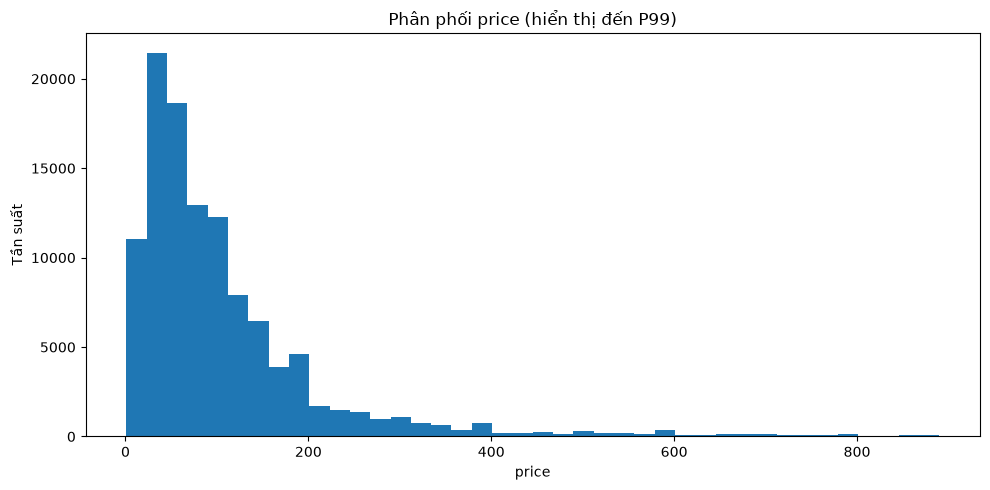

Median = 74.99
P99 = 890.00
Max = 6735.00
Số giá trị lớn hơn P99: 1117 (0.99%)


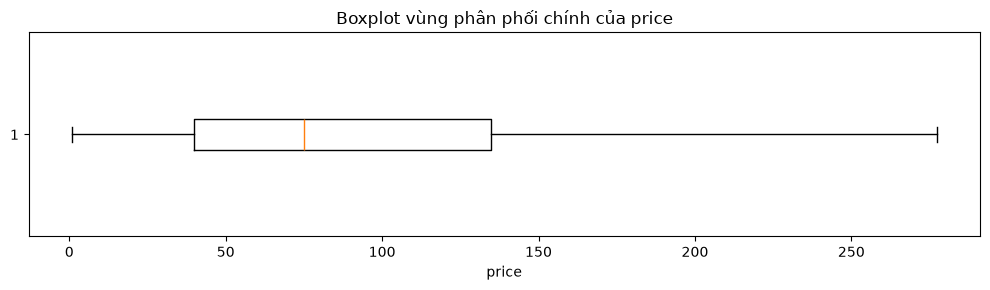

In [114]:
plot_histogram_focus(
    order_items_df,
    "price",
    bins=40,
    quantile=0.99
)

plot_boxplot_focus(
    order_items_df,
    "price"
)

### Phân phối `price`

Histogram được sử dụng vì `price` là biến số liên tục và mục tiêu là xem số lượng sản phẩm tập trung ở các khoảng giá nào.

Kết quả thống kê cho thấy Median = 74,99 nhưng Max = 6.735 và Skewness ≈ 7,92. Đây là phân phối lệch phải rất mạnh.

Nếu biểu đồ hiển thị toàn bộ miền đến 6.735 thì các mức giá phổ biến chỉ chiếm một phần rất nhỏ của trục X và khó quan sát.

Vì vậy, histogram được giới hạn đến P99 để làm rõ vùng chứa 99% dữ liệu. Các giá trị cao hơn P99 vẫn được giữ lại và tiếp tục được kiểm tra bằng IQR.

Boxplot được sử dụng để quan sát vùng Q1–Q3 và Median mà không để các điểm cực lớn kéo giãn biểu đồ.

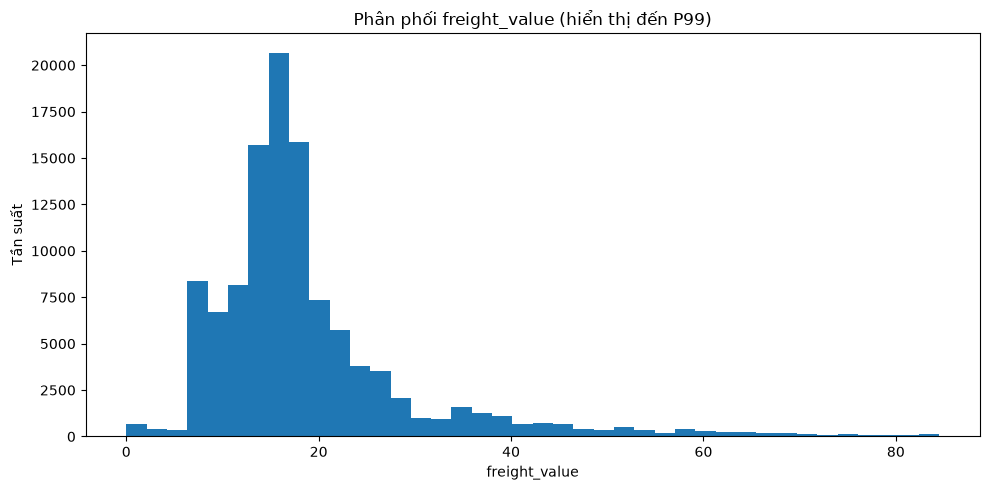

Median = 16.26
P99 = 84.52
Max = 409.68
Số giá trị lớn hơn P99: 1124 (1.00%)


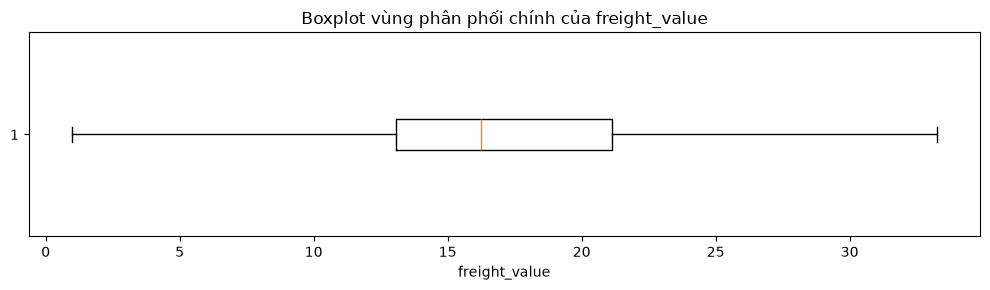

In [115]:
plot_histogram_focus(
    order_items_df,
    "freight_value",
    bins=40,
    quantile=0.99
)

plot_boxplot_focus(
    order_items_df,
    "freight_value"
)

### Phân phối `freight_value`

`freight_value` cũng là biến số liên tục nên được quan sát bằng histogram.

Median bằng 16,26, Q3 bằng 21,15 nhưng Max đạt 409,68 và Skewness ≈ 5,64. Điều này cho thấy chi phí vận chuyển tập trung ở vùng thấp nhưng có một phần đuôi kéo dài về phía các giá trị lớn.

Histogram P99 giúp quan sát vùng phân phối chính mà không làm mất các giá trị phí vận chuyển cao.

Phần VI đã xác định 383 trường hợp `freight_value = 0` không vi phạm quy tắc `freight_value >= 0`. Vì vậy, nếu phương pháp IQR sau đó đánh dấu các giá trị này là outlier phía thấp, chúng vẫn không được xem là dữ liệu lỗi.

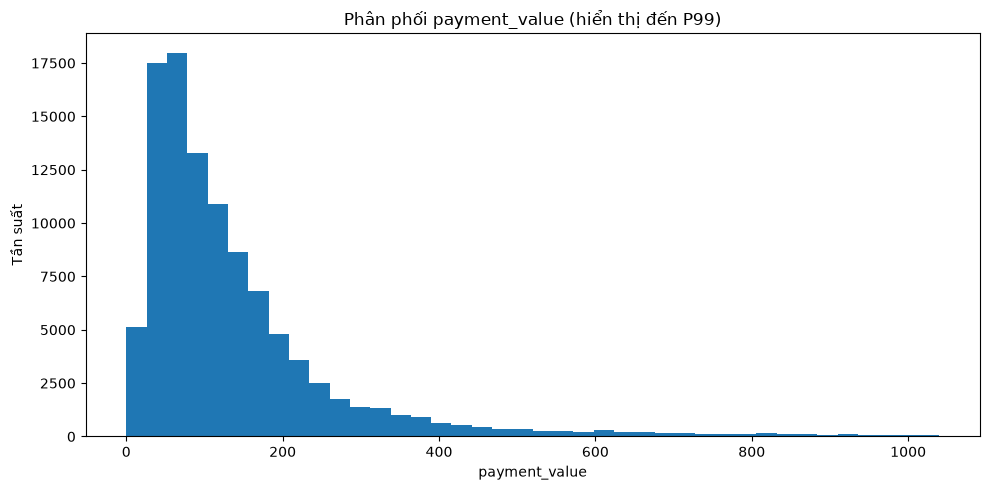

Median = 100.00
P99 = 1039.92
Max = 13664.08
Số giá trị lớn hơn P99: 1039 (1.00%)


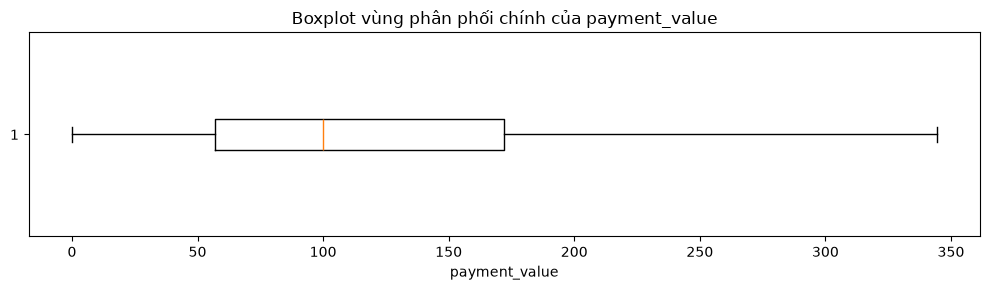

In [116]:
plot_histogram_focus(
    payments_df,
    "payment_value",
    bins=40,
    quantile=0.99
)

plot_boxplot_focus(
    payments_df,
    "payment_value"
)

### Phân phối `payment_value`

`payment_value` có Median = 100 nhưng Mean khoảng 154,10 và Max lên tới 13.664,08.

Khoảng cách rất lớn giữa vùng trung tâm và giá trị cực đại cho thấy phân phối lệch phải mạnh.

Histogram P99 được sử dụng để quan sát rõ các mức thanh toán phổ biến. Những khoản thanh toán lớn hơn P99 vẫn được giữ nguyên để kiểm tra IQR và tiếp tục đối chiếu với giá trị của đơn hàng ở Phần VIII.

Chín trường hợp `payment_value = 0` đã được Phần VI ghi nhận là cần xem xét thêm nhưng chưa xác định là lỗi, vì vậy vẫn được giữ trong dữ liệu.

In [117]:
payment_installments_distribution = (
    payments_df[
        "payment_installments"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "payment_installments"
    )
    .reset_index(
        name="Số bản ghi"
    )
)

display(
    payment_installments_distribution
)

,payment_installments,Số bản ghi
0,0,2
1,1,52546
2,2,12413
3,3,10461
4,4,7098
5,5,5239
6,6,3920
7,7,1626
8,8,4268
9,9,644


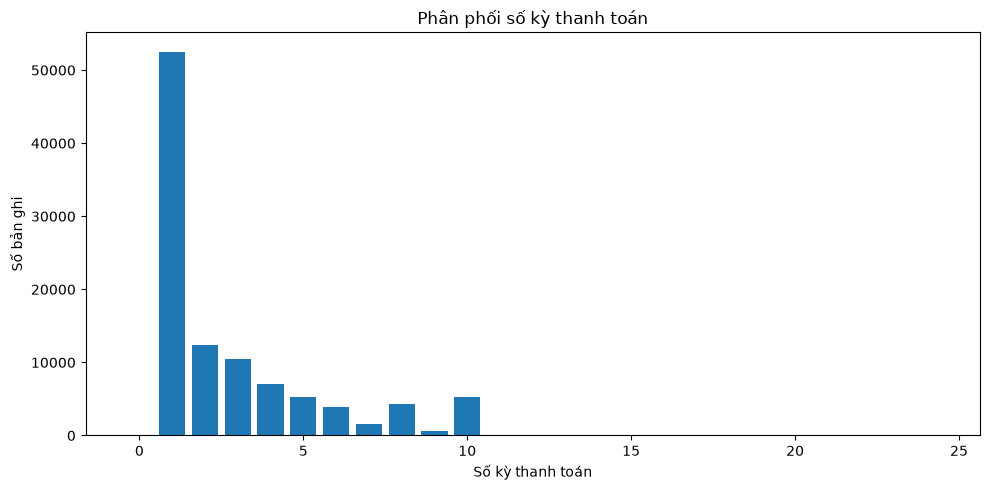

In [118]:
plt.figure(figsize=(10, 5))

plt.bar(
    payment_installments_distribution[
        "payment_installments"
    ],
    payment_installments_distribution[
        "Số bản ghi"
    ]
)

plt.title(
    "Phân phối số kỳ thanh toán"
)

plt.xlabel(
    "Số kỳ thanh toán"
)

plt.ylabel(
    "Số bản ghi"
)

plt.tight_layout()
plt.show()

### Phân phối `payment_installments`

`payment_installments` là biến số đếm rời rạc nên bar chart phù hợp hơn histogram.

Mỗi cột thể hiện số lượng bản ghi tại một số kỳ thanh toán cụ thể.

Kết quả cho thấy thanh toán 1 kỳ xuất hiện nhiều nhất với 52.546 bản ghi. Các mức 2 kỳ và 3 kỳ lần lượt có 12.413 và 10.461 bản ghi, sau đó số lượng nhìn chung giảm ở các số kỳ cao hơn.

Hai trường hợp có số kỳ bằng 0 đã được Phần VI đánh giá riêng bằng quy tắc nghiệp vụ. Chúng không được xử lý như outlier thống kê.

PHÂN PHỐI: product_weight_g


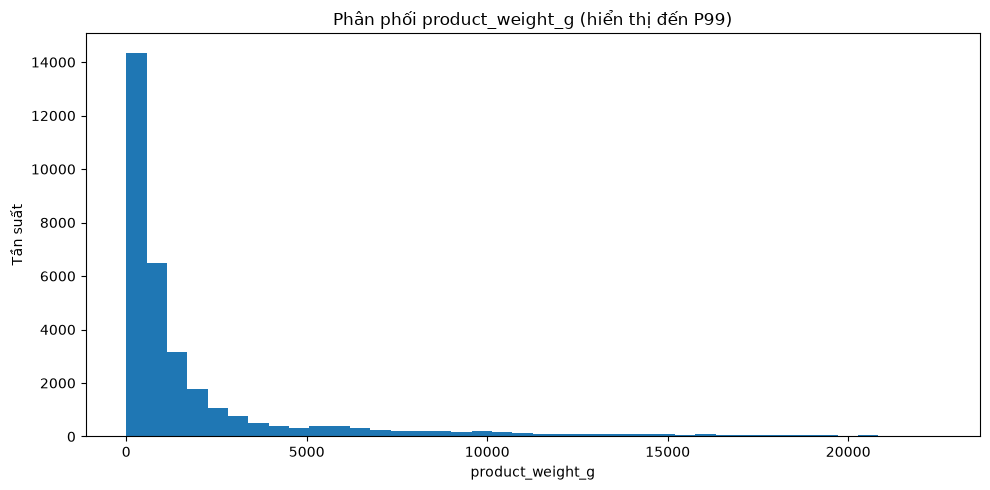

Median = 700.00
P99 = 22539.00
Max = 40425.00
Số giá trị lớn hơn P99: 330 (1.00%)


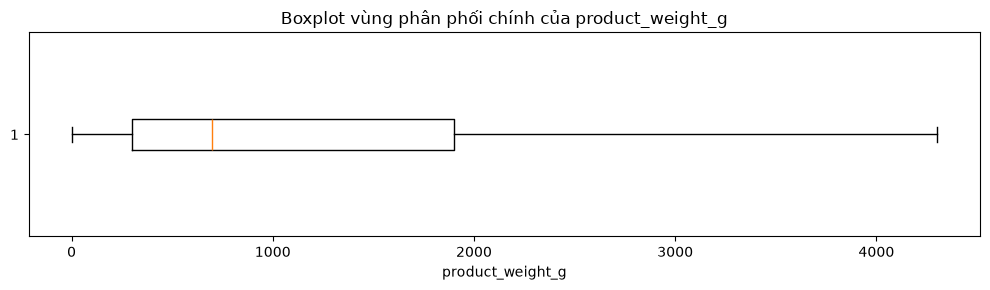

PHÂN PHỐI: product_length_cm


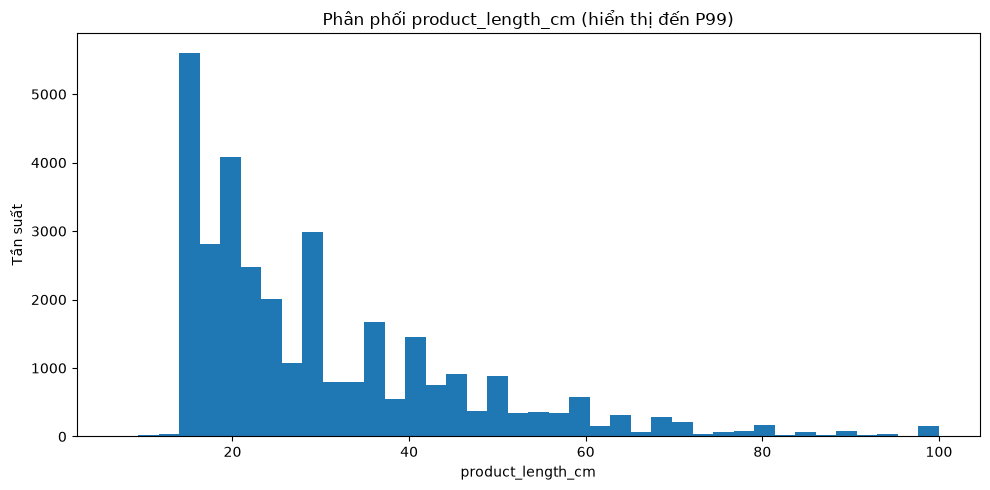

Median = 25.00
P99 = 100.00
Max = 105.00
Số giá trị lớn hơn P99: 214 (0.65%)


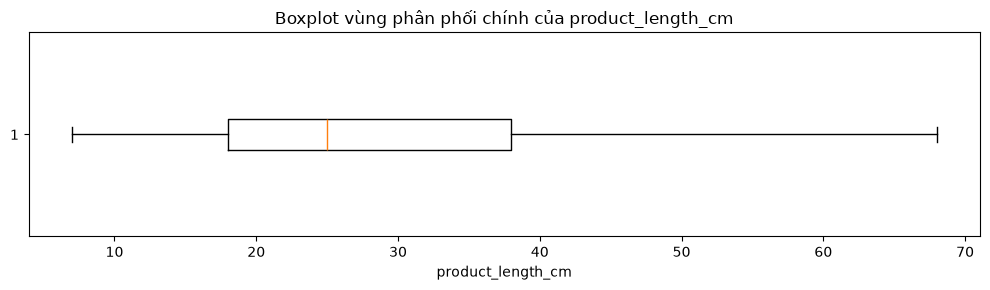

PHÂN PHỐI: product_height_cm


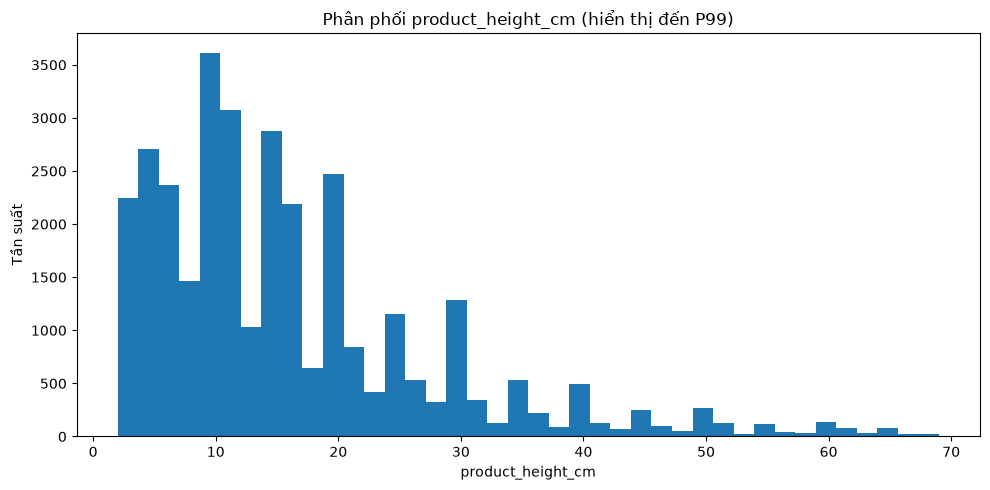

Median = 13.00
P99 = 69.00
Max = 105.00
Số giá trị lớn hơn P99: 323 (0.98%)


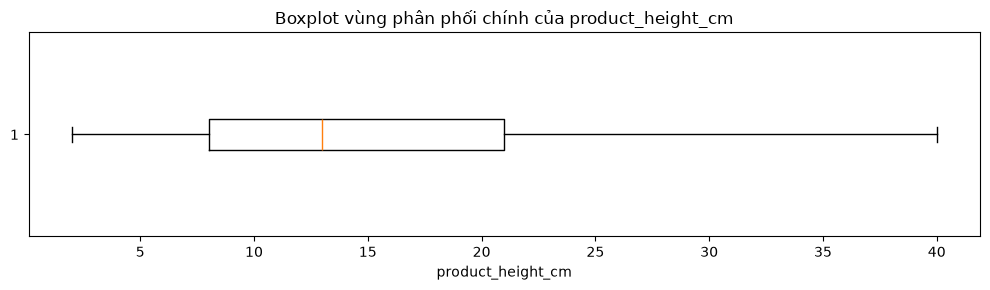

PHÂN PHỐI: product_width_cm


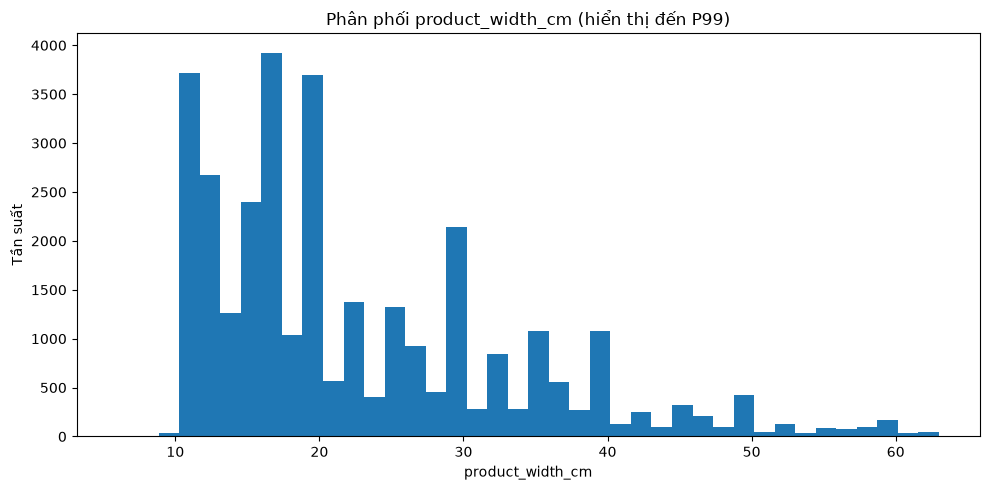

Median = 20.00
P99 = 63.00
Max = 118.00
Số giá trị lớn hơn P99: 324 (0.98%)


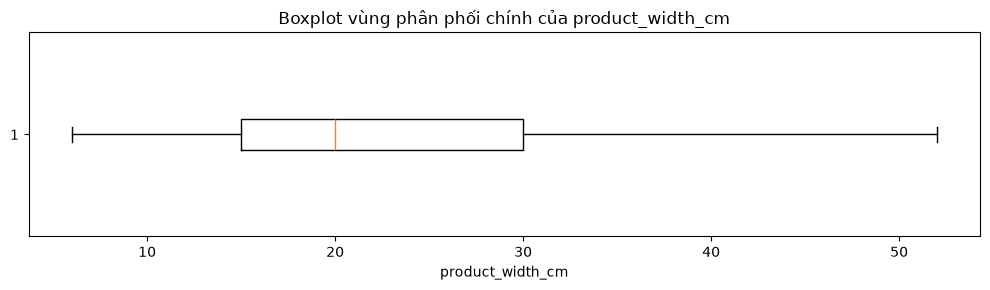

In [119]:
product_physical_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]


for column in product_physical_columns:

    print("=" * 70)
    print(f"PHÂN PHỐI: {column}")
    print("=" * 70)

    plot_histogram_focus(
        products_physical_valid,
        column,
        bins=40,
        quantile=0.99
    )

    plot_boxplot_focus(
        products_physical_valid,
        column
    )

In [120]:
review_score_distribution = (
    reviews_df[
        "review_score"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "review_score"
    )
    .reset_index(
        name="Số đánh giá"
    )
)

review_score_distribution[
    "Tỷ lệ (%)"
] = (
    review_score_distribution[
        "Số đánh giá"
    ]
    / len(reviews_df)
    * 100
).round(2)

display(
    review_score_distribution
)

,review_score,Số đánh giá,Tỷ lệ (%)
0,1,11424,11.51
1,2,3151,3.18
2,3,8179,8.24
3,4,19142,19.29
4,5,57328,57.78


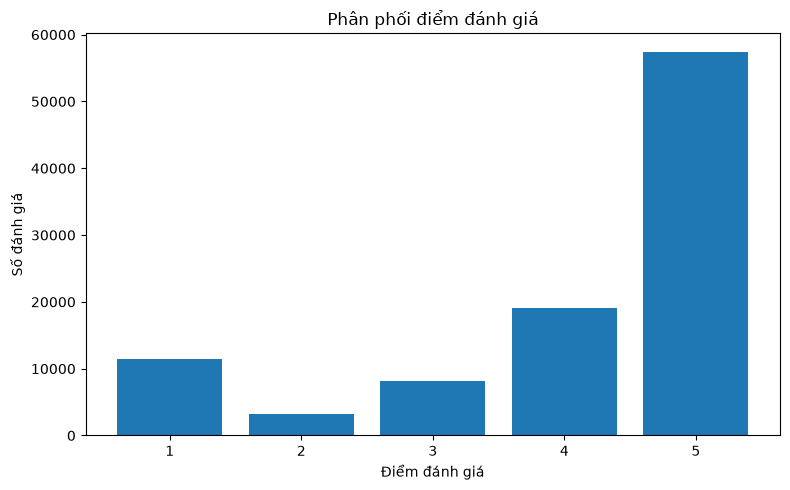

In [121]:
plt.figure(figsize=(8, 5))

plt.bar(
    review_score_distribution[
        "review_score"
    ],
    review_score_distribution[
        "Số đánh giá"
    ]
)

plt.title(
    "Phân phối điểm đánh giá"
)

plt.xlabel(
    "Điểm đánh giá"
)

plt.ylabel(
    "Số đánh giá"
)

plt.xticks(
    review_score_distribution[
        "review_score"
    ]
)

plt.tight_layout()
plt.show()

### Phân phối `review_score`

`review_score` chỉ có năm mức từ 1 đến 5 nên bar chart được sử dụng để so sánh trực tiếp số lượng đánh giá giữa từng mức điểm.

Kết quả:

- điểm 1: 11.424 đánh giá, chiếm 11,51%;
- điểm 2: 3.151 đánh giá, chiếm 3,18%;
- điểm 3: 8.179 đánh giá, chiếm 8,24%;
- điểm 4: 19.142 đánh giá, chiếm 19,29%;
- điểm 5: 57.328 đánh giá, chiếm 57,78%.

Dữ liệu tập trung mạnh ở nhóm điểm cao, đặc biệt điểm 5 chiếm hơn một nửa tổng số đánh giá.

Đây là đặc điểm của phân phối đánh giá, không phải giá trị ngoại lệ. Phần VI đã xác nhận toàn bộ `review_score` đều nằm trong miền hợp lệ từ 1 đến 5 nên không áp dụng IQR cho thuộc tính này.

## 7.3. Phát hiện giá trị ngoại lệ bằng phương pháp IQR

Sau khi quan sát thống kê mô tả và biểu đồ, các biến số liên tục được đánh giá bằng phương pháp **Interquartile Range (IQR)**.

IQR được tính:

`IQR = Q3 - Q1`

Ngưỡng dưới:

`Lower Bound = Q1 - 1.5 × IQR`

Ngưỡng trên:

`Upper Bound = Q3 + 1.5 × IQR`

Các giá trị thấp hơn Lower Bound được gọi là **outlier phía thấp**, còn các giá trị lớn hơn Upper Bound được gọi là **outlier phía cao**.

Việc tách hai nhóm này đặc biệt quan trọng.

Ví dụ, đối với `freight_value`, Lower Bound của IQR có thể lớn hơn 0. Khi đó `freight_value = 0` có thể bị IQR đánh dấu là outlier phía thấp dù Phần VI đã xác định giá trị 0 vẫn có thể hợp lệ về nghiệp vụ.

Do đó, IQR chỉ được sử dụng để phát hiện dữ liệu khác biệt về mặt thống kê. Quyết định giữ, sửa hay loại vẫn phải dựa trên ý nghĩa nghiệp vụ.

In [122]:
def check_iqr_outliers(
    df,
    table_name,
    columns
):
    results = []

    for column in columns:

        values = df[column].dropna()

        # Tính tứ phân vị
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)

        # Tính IQR
        iqr = q3 - q1

        # Ngưỡng IQR
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Outlier phía thấp
        lower_outlier_count = (
            values < lower_bound
        ).sum()

        # Outlier phía cao
        upper_outlier_count = (
            values > upper_bound
        ).sum()

        # Tổng outlier
        total_outlier_count = (
            lower_outlier_count
            +
            upper_outlier_count
        )

        # Tỷ lệ
        outlier_percent = (
            total_outlier_count
            / len(values)
            * 100
        )

        results.append({
            "Bảng": table_name,
            "Cột": column,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outlier phía thấp": lower_outlier_count,
            "Outlier phía cao": upper_outlier_count,
            "Tổng outlier": total_outlier_count,
            "Tỷ lệ outlier (%)": round(
                outlier_percent,
                2
            )
        })

    return pd.DataFrame(results)

In [123]:
order_items_iqr_result = check_iqr_outliers(
    order_items_df,
    "order_items",
    [
        "price",
        "freight_value"
    ]
)

display(
    order_items_iqr_result
)

,Bảng,Cột,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier phía thấp,Outlier phía cao,Tổng outlier,Tỷ lệ outlier (%)
0,order_items,price,39.90,134.90,95.00,-102.600,277.400,0,8427,8427,7.48
1,order_items,freight_value,13.08,21.15,8.07,0.975,33.255,521,11613,12134,10.77


### Phân tích IQR của `order_items`

Đối với `price`:

- Q1 = 39,90;
- Q3 = 134,90;
- IQR = 95;
- Lower Bound = -102,60;
- Upper Bound = 277,40.

Do Lower Bound nhỏ hơn 0 trong khi Phần VI đã xác nhận không có giá âm, các outlier của `price` chủ yếu cần quan tâm ở phía cao.

Những sản phẩm có `price > 277,40` được IQR đánh dấu là khác biệt so với vùng giá chính. Tuy nhiên, giá cao không đồng nghĩa với dữ liệu sai và các bản ghi này không được tự động loại bỏ.

Đối với `freight_value`:

- Q1 = 13,08;
- Q3 = 21,15;
- IQR = 8,07;
- Lower Bound ≈ 0,98;
- Upper Bound ≈ 33,26.

Khác với `price`, Lower Bound của `freight_value` lớn hơn 0. Vì vậy một số giá trị rất thấp, bao gồm các trường hợp `freight_value = 0`, có thể bị IQR đánh dấu là outlier phía thấp.

Phần VI đã xác định 383 trường hợp `freight_value = 0` vẫn thỏa miền nghiệp vụ và có thể phản ánh miễn phí vận chuyển. Do đó, các outlier phía thấp này không được xóa chỉ vì kết quả IQR.

Các outlier phía cao được giữ lại để Phần VIII kiểm tra cùng trọng lượng, sản phẩm và các yếu tố liên quan đến đơn hàng.

In [124]:
payment_iqr_result = check_iqr_outliers(
    payments_df,
    "payments",
    [
        "payment_value"
    ]
)

display(
    payment_iqr_result
)

,Bảng,Cột,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier phía thấp,Outlier phía cao,Tổng outlier,Tỷ lệ outlier (%)
0,payments,payment_value,56.79,171.8375,115.0475,-115.78125,344.40875,0,7981,7981,7.68


### Phân tích IQR của `payment_value`

Kết quả cho thấy:

- Q1 = 56,79;
- Q3 = 171,8375;
- IQR = 115,0475;
- Lower Bound ≈ -115,78;
- Upper Bound ≈ 344,41;
- số outlier = 7.981;
- tỷ lệ outlier = 7,68%.

Lower Bound mang giá trị âm nên không có ý nghĩa như một ngưỡng nghiệp vụ đối với số tiền thanh toán không âm. Nhóm cần quan tâm chủ yếu là các khoản thanh toán lớn hơn khoảng 344,41.

Có tới 7,68% bản ghi bị IQR đánh dấu, cho thấy đây không phải chỉ là một vài điểm cực đoan đơn lẻ.

Do một đơn hàng có thể có nhiều bản ghi thanh toán và giá trị đơn hàng cũng có thể rất lớn, toàn bộ các outlier này được giữ lại để Phần VIII đối chiếu với giá trị sản phẩm của đơn hàng.

In [125]:
products_iqr_result = check_iqr_outliers(
    products_physical_valid,
    "products",
    [
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
)

display(
    products_iqr_result
)

,Bảng,Cột,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier phía thấp,Outlier phía cao,Tổng outlier,Tỷ lệ outlier (%)
0,products,product_weight_g,300.0,1900.0,1600.0,-2100.0,4300.0,0,4551,4551,13.81
1,products,product_length_cm,18.0,38.0,20.0,-12.0,68.0,0,1380,1380,4.19
2,products,product_height_cm,8.0,21.0,13.0,-11.5,40.5,0,1892,1892,5.74
3,products,product_width_cm,15.0,30.0,15.0,-7.5,52.5,0,912,912,2.77


### Phân tích IQR của `products`

Kết quả IQR trên tập thuộc tính vật lý hợp lệ cho thấy:

- `product_weight_g`: Upper Bound = 4.300g, 4.551 outlier, chiếm 13,81%;
- `product_length_cm`: Upper Bound = 68cm, 1.380 outlier, chiếm 4,19%;
- `product_height_cm`: Upper Bound = 40,5cm, 1.892 outlier, chiếm 5,74%;
- `product_width_cm`: Upper Bound = 52,5cm, 912 outlier, chiếm 2,77%.

Các Lower Bound đều nhỏ hơn 0, trong khi các thuộc tính vật lý hợp lệ đều phải lớn hơn 0. Vì vậy, các outlier thống kê ở nhóm này chủ yếu nằm phía cao.

Đáng chú ý nhất là `product_weight_g`, với 13,81% giá trị vượt ngưỡng IQR.

Nếu tự động xóa toàn bộ những trường hợp này, hơn bốn nghìn sản phẩm có trọng lượng lớn sẽ bị mất khỏi dữ liệu. Tỷ lệ cao này cho thấy IQR đang phản ánh đặc điểm phân phối lệch phải của trọng lượng sản phẩm chứ không đủ cơ sở để kết luận dữ liệu sai.

Do đó, các giá trị lớn được giữ lại. Chỉ 4 trường hợp `product_weight_g = 0` đã được phân loại riêng là không hợp lệ ở Phần VI.

## 7.4. Phân bố không gian của `geolocation`

Không áp dụng IQR riêng biệt cho latitude và longitude để quyết định loại dữ liệu.

Một vị trí địa lý được xác định bởi cặp:

`(longitude, latitude)`

Do đó, một latitude nằm xa Median chưa đủ để kết luận tọa độ sai nếu longitude tương ứng tạo thành một vị trí địa lý hợp lý.

Phần VI đã xác nhận:

- toàn bộ latitude nằm trong [-90, 90];
- toàn bộ longitude nằm trong [-180, 180];
- mã bang và thành phố không vi phạm miền kiểm tra.

Ở Phần VII, scatter plot được sử dụng để quan sát cấu trúc không gian của các cặp tọa độ.

Do `geolocation` có hơn một triệu dòng, chỉ lấy một mẫu ngẫu nhiên tối đa 20.000 bản ghi để vẽ. Việc lấy mẫu chỉ phục vụ trực quan hóa và không làm thay đổi dữ liệu nguồn.

In [126]:
geolocation_distribution = numeric_summary(
    geolocation_df,
    "geolocation",
    [
        "geolocation_lat",
        "geolocation_lng"
    ]
)

display(
    geolocation_distribution
)

,Bảng,Cột,Số giá trị,Min,Q1,Median,Mean,Q3,P99,Max,Skewness
0,geolocation,geolocation_lat,1000163,-36.605374,-23.603546,-22.919377,-21.176153,-19.979620,-2.501042,45.065933,1.565147
1,geolocation,geolocation_lng,1000163,-101.466766,-48.573172,-46.637879,-46.390541,-43.767709,-34.938641,121.105394,-0.102417


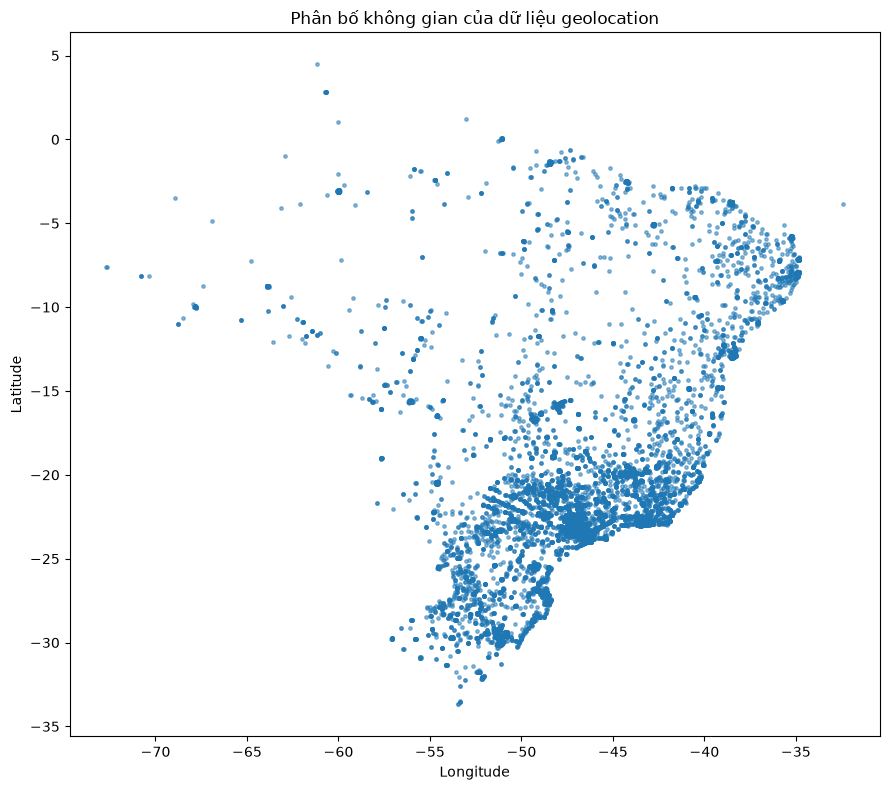

In [127]:
geo_plot_sample = geolocation_df.sample(
    n=min(
        20000,
        len(geolocation_df)
    ),
    random_state=42
)

plt.figure(figsize=(9, 8))

plt.scatter(
    geo_plot_sample[
        "geolocation_lng"
    ],
    geo_plot_sample[
        "geolocation_lat"
    ],
    s=6,
    alpha=0.5
)

plt.xlabel(
    "Longitude"
)

plt.ylabel(
    "Latitude"
)

plt.title(
    "Phân bố không gian của dữ liệu geolocation"
)

plt.tight_layout()
plt.show()

### Phân tích phân bố `geolocation`

Scatter plot cho thấy phần lớn các tọa độ hình thành một vùng phân bố địa lý rõ ràng, đồng thời vẫn có một số điểm nằm xa vùng tập trung chính.

Các điểm nằm xa chưa được xem là lỗi.

Đối với dữ liệu địa lý, cần kiểm tra đồng thời:

- `geolocation_zip_code_prefix`;
- `geolocation_city`;
- `geolocation_state`;
- các tọa độ khác cùng ZIP.

Vì vậy, không sử dụng boxplot hoặc IQR của latitude và longitude làm điều kiện xóa dữ liệu.

Kết quả này được chuyển sang Phần VIII để tiếp tục xem xét quan hệ địa lý và là cơ sở trước khi tổng hợp các quan sát về một tọa độ đại diện cho mỗi mã ZIP trong Transform.

## 7.5. Phân phối thời gian giao hàng

Phần VI đã phát hiện một số timestamp không tuân theo thứ tự nghiệp vụ.

Do đó, thời gian giao hàng chỉ được tính trên những bản ghi có:

- `order_purchase_timestamp` tồn tại;
- `order_delivered_customer_date` tồn tại;
- thời điểm giao khách không xảy ra trước thời điểm mua.

Một biến tạm thời được tạo:

`delivery_days = order_delivered_customer_date - order_purchase_timestamp`

Biến này chỉ phục vụ EDA và không được thêm trực tiếp vào `orders_df`.

In [128]:
# Sử dụng các Series datetime đã tạo ở Phần VI

valid_delivery_mask = (
    purchase.notna()
    &
    delivered.notna()
    &
    (delivered >= purchase)
)


delivery_days = (
    delivered[
        valid_delivery_mask
    ]
    -
    purchase[
        valid_delivery_mask
    ]
).dt.total_seconds() / 86400


delivery_df = pd.DataFrame({
    "delivery_days": delivery_days
})


delivery_days_summary = numeric_summary(
    delivery_df,
    "orders",
    [
        "delivery_days"
    ]
)

display(
    delivery_days_summary
)

,Bảng,Cột,Số giá trị,Min,Q1,Median,Mean,Q3,P99,Max,Skewness
0,orders,delivery_days,96476,0.533414,6.766403,10.217755,12.558702,15.720327,46.049913,209.628611,3.832817


### Thống kê thời gian giao hàng

Có 96.476 đơn hàng đủ điều kiện để tính thời gian giao.

Kết quả:

- Min ≈ 0,53 ngày;
- Q1 ≈ 6,77 ngày;
- Median ≈ 10,22 ngày;
- Mean ≈ 12,56 ngày;
- Q3 ≈ 15,72 ngày;
- Max ≈ 209,63 ngày;
- Skewness ≈ 3,83.

Mean lớn hơn Median và Skewness dương cho thấy phân phối thời gian giao hàng lệch phải.

Phần lớn đơn được giao trong khoảng thời gian tương đối ngắn nhưng tồn tại một số trường hợp giao hàng kéo dài rất lâu.

Vì Max vượt 200 ngày, histogram toàn miền sẽ làm vùng giao hàng phổ biến bị thu nhỏ. Do đó, biểu đồ sử dụng P99 làm giới hạn hiển thị.

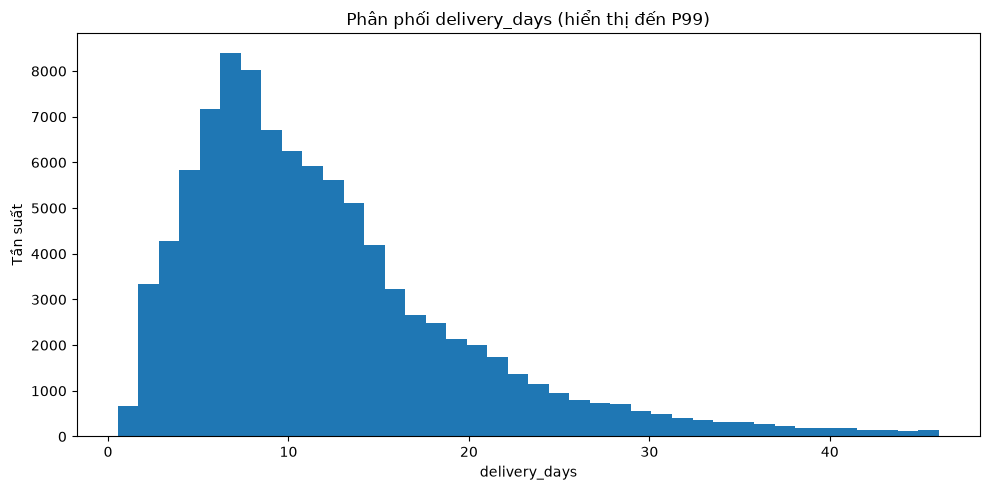

Median = 10.22
P99 = 46.05
Max = 209.63
Số giá trị lớn hơn P99: 965 (1.00%)


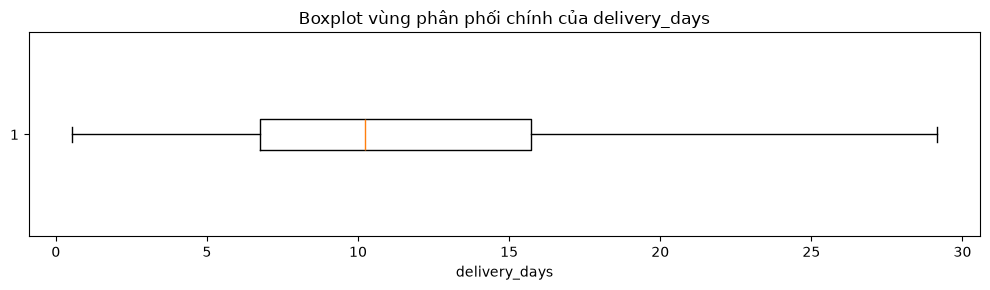

In [129]:
plot_histogram_focus(
    delivery_df,
    "delivery_days",
    bins=40,
    quantile=0.99
)

plot_boxplot_focus(
    delivery_df,
    "delivery_days"
)

In [130]:
delivery_iqr_result = check_iqr_outliers(
    delivery_df,
    "orders",
    [
        "delivery_days"
    ]
)

display(
    delivery_iqr_result
)

,Bảng,Cột,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier phía thấp,Outlier phía cao,Tổng outlier,Tỷ lệ outlier (%)
0,orders,delivery_days,6.766403,15.720327,8.953924,-6.664482,29.151212,0,4899,4899,5.08


### Phân tích ngoại lệ của thời gian giao hàng

Kết quả IQR cho thấy:

- Q1 ≈ 6,77 ngày;
- Q3 ≈ 15,72 ngày;
- IQR ≈ 8,95 ngày;
- Lower Bound ≈ -6,66 ngày;
- Upper Bound ≈ 29,15 ngày.

Lower Bound âm không có ý nghĩa nghiệp vụ vì thời gian giao hàng hợp lệ không thể âm.

Do đó, nhóm cần quan tâm là các đơn có `delivery_days > 29,15`.

Những đơn này được xem là giao hàng dài bất thường so với phần lớn dữ liệu nhưng không bị xóa.

Thời gian giao kéo dài có thể phản ánh vấn đề vận hành thực tế và là dữ liệu quan trọng khi phân tích KPI giao hàng, mức độ trễ và trải nghiệm khách hàng.

In [131]:
iqr_summary = pd.concat(
    [
        order_items_iqr_result,
        payment_iqr_result,
        products_iqr_result,
        delivery_iqr_result
    ],
    ignore_index=True
)

display(
    iqr_summary
)

,Bảng,Cột,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier phía thấp,Outlier phía cao,Tổng outlier,Tỷ lệ outlier (%)
0,order_items,price,39.900000,134.900000,95.000000,-102.600000,277.400000,0,8427,8427,7.48
1,order_items,freight_value,13.080000,21.150000,8.070000,0.975000,33.255000,521,11613,12134,10.77
2,payments,payment_value,56.790000,171.837500,115.047500,-115.781250,344.408750,0,7981,7981,7.68
3,products,product_weight_g,300.000000,1900.000000,1600.000000,-2100.000000,4300.000000,0,4551,4551,13.81
4,products,product_length_cm,18.000000,38.000000,20.000000,-12.000000,68.000000,0,1380,1380,4.19
5,products,product_height_cm,8.000000,21.000000,13.000000,-11.500000,40.500000,0,1892,1892,5.74
6,products,product_width_cm,15.000000,30.000000,15.000000,-7.500000,52.500000,0,912,912,2.77
7,orders,delivery_days,6.766403,15.720327,8.953924,-6.664482,29.151212,0,4899,4899,5.08


In [132]:
iqr_summary_display = iqr_summary[
    [
        "Bảng",
        "Cột",
        "Lower Bound",
        "Upper Bound",
        "Outlier phía thấp",
        "Outlier phía cao",
        "Tổng outlier",
        "Tỷ lệ outlier (%)"
    ]
].copy()

display(
    iqr_summary_display
)

,Bảng,Cột,Lower Bound,Upper Bound,Outlier phía thấp,Outlier phía cao,Tổng outlier,Tỷ lệ outlier (%)
0,order_items,price,-102.600000,277.400000,0,8427,8427,7.48
1,order_items,freight_value,0.975000,33.255000,521,11613,12134,10.77
2,payments,payment_value,-115.781250,344.408750,0,7981,7981,7.68
3,products,product_weight_g,-2100.000000,4300.000000,0,4551,4551,13.81
4,products,product_length_cm,-12.000000,68.000000,0,1380,1380,4.19
5,products,product_height_cm,-11.500000,40.500000,0,1892,1892,5.74
6,products,product_width_cm,-7.500000,52.500000,0,912,912,2.77
7,orders,delivery_days,-6.664482,29.151212,0,4899,4899,5.08


## 7.6. Kết luận Phần VII: Phân phối và giá trị ngoại lệ

Phần VII sử dụng kết hợp thống kê mô tả, trực quan hóa và phương pháp IQR để đánh giá đặc điểm phân phối của các thuộc tính số.

Kết quả cho thấy nhiều biến của bộ dữ liệu Olist có phân phối lệch phải, thể hiện qua Mean lớn hơn Median, Skewness dương và sự tồn tại của một phần đuôi kéo dài về phía các giá trị lớn.

Các trường hợp đáng chú ý gồm:

- `price` có Skewness khoảng 7,92 và Max đạt 6.735 trong khi Median chỉ 74,99;
- `freight_value` có Skewness khoảng 5,64;
- `payment_value` có 7.981 outlier theo IQR, chiếm 7,68%;
- `product_weight_g` có 4.551 outlier, chiếm 13,81%;
- `product_length_cm` có 1.380 outlier, chiếm 4,19%;
- `product_height_cm` có 1.892 outlier, chiếm 5,74%;
- `product_width_cm` có 912 outlier, chiếm 2,77%;
- `delivery_days` có phân phối lệch phải với Median khoảng 10,22 ngày nhưng Max lên tới khoảng 209,63 ngày.

IQR chỉ phản ánh mức độ khác biệt của một giá trị so với vùng dữ liệu trung tâm. Kết quả không được sử dụng để tự động xóa bản ghi.

Điều này thể hiện rõ ở `freight_value`. Do Lower Bound của IQR lớn hơn 0, một số giá trị phí vận chuyển bằng 0 có thể bị đánh dấu là outlier phía thấp. Tuy nhiên, Phần VI đã xác định `freight_value = 0` vẫn có thể phù hợp nghiệp vụ nên các trường hợp này tiếp tục được giữ.

Tương tự, tỷ lệ outlier của `product_weight_g` lên tới 13,81% cho thấy việc loại toàn bộ các giá trị vượt ngưỡng IQR sẽ làm mất một nhóm lớn sản phẩm có trọng lượng cao nhưng có khả năng hoàn toàn hợp lệ.

Đối với `review_score`, phân phối tần suất cho thấy điểm 5 chiếm 57,78%. Đây là đặc điểm của dữ liệu đánh giá chứ không phải outlier.

Đối với `geolocation`, scatter plot được sử dụng thay cho IQR riêng trên latitude và longitude. Các điểm nằm xa vùng tập trung được giữ lại để kiểm tra trong bối cảnh ZIP, thành phố và bang.

### Đầu ra của Phần VII

Sau bước này thu được:

1. Đặc điểm phân phối của các đại lượng số chính.
2. Mức độ lệch của từng biến.
3. P99 phục vụ trực quan hóa các phân phối lệch mạnh.
4. Lower Bound và Upper Bound theo IQR.
5. Số outlier phía thấp và phía cao.
6. Tỷ lệ outlier của từng thuộc tính.
7. Danh sách các nhóm dữ liệu cần tiếp tục đánh giá trong bối cảnh nghiệp vụ.

Kết quả Phần VII trở thành đầu vào cho **Phần VIII - Kiểm tra quan hệ giữa các bảng**.

Ở Phần VIII, các giá trị không còn được đánh giá riêng lẻ mà được đặt trong mối quan hệ với dữ liệu liên quan, chẳng hạn:

- tổng `price` và `freight_value` của đơn hàng so với tổng `payment_value`;
- trọng lượng sản phẩm so với chi phí vận chuyển;
- `shipping_limit_date` so với thời điểm đặt hàng;
- thời gian giao hàng so với ngày giao dự kiến;
- dữ liệu ZIP của khách hàng và người bán so với dữ liệu địa lý.

Sau khi kiểm tra các quan hệ này, Phần IX sẽ tổng hợp toàn bộ kết quả từ Missing Values, duplicate, khóa, quy tắc nghiệp vụ và outlier để xác định các quy tắc cuối cùng cho `transform.py` và `validate.py`.

# VIII. Kiểm tra quan hệ giữa các bảng

## 8.0. Mục đích kiểm tra

Các phần trước đã kiểm tra chất lượng của từng bảng riêng biệt. Tuy nhiên, khi xây dựng ETL và Data Warehouse, nhiều bảng phải được liên kết với nhau. Nếu không kiểm soát đúng mức độ chi tiết của từng bảng, phép nối có thể làm nhân bản dữ liệu hoặc tạo ra các chỉ số sai.

Phần VIII tập trung vào ba vấn đề có ảnh hưởng trực tiếp đến quá trình Transform và thiết kế Data Warehouse:

1. Đối chiếu tổng giá trị đơn hàng với tổng giá trị thanh toán.
2. Kiểm tra nguy cơ nhân bản khi liên kết `order_items` với `payments`.
3. Kiểm tra nguy cơ nhân bản khi liên kết `customers` và `sellers` với `geolocation`.

### Đầu vào từ các phần trước

- Phần I đã xác định mức độ chi tiết của từng bảng.
- Phần IV cho thấy một `order_id` có thể xuất hiện nhiều lần trong `order_items` và `payments`, đồng thời một ZIP có thể xuất hiện nhiều lần trong `geolocation`.
- Phần V xác nhận các khóa ngoại chính có thể liên kết giữa các bảng.
- Phần VI và VII đã xác định các giá trị không hợp lệ và các ngoại lệ cần lưu ý.

Phần VIII không làm thay đổi dữ liệu nguồn. Các DataFrame được tạo chỉ phục vụ kiểm tra và đưa ra quyết định cho bước Transform.

## 8.1. Đối chiếu giá trị đơn hàng và giá trị thanh toán

Bảng `order_items` chứa từng dòng sản phẩm của đơn hàng, trong khi `payments` chứa từng bản ghi thanh toán.

Một đơn hàng có thể có nhiều sản phẩm và cũng có thể có nhiều bản ghi thanh toán. Vì vậy, không thể nối trực tiếp hai bảng rồi cộng các giá trị tiền tệ.

Trước khi đối chiếu, hai bảng được tổng hợp riêng về cùng mức **một dòng cho mỗi `order_id`**.

Phương pháp thực hiện:

- `order_items`: tính tổng `price` và `freight_value` theo `order_id`;
- `payments`: tính tổng `payment_value` theo `order_id`;
- sau đó so sánh:

`Tổng thanh toán - (Tổng giá sản phẩm + Tổng phí vận chuyển)`

Do dữ liệu tiền tệ sử dụng số thực, mức sai lệch tuyệt đối không quá `0.01` được xem là khớp.

In [133]:
# Tổng hợp order_items về một dòng cho mỗi order_id

order_items_by_order = (
    order_items_df
    .groupby("order_id", as_index=False)
    .agg(
        item_count=("order_item_id", "count"),
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum")
    )
)

# Tổng giá trị đơn hàng từ phía order_items
order_items_by_order["order_value"] = (
    order_items_by_order["total_price"]
    +
    order_items_by_order["total_freight"]
)

display(order_items_by_order.head())

print(
    "Số đơn hàng có dữ liệu order_items:",
    len(order_items_by_order)
)

,order_id,item_count,total_price,total_freight,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,218.04


Số đơn hàng có dữ liệu order_items: 98666


In [134]:
# Tổng hợp payments về một dòng cho mỗi order_id

payments_by_order = (
    payments_df
    .groupby("order_id", as_index=False)
    .agg(
        payment_count=("payment_sequential", "count"),
        payment_total=("payment_value", "sum")
    )
)

display(payments_by_order.head())

print(
    "Số đơn hàng có dữ liệu payments:",
    len(payments_by_order)
)

,order_id,payment_count,payment_total
0,00010242fe8c5a6d1ba2dd792cb16214,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,259.83
2,000229ec398224ef6ca0657da4fc703e,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,218.04


Số đơn hàng có dữ liệu payments: 99440


### Vì sao phải tổng hợp trước khi đối chiếu?

Hai DataFrame trên chỉ là dữ liệu tạm phục vụ EDA.

Việc tổng hợp không làm thay đổi `order_items_df` hoặc `payments_df`.

Mục đích là đưa hai bảng về cùng mức một dòng cho mỗi đơn hàng. Khi đó:

- `order_value` biểu diễn tổng giá sản phẩm và phí vận chuyển của đơn;
- `payment_total` biểu diễn tổng số tiền đã thanh toán.

Hai giá trị này mới có thể được đối chiếu trực tiếp với nhau.

In [135]:
# Liên kết hai bảng đã được tổng hợp theo order_id

financial_check = (
    order_items_by_order
    .merge(
        payments_by_order,
        on="order_id",
        how="outer",
        indicator=True,
        validate="one_to_one"
    )
)

# Xác định đơn có dữ liệu ở cả hai phía
financial_check["data_status"] = (
    financial_check["_merge"]
    .map({
        "both": "Có cả items và payment",
        "left_only": "Có items nhưng thiếu payment",
        "right_only": "Có payment nhưng thiếu items"
    })
)

# Tính chênh lệch chỉ khi có dữ liệu ở cả hai phía
both_mask = financial_check["_merge"].eq("both")

financial_check.loc[
    both_mask,
    "difference"
] = (
    financial_check.loc[both_mask, "payment_total"]
    -
    financial_check.loc[both_mask, "order_value"]
)

# Cho phép sai số tiền tệ tối đa 0.01
financial_check.loc[
    both_mask,
    "financial_match"
] = (
    financial_check.loc[
        both_mask,
        "difference"
    ].abs()
    <= 0.01
)

display(financial_check.head())

,order_id,item_count,total_price,total_freight,order_value,payment_count,payment_total,_merge,data_status,difference,financial_match
0,00010242fe8c5a6d1ba2dd792cb16214,1.0,58.90,13.29,72.19,1.0,72.19,both,Có cả items và payment,0.000000e+00,True
1,00018f77f2f0320c557190d7a144bdd3,1.0,239.90,19.93,259.83,1.0,259.83,both,Có cả items và payment,0.000000e+00,True
2,000229ec398224ef6ca0657da4fc703e,1.0,199.00,17.87,216.87,1.0,216.87,both,Có cả items và payment,0.000000e+00,True
3,00024acbcdf0a6daa1e931b038114c75,1.0,12.99,12.79,25.78,1.0,25.78,both,Có cả items và payment,0.000000e+00,True
4,00042b26cf59d7ce69dfabb4e55b4fd9,1.0,199.90,18.14,218.04,1.0,218.04,both,Có cả items và payment,-2.842171e-14,True


In [136]:
# Tổng hợp tình trạng dữ liệu giữa hai bảng

financial_presence_summary = (
    financial_check["data_status"]
    .value_counts()
    .rename_axis("Tình trạng")
    .reset_index(name="Số đơn hàng")
)

display(financial_presence_summary)


# Chỉ xét các đơn có dữ liệu ở cả hai phía
financial_match_summary = (
    financial_check.loc[
        both_mask,
        "financial_match"
    ]
    .value_counts()
    .rename_axis("Khớp giá trị")
    .reset_index(name="Số đơn hàng")
)

display(financial_match_summary)

,Tình trạng,Số đơn hàng
0,Có cả items và payment,98665
1,Có payment nhưng thiếu items,775
2,Có items nhưng thiếu payment,1


,Khớp giá trị,Số đơn hàng
0,True,98284
1,False,381


### Phân tích kết quả đối chiếu tài chính

Kết quả cần được đọc theo hai nhóm.

**Nhóm 1 - Thiếu dữ liệu ở một phía**

Nếu có đơn xuất hiện trong `order_items` nhưng không có trong `payments`, hoặc ngược lại, các đơn này được ghi nhận để kiểm tra thêm. EDA không tự động xóa các bản ghi này.

**Nhóm 2 - Có dữ liệu ở cả hai phía nhưng tổng tiền không khớp**

Các đơn có:

`|payment_total - order_value| > 0.01`

được đưa vào danh sách cần xem xét.

Kết quả này là đầu vào cho Phần IX để quyết định có cần bổ sung kiểm tra trong `validate.py`, gắn cờ dữ liệu hoặc xử lý trong bước Transform hay không.

In [137]:
# Đếm số dòng order_items của từng order_id

item_rows_per_order = (
    order_items_df
    .groupby("order_id")
    .size()
    .rename("item_rows")
)


# Đếm số dòng payments của từng order_id

payment_rows_per_order = (
    payments_df
    .groupby("order_id")
    .size()
    .rename("payment_rows")
)


# Ghép số lượng của hai bảng theo order_id

join_check = (
    pd.concat(
        [
            item_rows_per_order,
            payment_rows_per_order
        ],
        axis=1
    )
    .fillna(0)
    .reset_index()
)


# Chỉ xét các order xuất hiện ở cả hai bảng
both_tables = (
    (join_check["item_rows"] > 0)
    &
    (join_check["payment_rows"] > 0)
)


# Nếu join trực tiếp:
# số dòng sinh ra = số item × số payment

join_check["direct_join_rows"] = (
    join_check["item_rows"]
    *
    join_check["payment_rows"]
)


# Quan hệ nhiều - nhiều
many_to_many_orders = (
    join_check[
        (join_check["item_rows"] > 1)
        &
        (join_check["payment_rows"] > 1)
    ]
)

In [138]:
join_multiplicity_summary = pd.DataFrame({
    "Chỉ tiêu": [
        "Số order_id có ở cả order_items và payments",
        "Số order_id có nhiều items và nhiều payments",
        "Số dòng dự kiến nếu join trực tiếp",
        "Số dòng nếu tổng hợp 1 dòng/order trước khi join"
    ],

    "Kết quả": [
        both_tables.sum(),

        len(many_to_many_orders),

        int(
            join_check.loc[
                both_tables,
                "direct_join_rows"
            ].sum()
        ),

        int(
            both_tables.sum()
        )
    ]
})

display(join_multiplicity_summary)

,Chỉ tiêu,Kết quả
0,Số order_id có ở cả order_items và payments,98665
1,Số order_id có nhiều items và nhiều payments,275
2,Số dòng dự kiến nếu join trực tiếp,117601
3,Số dòng nếu tổng hợp 1 dòng/order trước khi join,98665


In [139]:
# Xem một số đơn có mức nhân bản cao nhất

display(
    many_to_many_orders
    .sort_values(
        "direct_join_rows",
        ascending=False
    )
    .head(20)
)

,order_id,item_rows,payment_rows,direct_join_rows
52745,895ab968e7bb0d5659d16cd74cd1650c,3.0,21.0,63.0
98247,fedcd9f7ccdc8cba3a18defedd1a5547,2.0,19.0,38.0
76422,c6492b842ac190db807c15aff21a7dd6,2.0,12.0,24.0
40301,68986e4324f6a21481df4e6e89abcf01,2.0,12.0,24.0
27113,465c2e1bee4561cb39e0db8c5993aafc,2.0,12.0,24.0
62660,a3725dfe487d359b5be08cac48b64ec5,6.0,4.0,24.0
10831,1c11d0f4353b31ac3417fbfa5f0f2a8a,7.0,3.0,21.0
57290,958c6a70e60365b576dd696ad29bbca2,3.0,7.0,21.0
20866,364f451ee38a4268d7c15d317021eb35,2.0,10.0,20.0
22370,3a1ce4053005d669ac4e0047a13573cf,4.0,4.0,16.0


### Phân tích nguy cơ nhân bản

Nếu số dòng dự kiến sau khi nối trực tiếp lớn hơn đáng kể số `order_id`, điều này chứng minh rằng phép nối `order_items` với `payments` bằng riêng `order_id` có thể làm tăng số dòng.

Khi đó, các đại lượng như:

- `price`;
- `freight_value`;
- `payment_value`

có thể bị lặp lại. Nếu tiếp tục sử dụng `SUM()` trên kết quả nối, các chỉ số tài chính có thể bị tính lớn hơn thực tế.

Do đó, quy tắc được rút ra cho ETL và Data Warehouse là:

**Khi cần phân tích ở mức đơn hàng, `order_items` và `payments` phải được tổng hợp riêng theo `order_id` trước khi liên kết.**

Các bảng Fact chi tiết vẫn được giữ ở mức độ chi tiết ban đầu; không cần gộp chúng thành một bảng duy nhất trong Data Warehouse.

## 8.3. Kiểm tra nguy cơ nhân bản khi liên kết với `geolocation`

Phần IV đã xác định `geolocation_zip_code_prefix` không duy nhất. Một mã ZIP có thể xuất hiện trên nhiều dòng vì chứa nhiều quan sát tọa độ.

Trong khi đó:

- `customers.customer_zip_code_prefix` được dùng để tra cứu vị trí khách hàng;
- `sellers.seller_zip_code_prefix` được dùng để tra cứu vị trí người bán.

Nếu nối trực tiếp `customers` hoặc `sellers` với bảng `geolocation` nguồn, một khách hàng hoặc người bán có thể bị nhân thành nhiều dòng khi ZIP tương ứng có nhiều quan sát địa lý.

Phương pháp sử dụng tiếp tục là **Join Cardinality Analysis**.

Mục tiêu là xác định mức tăng số dòng nếu dữ liệu địa lý được liên kết trực tiếp mà chưa tổng hợp về một bản ghi cho mỗi ZIP.

In [142]:
# Đếm số quan sát geolocation của từng ZIP

geo_rows_per_zip = (
    geolocation_df
    .groupby(
        "geolocation_zip_code_prefix"
    )
    .size()
    .rename("geo_rows")
)


geo_summary = pd.DataFrame({
    "Chỉ tiêu": [
        "Số ZIP khác nhau",
        "Số ZIP có nhiều hơn 1 quan sát",
        "Số quan sát lớn nhất của một ZIP"
    ],

    "Kết quả": [
        len(geo_rows_per_zip),

        (
            geo_rows_per_zip > 1
        ).sum(),

        geo_rows_per_zip.max()
    ]
})


display(geo_summary)

,Chỉ tiêu,Kết quả
0,Số ZIP khác nhau,19015
1,Số ZIP có nhiều hơn 1 quan sát,17972
2,Số quan sát lớn nhất của một ZIP,1146


In [143]:
# Ánh xạ số lượng dòng geolocation cho ZIP của từng khách hàng

customer_geo_check = (
    customers_df[
        [
            "customer_id",
            "customer_zip_code_prefix"
        ]
    ]
    .copy()
)


customer_geo_check["geo_rows"] = (
    customer_geo_check[
        "customer_zip_code_prefix"
    ]
    .map(geo_rows_per_zip)
)


customer_geo_summary = pd.DataFrame({
    "Chỉ tiêu": [
        "Số khách hàng ban đầu",
        "Số khách hàng tìm thấy ZIP trong geolocation",
        "Số khách hàng có ZIP ánh xạ nhiều dòng geolocation",
        "Số dòng dự kiến sau inner join trực tiếp"
    ],

    "Kết quả": [
        len(customer_geo_check),

        customer_geo_check[
            "geo_rows"
        ].notna().sum(),

        (
            customer_geo_check[
                "geo_rows"
            ] > 1
        ).sum(),

        int(
            customer_geo_check[
                "geo_rows"
            ]
            .fillna(0)
            .sum()
        )
    ]
})


display(customer_geo_summary)

,Chỉ tiêu,Kết quả
0,Số khách hàng ban đầu,99441
1,Số khách hàng tìm thấy ZIP trong geolocation,99163
2,Số khách hàng có ZIP ánh xạ nhiều dòng geolocation,98976
3,Số dòng dự kiến sau inner join trực tiếp,15083455


In [144]:
# Ánh xạ số lượng dòng geolocation cho ZIP của từng khách hàng

customer_geo_check = (
    customers_df[
        [
            "customer_id",
            "customer_zip_code_prefix"
        ]
    ]
    .copy()
)


customer_geo_check["geo_rows"] = (
    customer_geo_check[
        "customer_zip_code_prefix"
    ]
    .map(geo_rows_per_zip)
)


customer_geo_summary = pd.DataFrame({
    "Chỉ tiêu": [
        "Số khách hàng ban đầu",
        "Số khách hàng tìm thấy ZIP trong geolocation",
        "Số khách hàng có ZIP ánh xạ nhiều dòng geolocation",
        "Số dòng dự kiến sau inner join trực tiếp"
    ],

    "Kết quả": [
        len(customer_geo_check),

        customer_geo_check[
            "geo_rows"
        ].notna().sum(),

        (
            customer_geo_check[
                "geo_rows"
            ] > 1
        ).sum(),

        int(
            customer_geo_check[
                "geo_rows"
            ]
            .fillna(0)
            .sum()
        )
    ]
})


display(customer_geo_summary)

,Chỉ tiêu,Kết quả
0,Số khách hàng ban đầu,99441
1,Số khách hàng tìm thấy ZIP trong geolocation,99163
2,Số khách hàng có ZIP ánh xạ nhiều dòng geolocation,98976
3,Số dòng dự kiến sau inner join trực tiếp,15083455


In [145]:
# Ánh xạ số lượng dòng geolocation cho ZIP của từng người bán

seller_geo_check = (
    sellers_df[
        [
            "seller_id",
            "seller_zip_code_prefix"
        ]
    ]
    .copy()
)


seller_geo_check["geo_rows"] = (
    seller_geo_check[
        "seller_zip_code_prefix"
    ]
    .map(geo_rows_per_zip)
)


seller_geo_summary = pd.DataFrame({
    "Chỉ tiêu": [
        "Số người bán ban đầu",
        "Số người bán tìm thấy ZIP trong geolocation",
        "Số người bán có ZIP ánh xạ nhiều dòng geolocation",
        "Số dòng dự kiến sau inner join trực tiếp"
    ],

    "Kết quả": [
        len(seller_geo_check),

        seller_geo_check[
            "geo_rows"
        ].notna().sum(),

        (
            seller_geo_check[
                "geo_rows"
            ] > 1
        ).sum(),

        int(
            seller_geo_check[
                "geo_rows"
            ]
            .fillna(0)
            .sum()
        )
    ]
})


display(seller_geo_summary)

,Chỉ tiêu,Kết quả
0,Số người bán ban đầu,3095
1,Số người bán tìm thấy ZIP trong geolocation,3088
2,Số người bán có ZIP ánh xạ nhiều dòng geolocation,3079
3,Số dòng dự kiến sau inner join trực tiếp,435087


### Phân tích quan hệ với `geolocation`

Kết quả cần so sánh số bản ghi ban đầu của `customers` và `sellers` với số dòng dự kiến sau khi nối trực tiếp với `geolocation`.

Nếu số dòng tăng lên đáng kể, nguyên nhân là một ZIP đang ánh xạ tới nhiều quan sát tọa độ.

Điều này xác nhận bảng `geolocation` nguồn không phù hợp để nối trực tiếp vào Dimension khách hàng hoặc người bán.

Quy tắc được đưa ra cho bước Transform:

1. loại các dòng `geolocation` trùng hoàn toàn đã xác định ở Phần IV;
2. kiểm tra tính hợp lệ của dữ liệu tọa độ;
3. tổng hợp dữ liệu về một bản ghi đại diện cho mỗi `geolocation_zip_code_prefix`;
4. sau đó mới sử dụng ZIP để bổ sung thông tin địa lý cho khách hàng và người bán.

Cách này giúp tránh làm tăng số lượng bản ghi của Dimension sau phép nối.

## 8.4. Kết luận Phần VIII

Phần VIII tập trung vào những quan hệ có ảnh hưởng trực tiếp đến tính đúng đắn của quá trình ETL và thiết kế Data Warehouse.

Thứ nhất, `order_items` và `payments` được tổng hợp riêng về mức một dòng cho mỗi `order_id` trước khi đối chiếu. Kết quả giúp xác định các đơn thiếu dữ liệu ở một phía hoặc có chênh lệch giữa tổng giá trị sản phẩm, phí vận chuyển và tổng thanh toán.

Thứ hai, việc kiểm tra số lượng bản ghi theo `order_id` cho phép đánh giá nguy cơ nhân bản khi nối trực tiếp `order_items` với `payments`. Nếu một đơn có nhiều dòng ở cả hai bảng, phép nối sẽ tạo quan hệ nhiều-nhiều và có thể làm sai các phép tổng hợp tiền tệ. Vì vậy, khi phân tích ở mức đơn hàng, hai bảng phải được tổng hợp riêng trước khi liên kết.

Thứ ba, một `geolocation_zip_code_prefix` có thể tương ứng với nhiều dòng tọa độ. Do đó, bảng `geolocation` nguồn không được nối trực tiếp với `customers` hoặc `sellers`. Dữ liệu địa lý cần được chuẩn hóa về một bản ghi đại diện cho mỗi ZIP trước khi bổ sung vào các Dimension.

### Đầu ra cho Phần IX

Kết quả Phần VIII tạo ra ba quyết định chính:

1. Đối chiếu giá trị tài chính phải thực hiện sau khi tổng hợp theo `order_id`.
2. Không nối trực tiếp hai bảng Fact có nhiều dòng theo cùng `order_id` khi tính chỉ số ở mức đơn hàng.
3. `geolocation` phải được tổng hợp về một dòng cho mỗi ZIP trước khi liên kết với khách hàng và người bán.

Các quyết định này cùng với kết quả từ các phần trước sẽ được tổng hợp tại **Phần IX - Tổng hợp các quyết định làm sạch dữ liệu**, từ đó xác định các quy tắc cần triển khai trong `transform.py` và `validate.py`.

# IX. Tổng hợp các vấn đề và quyết định Transform

Phần IX không thực hiện thêm một vòng khảo sát dữ liệu mới mà tổng hợp các kết quả đã thu được từ các bước EDA trước đó.

Mục tiêu là chuyển các vấn đề đã phát hiện thành các quyết định cụ thể cho quá trình ETL, gồm:

- vấn đề nào cần được xử lý trong `transform.py`;
- vấn đề nào chỉ cần kiểm tra trong `validate.py`;
- trường hợp nào được giữ nguyên vì vẫn hợp lệ về nghiệp vụ;
- trường hợp nào cần chuẩn hóa trước khi đưa vào Data Warehouse.

Các quyết định chỉ dựa trên những vấn đề đã được xác nhận trong EDA, không tự bổ sung thêm quy tắc mới.

In [148]:
transform_decisions = pd.DataFrame([
    {
        "Bảng": "customers",
        "Vấn đề": "customer_zip_code_prefix được đọc dạng số, có thể mất số 0 đầu",
        "Quyết định": "Chuyển sang string và zfill(5)",
        "Thực hiện tại": "transform.py"
    },

    {
        "Bảng": "sellers",
        "Vấn đề": "seller_zip_code_prefix được đọc dạng số, có thể mất số 0 đầu",
        "Quyết định": "Chuyển sang string và zfill(5)",
        "Thực hiện tại": "transform.py"
    },

    {
        "Bảng": "geolocation",
        "Vấn đề": "ZIP cần đồng nhất kiểu dữ liệu với customers và sellers",
        "Quyết định": "Chuyển sang string và zfill(5)",
        "Thực hiện tại": "transform.py"
    },

    {
        "Bảng": "geolocation",
        "Vấn đề": "Có 261831 dòng trùng hoàn toàn",
        "Quyết định": "Loại exact duplicate",
        "Thực hiện tại": "transform.py"
    },

    {
        "Bảng": "geolocation",
        "Vấn đề": "Một ZIP có nhiều quan sát tọa độ",
        "Quyết định": "Tổng hợp về một dòng đại diện cho mỗi ZIP trước khi join",
        "Thực hiện tại": "transform.py"
    },

    {
        "Bảng": "orders",
        "Vấn đề": "Các cột thời gian đang ở dạng object",
        "Quyết định": "Chuyển sang datetime",
        "Thực hiện tại": "transform.py"
    },

    {
        "Bảng": "order_items",
        "Vấn đề": "shipping_limit_date đang ở dạng object",
        "Quyết định": "Chuyển sang datetime",
        "Thực hiện tại": "transform.py"
    },

    {
        "Bảng": "reviews",
        "Vấn đề": "Các cột thời gian đang ở dạng object",
        "Quyết định": "Chuyển sang datetime",
        "Thực hiện tại": "transform.py"
    },

    {
        "Bảng": "products",
        "Vấn đề": "Một số cột số đếm là float do có Missing Values",
        "Quyết định": "Chuyển sang nullable Int64 nếu giá trị thực tế là số nguyên",
        "Thực hiện tại": "transform.py"
    },

    {
        "Bảng": "products",
        "Vấn đề": "Có 4 trường hợp product_weight_g = 0",
        "Quyết định": "Chuyển giá trị trọng lượng không hợp lệ thành NULL, không xóa sản phẩm",
        "Thực hiện tại": "transform.py"
    },

    {
        "Bảng": "orders",
        "Vấn đề": "Có một số vi phạm thứ tự thời gian và thiếu timestamp theo trạng thái",
        "Quyết định": "Không tự sửa hoặc xóa; giữ lại để kiểm soát chất lượng",
        "Thực hiện tại": "validate.py"
    },

    {
        "Bảng": "payments",
        "Vấn đề": "Có not_defined và một số giá trị payment cần xem xét",
        "Quyết định": "Không tự động loại; giữ và kiểm tra bằng rule",
        "Thực hiện tại": "validate.py"
    },

    {
        "Bảng": "products / category_translation",
        "Vấn đề": "Một số category không tìm thấy bản dịch",
        "Quyết định": "Không loại sản phẩm; dùng Unknown khi enrich Dimension nếu cần",
        "Thực hiện tại": "transform.py"
    },

    {
        "Bảng": "order_items / payments",
        "Vấn đề": "Cùng order_id có thể có nhiều dòng ở cả hai bảng",
        "Quyết định": "Không join trực tiếp khi tính chỉ số order-level; aggregate riêng theo order_id",
        "Thực hiện tại": "transform / DWH logic"
    }
])

display(transform_decisions)

,Bảng,Vấn đề,Quyết định,Thực hiện tại
0,customers,"customer_zip_code_prefix được đọc dạng số, có thể mất số 0 đầu",Chuyển sang string và zfill(5),transform.py
1,sellers,"seller_zip_code_prefix được đọc dạng số, có thể mất số 0 đầu",Chuyển sang string và zfill(5),transform.py
2,geolocation,ZIP cần đồng nhất kiểu dữ liệu với customers và sellers,Chuyển sang string và zfill(5),transform.py
3,geolocation,Có 261831 dòng trùng hoàn toàn,Loại exact duplicate,transform.py
4,geolocation,Một ZIP có nhiều quan sát tọa độ,Tổng hợp về một dòng đại diện cho mỗi ZIP trước khi join,transform.py
5,orders,Các cột thời gian đang ở dạng object,Chuyển sang datetime,transform.py
6,order_items,shipping_limit_date đang ở dạng object,Chuyển sang datetime,transform.py
7,reviews,Các cột thời gian đang ở dạng object,Chuyển sang datetime,transform.py
8,products,Một số cột số đếm là float do có Missing Values,Chuyển sang nullable Int64 nếu giá trị thực tế là số nguyên,transform.py
9,products,Có 4 trường hợp product_weight_g = 0,"Chuyển giá trị trọng lượng không hợp lệ thành NULL, không xóa sản phẩm",transform.py


In [149]:
decision_summary = (
    transform_decisions
    .groupby("Thực hiện tại")
    .size()
    .reset_index(name="Số quy tắc")
)

display(decision_summary)

,Thực hiện tại,Số quy tắc
0,transform / DWH logic,1
1,transform.py,11
2,validate.py,2


## 9.1. Kết luận EDA và đầu ra cho bước ETL

Kết quả EDA cho thấy dữ liệu Olist nhìn chung có cấu trúc khóa và quan hệ tham chiếu tốt, nhưng vẫn cần một số bước chuẩn hóa trước khi đưa vào Data Warehouse.

Các xử lý chính cần triển khai gồm:

- chuẩn hóa kiểu dữ liệu, đặc biệt là datetime và ZIP;
- loại exact duplicate trong `geolocation`;
- chuẩn hóa `geolocation` về một bản ghi đại diện cho mỗi ZIP trước khi liên kết;
- xử lý các giá trị vật lý không hợp lệ như `product_weight_g = 0`;
- không tự động loại các outlier vẫn phù hợp nghiệp vụ;
- không nối trực tiếp các bảng Fact có nhiều dòng trên cùng `order_id` khi tính chỉ số ở mức đơn hàng;
- giữ các trường hợp bất thường về thời gian hoặc thanh toán để kiểm tra bằng `validate.py` thay vì tự động sửa.

Như vậy, đầu ra cuối cùng của EDA là tập hợp các quy tắc cần triển khai trong `transform.py` và `validate.py`.

Sau bước này, quá trình EDA kết thúc. Bước tiếp theo là hiện thực hóa các quy tắc đã xác định trong pipeline ETL trước khi nạp dữ liệu vào Data Warehouse.